# Benchmark Engine - Synthetic Dataset

> Data source: `Simulation.Machine.V1/simulated_data.RData` (claim-level synthetic machine).

This notebook runs the benchmark and ML blocks on synthetic micro-data:
- Chain-Ladder
- GLM-ODP
- Bootstrap uncertainty
- Unified output tables
- Error comparison against synthetic true ultimate
- Claim-level XGBoost rolling-origin backtesting

## 0. Environment
Install once if needed:
`pip install pandas numpy statsmodels jupyter pyreadr tensorflow`

In [1]:
from pathlib import Path
import sys
import inspect
import importlib
from importlib import import_module

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

be = import_module('python_reserving.benchmark_engine')
sl = import_module('python_reserving.synthetic_loader')
ro = import_module('python_reserving.rolling_origin')
PACKAGE_NAME = 'python_reserving'

if PACKAGE_NAME is None:
    raise ModuleNotFoundError(
        "Could not import 'python_reserving'. "
        "Make sure the package folder is available on sys.path."
    )

importlib.reload(be)
importlib.reload(sl)
importlib.reload(ro)

run_benchmark_point_estimates = be.run_benchmark_point_estimates
run_bootstrap_uncertainty = be.run_bootstrap_uncertainty
summarize_bootstrap = be.summarize_bootstrap

build_incremental_triangle_from_output = sl.build_incremental_triangle_from_output
pay_columns_from_output = sl.pay_columns_from_output
compare_to_true_ultimate = sl.compare_to_true_ultimate
default_bf_apriori_from_observed = sl.default_bf_apriori_from_observed
error_summary_vs_true = sl.error_summary_vs_true
load_synthetic_simulator_data = sl.load_synthetic_simulator_data
load_simulation_machine_data = sl.load_simulation_machine_data
true_ultimate_by_ay_from_output = sl.true_ultimate_by_ay_from_output

run_static_benchmark_from_output = ro.run_static_benchmark_from_output
run_rolling_origin_benchmark_from_output = ro.run_rolling_origin_benchmark_from_output
choose_valuation_years = ro.choose_valuation_years
claim_count_exposure_from_output = ro.claim_count_exposure_from_output

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

print('Using package:', PACKAGE_NAME)

Using package: python_reserving


Load results

In [2]:
import os
import pickle
RESULTS_DIR = "reserving_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# load results from pickle files
with open(os.path.join(RESULTS_DIR, "boot.pkl"), "rb") as f:
    boot = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "hybrid_summary_ml.pkl"), "rb") as f:
    hybrid_summary_ml = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "hybrid_compare_ml.pkl"), "rb") as f:
    hybrid_compare_ml = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "dl_hybrid_summary.pkl"), "rb") as f:
    dl_hybrid_summary = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "dl_hybrid_compare.pkl"), "rb") as f:
    dl_hybrid_compare = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "triangle_dl_compare.pkl"), "rb") as f:
    triangle_dl_compare = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "triangle_dl_summary.pkl"), "rb") as f:
    triangle_dl_summary = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "ml_boot_uncertainty.pkl"), "rb") as f:
    ml_boot_uncertainty = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "ml_seed_uncertainty.pkl"), "rb") as f:
    ml_seed_uncertainty = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "dl_boot_uncertainty.pkl"), "rb") as f:
    dl_boot_uncertainty = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "dl_seed_uncertainty.pkl"), "rb") as f:
    dl_seed_uncertainty = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "tri_dl_boot_uncertainty.pkl"), "rb") as f:
    tri_dl_seed_uncertainty = pickle.load(f)
with open(os.path.join(RESULTS_DIR, "dl_tri_boot_uncertainty.pkl"), "rb") as f:
    tri_dl_boot_uncertainty = pickle.load(f)

## 1. Load Simulation.Machine Output (Yearly Native)
The benchmark path uses the raw yearly table directly: AY and Pay00..Pay11.
No benchmark logic depends on reporting-delay fields.

In [3]:
data_candidates = [
    PROJECT_ROOT / 'Simulation.Machine.V1' / 'simulated_data.RData',
    PROJECT_ROOT / 'simulated_data.RData',
    Path.cwd() / 'simulated_data.RData',
]

DATA_PATH = next((p for p in data_candidates if p.exists()), data_candidates[0])
print('DATA_PATH =', DATA_PATH)

sim_data = load_simulation_machine_data(DATA_PATH)

output_df = sim_data['output'].copy()
claims = sim_data['claims']
paid = sim_data['paid']
full_claims = sim_data['full_claims']
full_paid = sim_data['full_paid']
reopen = sim_data['reopen']

for name, df in sim_data.items():
    print(f'{name:11s} -> shape={df.shape}')

obs_max_ay = int(pd.to_numeric(output_df['AY'], errors='coerce').max())
print(f'Latest AY in output table: {obs_max_ay}')

DATA_PATH = c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Simulation.Machine.V1\simulated_data.RData
output      -> shape=(499566, 32)
claims      -> shape=(492989, 10)
paid        -> shape=(2466139, 7)
full_claims -> shape=(499566, 10)
full_paid   -> shape=(5994792, 7)
reopen      -> shape=(0, 3)
Latest AY in output table: 2025


In [4]:
print('claims columns:', sorted(claims.columns.tolist()))
print('paid columns:', sorted(paid.columns.tolist()))
claims.head(3)

claims columns: ['AQ', 'AY', 'Age', 'Id', 'RepAY', 'RepDelayYears', 'Type', 'Ultimate', 'cc', 'inj_part']
paid columns: ['AY', 'DY', 'Id', 'OpenInd', 'Paid', 'PayInd', 'PayYear']


,Id,Type,AY,RepAY,RepDelayYears,Age,AQ,cc,inj_part,Ultimate
rownames,,,,,,,,,,
1,1,4,2014,2014,0.0,29.0,1.0,31,51,1202.0
2,2,4,2014,2014,0.0,31.0,3.0,8,53,135.0
3,3,4,2014,2014,0.0,16.0,3.0,13,15,12168.0


## 2. Build Paid Triangle
`CLAIM_TYPE = None` means all types together. Set `CLAIM_TYPE` to 1..6 for per-type analysis.

In [5]:
CLAIM_TYPE = None  # e.g. 1, 2, ..., 6
SCALE_DIVISOR = 1000.0
VALUATION_YEAR = int(pd.to_numeric(output_df['AY'], errors='coerce').max())

tri = build_incremental_triangle_from_output(
    output_df=output_df,
    claim_type=CLAIM_TYPE,
    valuation_year=VALUATION_YEAR,
    scale_divisor=SCALE_DIVISOR,
 )

tri_clip = tri.clip(lower=0.0)
print('Valuation year:', VALUATION_YEAR)
print('Triangle shape:', tri.shape)
tri_clip

Valuation year: 2025
Triangle shape: (12, 12)


DY,0,1,2,3,4,5,6,7,8,9,10,11
AY,,,,,,,,,,,,
2014,25562.040,14541.649,5051.320,2259.454,1291.124,823.742,584.642,458.474,373.165,216.178,214.644,149.492
2015,27355.184,16561.243,5548.309,2821.209,1761.906,1266.333,904.009,681.908,524.726,471.978,385.911,NaN
2016,27379.051,17244.133,7429.725,3541.526,2122.278,1236.272,992.357,729.256,540.269,533.421,NaN,NaN
2017,35357.712,23804.748,9966.333,5098.955,3065.481,2092.883,1682.305,1061.370,611.111,NaN,NaN,NaN
2018,38892.732,23785.861,8937.649,5162.075,3016.988,2616.101,1763.803,1540.569,NaN,NaN,NaN,NaN
2019,43041.318,28098.388,10554.946,5136.612,3117.855,2030.125,1420.298,NaN,NaN,NaN,NaN,NaN
2020,42063.373,29273.861,12467.076,5390.975,3328.029,2043.944,NaN,NaN,NaN,NaN,NaN,NaN
2021,46429.982,27885.914,10108.029,4752.204,2833.805,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,61985.257,44822.854,18990.321,9610.114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# cumulative triangle row-wise
tri_cum = tri_clip.cumsum(axis=1)
tri_cum

DY,0,1,2,3,4,5,6,7,8,9,10,11
AY,,,,,,,,,,,,
2014,25562.040,40103.689,45155.009,47414.463,48705.587,49529.329,50113.971,50572.445,50945.610,51161.788,51376.432,51525.924
2015,27355.184,43916.427,49464.736,52285.945,54047.851,55314.184,56218.193,56900.101,57424.827,57896.805,58282.716,NaN
2016,27379.051,44623.184,52052.909,55594.435,57716.713,58952.985,59945.342,60674.598,61214.867,61748.288,NaN,NaN
2017,35357.712,59162.460,69128.793,74227.748,77293.229,79386.112,81068.417,82129.787,82740.898,NaN,NaN,NaN
2018,38892.732,62678.593,71616.242,76778.317,79795.305,82411.406,84175.209,85715.778,NaN,NaN,NaN,NaN
2019,43041.318,71139.706,81694.652,86831.264,89949.119,91979.244,93399.542,NaN,NaN,NaN,NaN,NaN
2020,42063.373,71337.234,83804.310,89195.285,92523.314,94567.258,NaN,NaN,NaN,NaN,NaN,NaN
2021,46429.982,74315.896,84423.925,89176.129,92009.934,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,61985.257,106808.111,125798.432,135408.546,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Cape-Cod Exposure Proxy (Claim Count by AY)
Synthetic data does not include earned premium, so Cape-Cod uses a claim-count proxy by AY.

Notebook note:
- If the package supports a valuation-year-aware exposure helper, the proxy is restricted to claims that would have been reported by that valuation year.
- This keeps the static and rolling-origin notebook logic aligned with the package-level Cape-Cod fix and avoids leaking future-reported claims into early valuations.

In [7]:
# Exposure proxy from claim counts by AY on raw output
ay_index = tri_clip.index

exposure_kwargs = {
    'output_df': output_df,
    'ay_index': ay_index,
    'claim_type': CLAIM_TYPE,
}
if 'valuation_pay_year' in inspect.signature(claim_count_exposure_from_output).parameters:
    exposure_kwargs['valuation_pay_year'] = VALUATION_YEAR

exposure_proxy = claim_count_exposure_from_output(**exposure_kwargs)
exposure_proxy

AY
2014    20024.0
2015    21837.0
2016    22982.0
2017    26474.0
2018    30828.0
2019    36364.0
2020    36644.0
2021    40147.0
2022    53056.0
2023    60630.0
2024    57670.0
2025    86333.0
Name: exposure_proxy_claim_count, dtype: float64

## 4. Deterministic Benchmarks (Chain-Ladder ENTER, Cape-Cod, GLM-ODP)

Methodology note (deterministic benchmarks):
- Benchmarks are built directly from raw yearly simulation output (AY with Pay00..Pay11 mapped to DY0..DY11).
- Observed triangles are valuation snapshots from AY + DY <= valuation year.
- Chain-Ladder and GLM-ODP are fit on the same observed yearly triangle.
- Cape-Cod uses the package exposure helper; if supported, the claim-count proxy is valuation-safe and excludes future-reported claims at early origins.

In [8]:
# Floor the triangle to avoid negative incremental values, which can cause issues with some methods (e.g. bootstrap)
tri_clip = tri.clip(lower=0.0)

# Shared benchmark configuration for point estimates and bootstrap
MATURE_THRESHOLD = 0.60

# Toggle Cape-Cod on/off for this synthetic analysis
INCLUDE_CAPE_COD = True
EXPOSURE_FOR_MODELS = exposure_proxy if INCLUDE_CAPE_COD else None

point_tbl = run_benchmark_point_estimates(
    incremental_triangle=tri_clip,
    exposure_by_ay=EXPOSURE_FOR_MODELS,
    mature_reported_threshold=MATURE_THRESHOLD,
 )
point_tbl.iloc[0:20]

,method,AY,latest_observed,ultimate,reserve
0,Cape-Cod,2014,51525.924,51525.924000,0.000000
1,Cape-Cod,2015,58282.716,58455.878030,173.162030
2,Cape-Cod,2016,61748.288,62273.535366,525.247366
3,Cape-Cod,2017,82740.898,83859.117574,1118.219574
4,Cape-Cod,2018,85715.778,87691.633698,1975.855698
5,Cape-Cod,2019,93399.542,97021.924512,3622.382512
6,Cape-Cod,2020,94567.258,99886.212021,5318.954021
7,Cape-Cod,2021,92009.934,100294.070981,8284.136981
8,Cape-Cod,2022,135408.546,151006.956179,15598.410179
9,Cape-Cod,2023,130379.384,157361.957988,26982.573988


In [9]:
point_total_tbl = (
    point_tbl
    .groupby('method', as_index=False)
    .agg(
        latest_observed=('latest_observed', 'sum'),
        ultimate=('ultimate', 'sum'),
        reserve=('reserve', 'sum'),
    )
    .sort_values('method')
    .reset_index(drop=True)
)
point_total_tbl

,method,latest_observed,ultimate,reserve
0,Cape-Cod,1120410.318,1.358838e+06,238428.015510
1,Chain-Ladder,1120410.318,1.373418e+06,253007.920987
2,GLM-ODP,1120410.318,1.354180e+06,233769.898567


## 5. Compare Against Synthetic True Ultimates
Since this is synthetic data, we can directly benchmark estimated ultimates against known true ultimates.

In [10]:
true_ultimate = true_ultimate_by_ay_from_output(
    output_df=output_df,
    claim_type=CLAIM_TYPE,
    scale_divisor=SCALE_DIVISOR,
 )

compare_tbl = compare_to_true_ultimate(point_tbl, true_ultimate)
compare_tbl.head(20)

,method,AY,latest_observed,ultimate,reserve,true_ultimate,error,abs_error,pct_error
0,Cape-Cod,2014,51525.924,51525.924000,0.000000,51525.924,0.000000,0.000000,0.000000
1,Cape-Cod,2015,58282.716,58455.878030,173.162030,58609.623,-153.744970,153.744970,-0.262320
2,Cape-Cod,2016,61748.288,62273.535366,525.247366,62560.319,-286.783634,286.783634,-0.458411
3,Cape-Cod,2017,82740.898,83859.117574,1118.219574,83894.427,-35.309426,35.309426,-0.042088
4,Cape-Cod,2018,85715.778,87691.633698,1975.855698,90258.881,-2567.247302,2567.247302,-2.844315
5,Cape-Cod,2019,93399.542,97021.924512,3622.382512,97323.991,-302.066488,302.066488,-0.310372
6,Cape-Cod,2020,94567.258,99886.212021,5318.954021,99854.661,31.551021,31.551021,0.031597
7,Cape-Cod,2021,92009.934,100294.070981,8284.136981,99165.614,1128.456981,1128.456981,1.137952
8,Cape-Cod,2022,135408.546,151006.956179,15598.410179,155599.338,-4592.381821,4592.381821,-2.951415
9,Cape-Cod,2023,130379.384,157361.957988,26982.573988,153042.280,4319.677988,4319.677988,2.822539


In [11]:
error_tbl = error_summary_vs_true(compare_tbl)
error_tbl

,method,mae,rmse,bias,mape
0,Cape-Cod,1734.607391,2533.886336,-43.742874,1.203433
1,Chain-Ladder,2545.823795,5731.898993,1171.249249,1.432603
2,GLM-ODP,3132.428596,4264.421335,-431.919286,2.333888


## 6. Bootstrap Uncertainty
Report distribution diagnostics for total reserve, not only one summary row.

Method note:
- Chain-Ladder bootstrap now uses development-specific dispersion (not one global phi) estimated from observed transitions.
- Process simulation uses Gamma draws with positive support (mean-preserving), avoiding Gaussian truncation artifacts.
- Residuals are mean-centered before resampling to reduce bootstrap bias drift away from the deterministic point estimate.

In [12]:
N_BOOT = 500
RANDOM_STATE = 42
'''
boot = run_bootstrap_uncertainty(
    incremental_triangle=tri_clip,
    exposure_by_ay=EXPOSURE_FOR_MODELS,
    mature_reported_threshold=MATURE_THRESHOLD,
    n_bootstrap=N_BOOT,
    random_state=RANDOM_STATE,
 )
'''
# Keep only methods currently included in point estimates
methods_selected = list(point_tbl['method'].unique())
boot = {k: v for k, v in boot.items() if k in methods_selected}

boot_by_ay_tbl, boot_total_tbl = summarize_bootstrap(boot, quantiles=(0.05, 0.5, 0.95))
boot_total_tbl

,method,mean,std,q05,q50,q95
0,Cape-Cod,238517.760892,5479.661709,229918.596800,238277.640315,247551.748506
1,Chain-Ladder,252968.464415,5447.930060,243090.127518,253130.457705,261868.058409
2,GLM-ODP,244044.148046,14863.679232,220122.675585,243834.504639,268526.223465


In [13]:
# Detailed bootstrap diagnostics for total reserve by method
diag_rows = []
for method, b in boot.items():
    s = b.reserve_samples_total
    q05 = float(s.quantile(0.05))
    q50 = float(s.quantile(0.50))
    q95 = float(s.quantile(0.95))
    diag_rows.append({
        'method': method,
        'mean': float(s.mean()),
        'std': float(s.std(ddof=1)),
        'cv': float(s.std(ddof=1) / s.mean()) if float(s.mean()) != 0 else np.nan,
        'q05': q05,
        'q50': q50,
        'q95': q95,
        'p90_width': q95 - q05,
    })

boot_diag_total_tbl = pd.DataFrame(diag_rows).sort_values('method').reset_index(drop=True)
boot_diag_total_tbl

,method,mean,std,cv,q05,q50,q95,p90_width
0,Cape-Cod,238517.760892,5479.661709,0.022974,229918.596800,238277.640315,247551.748506,17633.151706
1,Chain-Ladder,252968.464415,5447.930060,0.021536,243090.127518,253130.457705,261868.058409,18777.930891
2,GLM-ODP,244044.148046,14863.679232,0.060906,220122.675585,243834.504639,268526.223465,48403.547880


## 7. Export Tables

In [14]:
#label = 'all_types' if CLAIM_TYPE is None else f'type_{CLAIM_TYPE}'
#OUT_DIR = PROJECT_ROOT / 'Figures' / 'benchmark_tables' / 'synthetic' / label
#OUT_DIR.mkdir(parents=True, exist_ok=True)

#point_tbl.to_csv(OUT_DIR / 'point_by_ay.csv', index=False)
#point_total_tbl.to_csv(OUT_DIR / 'point_total.csv', index=False)
#compare_tbl.to_csv(OUT_DIR / 'compare_vs_true_by_ay.csv', index=False)
#error_tbl.to_csv(OUT_DIR / 'error_summary.csv', index=False)
#boot_by_ay_tbl.to_csv(OUT_DIR / 'bootstrap_by_ay.csv', index=False)
#boot_total_tbl.to_csv(OUT_DIR / 'bootstrap_total.csv', index=False)

#point_total_tbl.to_latex(OUT_DIR / 'point_total.tex', index=False, float_format='%.3f')
#error_tbl.to_latex(OUT_DIR / 'error_summary.tex', index=False, float_format='%.3f')
#boot_total_tbl.to_latex(OUT_DIR / 'bootstrap_total.tex', index=False, float_format='%.3f')

#OUT_DIR

## 8. Next Synthetic Steps
- Keep benchmark valuation/bootstrap logic fixed for comparability.
- Extend claim-level feature engineering (valuation-safe only) for ML and later DL.
- Preserve the same rolling-origin leaderboard format when adding new models.

## 9. Static Benchmarks by LoB
Run static benchmark once for pooled portfolio and for each available claim type in the current dataset.

In [15]:
LOB_LIST = [None] + sorted(pd.to_numeric(output_df['Type'], errors='coerce').dropna().astype(int).unique().tolist())
MATURE_THRESHOLD = 0.57
SCALE_DIVISOR = 1000.0
VALUATION_YEAR = int(pd.to_numeric(output_df['AY'], errors='coerce').max())

static_err_rows = []
for lob in LOB_LIST:
    compare_lob, err_lob = run_static_benchmark_from_output(
        output_df=output_df,
        valuation_year=VALUATION_YEAR,
        claim_type=lob,
        scale_divisor=SCALE_DIVISOR,
        mature_reported_threshold=MATURE_THRESHOLD,
        include_cape_cod=INCLUDE_CAPE_COD,
    )
    err_lob['lob'] = 'All' if lob is None else f'Type_{lob}'
    static_err_rows.append(err_lob)

static_err_tbl = pd.concat(static_err_rows, ignore_index=True)
static_err_tbl = static_err_tbl[['lob', 'method', 'mae', 'rmse', 'bias', 'mape']].sort_values(['lob', 'method']).reset_index(drop=True)
static_err_tbl.head(30)

,lob,method,mae,rmse,bias,mape
0,All,Cape-Cod,2530.352586,4641.859717,762.155563,1.530536
1,All,Chain-Ladder,2545.823795,5731.898993,1171.249249,1.432603
2,All,GLM-ODP,3132.428596,4264.421335,-431.919286,2.333888
3,Type_1,Cape-Cod,856.517021,1616.014755,-318.205803,2.187510
4,Type_1,Chain-Ladder,555.829495,1076.787988,408.978688,1.525994
5,Type_1,GLM-ODP,791.476521,1261.730473,-743.540358,2.604939
6,Type_2,Cape-Cod,455.436476,767.305936,295.362738,1.495869
7,Type_2,Chain-Ladder,961.999401,2081.797640,808.340852,2.028962
8,Type_2,GLM-ODP,804.694362,1517.344048,531.869772,1.811252
9,Type_3,Cape-Cod,853.435873,1665.940778,-79.765018,2.762410


In [16]:
static_method_rank = (
    static_err_tbl
    .groupby('method', as_index=False)
    .agg(
        mae=('mae', 'mean'),
        rmse=('rmse', 'mean'),
        bias_abs=('bias', lambda s: float(np.mean(np.abs(s)))),
        mape=('mape', 'mean'),
    )
    .sort_values(['mae', 'rmse'])
    .reset_index(drop=True)
 )
static_method_rank

,method,mae,rmse,bias_abs,mape
0,Chain-Ladder,1124.175846,2342.674366,614.476174,1.968685
1,Cape-Cod,1130.051955,2036.048840,473.747883,2.131683
2,GLM-ODP,1329.707732,1965.963598,523.710793,2.538899


## 10. Rolling-Origin Backtesting (Pooled + LoB)
This section evaluates out-of-sample ultimate prediction over multiple valuation years.

In [17]:
# Build full incremental triangle directly from output to derive feasible valuation years
full_tri_all = build_incremental_triangle_from_output(
    output_df=output_df,
    claim_type=None,
    valuation_year=None,
    scale_divisor=SCALE_DIVISOR,
 )

# Rolling-origin settings: evaluate each feasible calendar valuation year
VALUATION_STRATEGY = 'all'            # options: 'all', 'recent', 'even_spacing', 'fixed_spacing'
VALUATION_POINTS = 8                  # used by 'recent' and 'even_spacing'
VALUATION_SPACING = 1                 # used by 'fixed_spacing'
MIN_OBS_DIAGONALS = 7

valuation_years = choose_valuation_years(
    full_incremental_triangle=full_tri_all,
    strategy=VALUATION_STRATEGY,
    n_points=VALUATION_POINTS,
    spacing=VALUATION_SPACING,
    min_observed_diagonals=MIN_OBS_DIAGONALS,
 )
valuation_years

[2021, 2022, 2023, 2024, 2025]

In [18]:
rolling_compare_rows = []
rolling_summary_rows = []

for lob in LOB_LIST:
    cmp_lob, sum_lob = run_rolling_origin_benchmark_from_output(
        output_df=output_df,
        claim_type=lob,
        valuation_pay_years=valuation_years,
        scale_divisor=SCALE_DIVISOR,
        mature_reported_threshold=MATURE_THRESHOLD,
        include_cape_cod=INCLUDE_CAPE_COD,
    )
    if not cmp_lob.empty:
        rolling_compare_rows.append(cmp_lob)
    if not sum_lob.empty:
        rolling_summary_rows.append(sum_lob)

rolling_compare_tbl = pd.concat(rolling_compare_rows, ignore_index=True) if rolling_compare_rows else pd.DataFrame()
rolling_summary_tbl = pd.concat(rolling_summary_rows, ignore_index=True) if rolling_summary_rows else pd.DataFrame()

rolling_summary_tbl.head(30)

,method,mae,rmse,bias,mape,valuation_pay_year,lob
0,Cape-Cod,2954.511937,3598.281220,-2846.609624,3.589655,2021,All
1,Chain-Ladder,3188.863018,3748.494451,-2788.348266,3.818585,2021,All
2,GLM-ODP,3228.453665,3754.656503,-3228.453665,3.945749,2021,All
3,Cape-Cod,4483.323788,7814.608381,-3878.669870,3.994579,2022,All
4,Chain-Ladder,3946.846083,6892.425692,-3764.082360,3.558402,2022,All
5,GLM-ODP,5402.754374,8985.414034,-4658.367633,4.898169,2022,All
6,Cape-Cod,2435.134105,3966.512948,-1876.353844,2.237572,2023,All
7,Chain-Ladder,2536.770221,3989.739357,-1647.995593,2.245052,2023,All
8,GLM-ODP,2632.686337,3314.808377,-2572.949613,2.646174,2023,All
9,Cape-Cod,2901.487788,4577.103079,-1603.845103,2.202296,2024,All


In [19]:
rolling_summary_all = rolling_summary_tbl.loc[rolling_summary_tbl["lob"] == "All"].copy()

rolling_method_rank = (
    rolling_summary_all
    .groupby('method', as_index=False)
    .agg(
        mae=('mae', 'mean'),
        rmse=('rmse', 'mean'),
        bias_abs=('bias', lambda s: float(np.mean(np.abs(s)))),
        mape=('mape', 'mean'),
        n_eval=('valuation_pay_year', 'count'),
    )
    .sort_values(['mae', 'rmse'])
    .reset_index(drop=True)
 )
rolling_method_rank

,method,mae,rmse,bias_abs,mape,n_eval
0,Chain-Ladder,2758.833438,4576.379740,2034.804793,2.478752,5
1,Cape-Cod,2901.813002,4498.078393,2049.844263,2.645507,5
2,GLM-ODP,3569.572658,4940.379476,2559.370174,3.350699,5


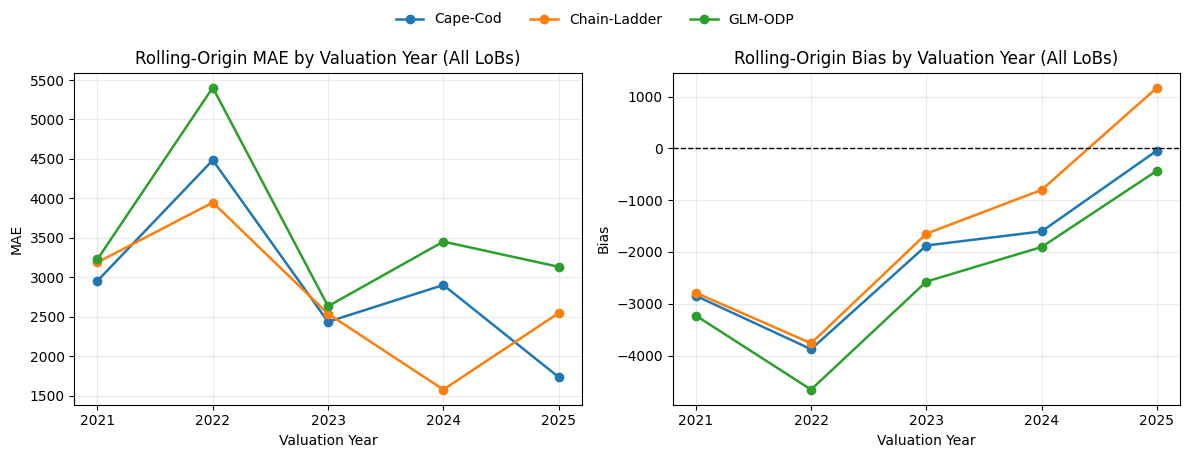

In [20]:
# Rolling-origin figure: MAE and RMSE by valuation year on portfolio-level target (lob == 'All').
if rolling_summary_tbl.empty:
    print('rolling_summary_tbl is empty; run rolling-origin cells first.')
else:
    source_tbl = rolling_summary_tbl.loc[rolling_summary_tbl['lob'] == 'All'].copy()
    if source_tbl.empty:
        print("No portfolio-level ('All') rows found in rolling_summary_tbl.")
    else:
        yearly_perf = (
            source_tbl
            .groupby(['valuation_pay_year', 'method'], as_index=False)
            .agg(
                mae=('mae', 'mean'),
                bias=('bias', 'mean'),
            )
        )

        years = sorted(yearly_perf['valuation_pay_year'].astype(int).unique())

        fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharex=True)
        for method, sub in yearly_perf.groupby('method'):
            sub = sub.sort_values('valuation_pay_year')
            axes[0].plot(sub['valuation_pay_year'], sub['mae'], marker='o', linewidth=1.8, label=method)
            axes[1].plot(sub['valuation_pay_year'], sub['bias'], marker='o', linewidth=1.8, label=method)

        axes[0].set_title('Rolling-Origin MAE by Valuation Year (All LoBs)')
        axes[0].set_xlabel('Valuation Year')
        axes[0].set_ylabel('MAE')
        axes[0].set_xticks(years)
        axes[0].grid(alpha=0.25)

        axes[1].set_title('Rolling-Origin Bias by Valuation Year (All LoBs)')
        axes[1].set_xlabel('Valuation Year')
        axes[1].set_ylabel('Bias')
        axes[1].set_xticks(years)
        axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
        axes[1].grid(alpha=0.25)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', ncol=max(1, len(labels)), frameon=False)
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.show()

Methodology note (rolling-origin backtesting):
- For each valuation year, only payments with calendar year <= valuation year are treated as observed.
- True ultimates remain fixed from the full synthetic history, so errors are genuinely out-of-sample at each origin.
- Cape-Cod exposure is recomputed at each origin through the package helper rather than reusing full-history claim counts.
- In the plots below, the LoB-average view should exclude the portfolio-level `All` row to avoid double-counting the same evaluation slice.

In [21]:
# Optional export of new static + rolling-origin benchmark tables
#label = 'all_types' if CLAIM_TYPE is None else f'type_{CLAIM_TYPE}'
#OUT_DIR = PROJECT_ROOT / 'Figures' / 'benchmark_tables' / 'synthetic' / label
#OUT_DIR.mkdir(parents=True, exist_ok=True)

#static_err_tbl.to_csv(OUT_DIR / 'static_error_by_lob.csv', index=False)
#static_method_rank.to_csv(OUT_DIR / 'static_method_rank.csv', index=False)

#if not rolling_compare_tbl.empty:
#    rolling_compare_tbl.to_csv(OUT_DIR / 'rolling_compare_long.csv', index=False)
#if not rolling_summary_tbl.empty:
#    rolling_summary_tbl.to_csv(OUT_DIR / 'rolling_summary_long.csv', index=False)
#    rolling_method_rank.to_csv(OUT_DIR / 'rolling_method_rank.csv', index=False)

# Save richer bootstrap diagnostics
#boot_total_tbl.to_csv(OUT_DIR / 'bootstrap_total.csv', index=False)
#boot_by_ay_tbl.to_csv(OUT_DIR / 'bootstrap_by_ay.csv', index=False)
#boot_diag_total_tbl.to_csv(OUT_DIR / 'bootstrap_diag_total.csv', index=False)
#if 'boot_by_ay_wide_tbl' in globals():
#    boot_by_ay_wide_tbl.to_csv(OUT_DIR / 'bootstrap_p90_width_by_ay.csv', index=False)

#OUT_DIR

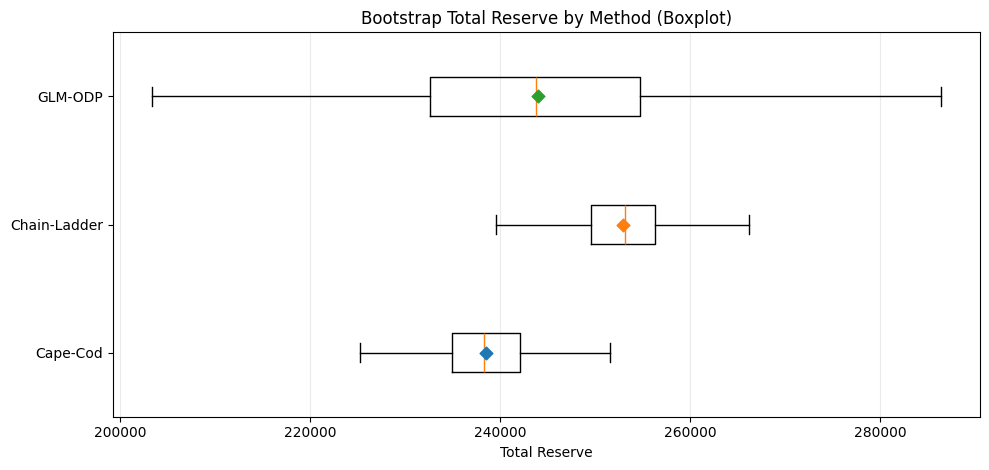

In [22]:
# Bootstrap figure 1: total reserve distributions by selected method
method_order = methods_selected
data = [boot[m].reserve_samples_total.values for m in method_order]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.boxplot(data, vert=False, tick_labels=method_order, showfliers=False)
for i, m in enumerate(method_order, start=1):
    mean_m = float(np.mean(data[i - 1]))
    ax.scatter(mean_m, i, marker='D', s=42, zorder=3)

ax.set_title('Bootstrap Total Reserve by Method (Boxplot)')
ax.set_xlabel('Total Reserve')
ax.grid(alpha=0.25, axis='x')
plt.tight_layout()
plt.show()

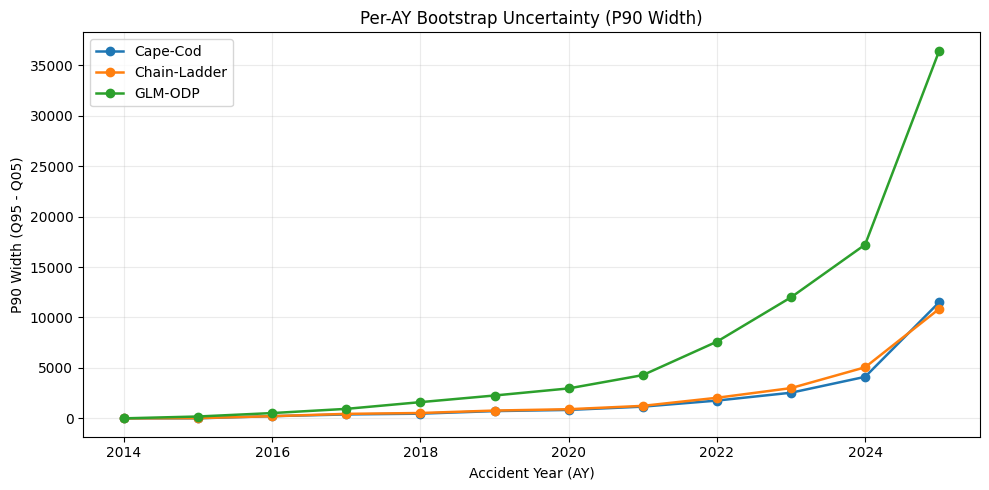

In [23]:
# Bootstrap figure 2: per-AY reserve uncertainty (P90 width)
boot_by_ay_wide = []
for method in method_order:
    b = boot[method]
    q05 = b.reserve_samples_by_ay.quantile(0.05)
    q95 = b.reserve_samples_by_ay.quantile(0.95)
    width = (q95 - q05).rename('p90_width').reset_index()
    width.columns = ['AY', 'p90_width']
    width['method'] = method
    boot_by_ay_wide.append(width)

boot_by_ay_wide_tbl = pd.concat(boot_by_ay_wide, ignore_index=True)
pivot_w = boot_by_ay_wide_tbl.pivot(index='AY', columns='method', values='p90_width')

fig, ax = plt.subplots(figsize=(10, 5))
for m in pivot_w.columns:
    ax.plot(pivot_w.index, pivot_w[m], marker='o', linewidth=1.8, label=m)

ax.set_title('Per-AY Bootstrap Uncertainty (P90 Width)')
ax.set_xlabel('Accident Year (AY)')
ax.set_ylabel('P90 Width (Q95 - Q05)')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 11. Benchmark Conclusion (Compact)
- The benchmark block is complete for classical methods in scope: Chain-Ladder and GLM-ODP, each with deterministic estimates and bootstrap uncertainty.
- On this synthetic setup, both methods are competitive on point error metrics; rolling-origin error trends improve as valuation maturity increases.
- After calibration fixes, Chain-Ladder bootstrap is now centered close to its deterministic reserve estimate and no longer shows artificial variance inflation.
- GLM-ODP remains a strong nonlinear baseline for the next stage, and both methods provide a stable reference for ML/DL comparison.

## 12. ML vs Classical (Same Rolling-Origin Target)

This block runs the claim-level ML hybrid pipeline (two-stage RBNS + calibrated IBNR addon) and compares it against classical methods on the same valuation years and target (total reserve / ultimate error).

Chronology note: Section 12.0 is used only for ML setup selection (tuning vs holdout). After that, Section 12.1 executes the final comparable leaderboard.

### 12.0 ML Selection Protocol (Tuning vs Holdout)

Before the final Section 12 benchmark run, we apply a model-selection protocol to reduce selection overfitting risk.

Protocol:
- Use earlier valuation years as a tuning window for feature and scenario selection.
- Keep the latest valuation years as an untouched holdout window for confirmation.
- Choose the ML setup by tuning-window performance only.
- Report holdout-window performance as the selection check.

This mirrors ML best practice while preserving a fair final comparison against classical methods in the benchmark block.

In [24]:
'''
# 12.0 model selection protocol: choose ML configuration on tuning years, then confirm once on holdout years.
import importlib
import time
import python_reserving.ml_pipeline as mlp

importlib.reload(mlp)

SCALE = float(globals().get("SCALE_DIVISOR", 1000.0))

if "valuation_years" not in globals() or valuation_years is None or len(valuation_years) == 0:
    raise RuntimeError("valuation_years is missing. Run Section 10 first.")

ml_eval_years = sorted({int(v) for v in valuation_years})
if len(ml_eval_years) < 5:
    raise RuntimeError("Need at least 5 evaluation years for tuning + holdout split.")

HOLDOUT_LAST_N = 2
ml_holdout_years = ml_eval_years[-HOLDOUT_LAST_N:]
ml_tune_years = ml_eval_years[:-HOLDOUT_LAST_N]

# Training-only snapshot years so every eval year (including the earliest) gets
# a full 4-snapshot training stack. Clipped to the AYs actually in the data.
min_available_ay = int(pd.to_numeric(output_df["AY"], errors="coerce").min())
ml_train_snapshot_years = [
    y for y in range(min(ml_eval_years) - 4, min(ml_eval_years)) if y >= min_available_ay
]

base_features = list(mlp.DEFAULT_FEATURE_COLUMNS)
open_report_flags = ["latest_open_ind", "has_reported_payment", "open_years_to_val", "ever_open_to_val"]
interactions = ["paid_to_val_x_open_years", "dev_x_rep_lag"]

feature_bank = {
    "locked_default20": list(base_features),
    "add_open_report_flags24": list(dict.fromkeys(base_features + open_report_flags)),
    "add_open_flags_and_interactions26": list(dict.fromkeys(base_features + open_report_flags + interactions)),
}

base_kwargs = {
    "lookback_valuations": 4,
    "max_train_rows": 250_000,
    "min_rows_type_model": 1_500,
    "eval_recent_ay_window": None,
}


def _eval_variant(variant_name: str, feature_cols: list[str], extra_kwargs: dict | None = None) -> dict:
    kwargs = dict(base_kwargs)
    if extra_kwargs:
        kwargs.update(extra_kwargs)

    t0 = time.time()
    _, _, _, hyb_sum = mlp.run_claim_level_rolling_origin_backtest(
        full_paid_df=full_paid,
        full_claims_df=full_claims,
        valuation_years=ml_eval_years,
        train_snapshot_years=ml_train_snapshot_years,
        scale_divisor=SCALE,
        feature_cols=feature_cols,
        raw_output_df=output_df,
        method_name_rbns=f"ML-RBNS-{variant_name}",
        method_name_hybrid=f"ML-HYB-{variant_name}",
        **kwargs,
    )

    hyb_all = hyb_sum.loc[
        (hyb_sum["lob"] == "All")
        & (hyb_sum["valuation_pay_year"].isin(ml_eval_years))
    ].copy() if not hyb_sum.empty else pd.DataFrame()

    tune = hyb_all.loc[hyb_all["valuation_pay_year"].isin(ml_tune_years)].copy()
    hold = hyb_all.loc[hyb_all["valuation_pay_year"].isin(ml_holdout_years)].copy()

    return {
        "variant": variant_name,
        "n_features": int(len(feature_cols)),
        "lookback_valuations": int(kwargs["lookback_valuations"]),
        "max_train_rows": int(kwargs["max_train_rows"]),
        "tune_mae": float(tune["mae"].mean()) if not tune.empty else np.nan,
        "holdout_mae": float(hold["mae"].mean()) if not hold.empty else np.nan,
        "tune_rmse": float(tune["rmse"].mean()) if not tune.empty else np.nan,
        "holdout_rmse": float(hold["rmse"].mean()) if not hold.empty else np.nan,
        "runtime_sec": round(float(time.time() - t0), 1),
        "feature_cols": feature_cols,
    }


print("Section 12.0 evaluation years:", ml_eval_years)
print("Tuning years:", ml_tune_years)
print("Holdout years:", ml_holdout_years)

# Step A: feature selection on tuning window only.
variant_rows = []
for name, cols in feature_bank.items():
    row = _eval_variant(name, cols)
    variant_rows.append(row)
    print(f"Finished variant {name} in {row['runtime_sec']}s")

variant_tbl = pd.DataFrame(variant_rows).sort_values("tune_mae").reset_index(drop=True)
best_variant_name = str(variant_tbl.iloc[0]["variant"])
ml_selected_feature_cols = list(next(r["feature_cols"] for r in variant_rows if r["variant"] == best_variant_name))

print("\nFeature-selection table (choose by tuning MAE, inspect holdout MAE):")
display(variant_tbl[["variant", "n_features", "tune_mae", "holdout_mae", "tune_rmse", "holdout_rmse", "runtime_sec"]])
print("Selected variant from tuning window:", best_variant_name)

# Step B: compact stability scenarios for selected feature set.
stability_bank = {
    "selected_baseline": {},
    "selected_lookback6": {"lookback_valuations": 6},
    "selected_train120k": {"max_train_rows": 120_000},
}

stability_rows = []
for scenario_name, extra_kwargs in stability_bank.items():
    row = _eval_variant(scenario_name, ml_selected_feature_cols, extra_kwargs=extra_kwargs)
    stability_rows.append(row)
    print(f"Finished scenario {scenario_name} in {row['runtime_sec']}s")

stability_tbl = pd.DataFrame(stability_rows).sort_values("tune_mae").reset_index(drop=True)
print("\nStability table for selected feature set:")
display(stability_tbl[["variant", "lookback_valuations", "max_train_rows", "tune_mae", "holdout_mae", "tune_rmse", "holdout_rmse", "runtime_sec"]])

# Freeze the setup summary for reporting; Cells 39-41 stay unchanged and run afterwards.
selection_protocol_summary = {
    "eval_years": ml_eval_years,
    "tune_years": ml_tune_years,
    "holdout_years": ml_holdout_years,
    "selected_feature_variant": best_variant_name,
    "selected_n_features": int(len(ml_selected_feature_cols)),
}
print("\nSelection protocol summary:")
print(selection_protocol_summary)
'''

'\n# 12.0 model selection protocol: choose ML configuration on tuning years, then confirm once on holdout years.\nimport importlib\nimport time\nimport python_reserving.ml_pipeline as mlp\n\nimportlib.reload(mlp)\n\nSCALE = float(globals().get("SCALE_DIVISOR", 1000.0))\n\nif "valuation_years" not in globals() or valuation_years is None or len(valuation_years) == 0:\n    raise RuntimeError("valuation_years is missing. Run Section 10 first.")\n\nml_eval_years = sorted({int(v) for v in valuation_years})\nif len(ml_eval_years) < 5:\n    raise RuntimeError("Need at least 5 evaluation years for tuning + holdout split.")\n\nHOLDOUT_LAST_N = 2\nml_holdout_years = ml_eval_years[-HOLDOUT_LAST_N:]\nml_tune_years = ml_eval_years[:-HOLDOUT_LAST_N]\n\n# Training-only snapshot years so every eval year (including the earliest) gets\n# a full 4-snapshot training stack. Clipped to the AYs actually in the data.\nmin_available_ay = int(pd.to_numeric(output_df["AY"], errors="coerce").min())\nml_train_snaps

### 12.1 ML Benchmark
Using the Section 12.0 tuning/holdout protocol (tuning years 2020-2023, holdout years 2024-2025), we obtained:

Feature-selection results:
- `locked_default20` (20 features): tuning MAE 3374.06, holdout MAE 3644.06.
- `add_open_report_flags24` (24 features): tuning MAE 5535.95, holdout MAE 2502.59.
- `add_open_flags_and_interactions26` (26 features): tuning MAE 5667.21, holdout MAE 2553.77.

Interpretation of tune vs holdout differences:
- The lower holdout MAE for 24/26-feature variants, despite much worse tuning MAE, indicates time-regime sensitivity rather than a stable global winner.
- Therefore, choosing the best holdout variant after seeing holdout outcomes would violate the protocol and reintroduce selection bias.
- By design, holdout is used as a confirmation check, not as a second tuning stage.

Final setup used for the benchmark block:
- Keep the selected default 20-feature set.
- Keep baseline scenario (`lookback_valuations=4`, `max_train_rows=250000`).

In [25]:
# Run upgraded ML hybrid with one warm-up valuation year and compare to classical rolling results.
import importlib
import python_reserving.ml_pipeline as mlp
importlib.reload(mlp)

SCALE = float(globals().get('SCALE_DIVISOR', 1000.0))
ML_TRAIN_CUTOFF_LAG = 4  # v-3 default; v-4 performs better

if "rolling_summary_tbl" not in globals() or rolling_summary_tbl is None or rolling_summary_tbl.empty:
    raise RuntimeError("rolling_summary_tbl is empty. Run the rolling-origin classical section first.")

ml_eval_years = sorted({int(v) for v in valuation_years})
# Training-only snapshot years so every eval year (including the earliest) gets
# a full 4-snapshot training stack. Clipped to the AYs actually in the data.
min_available_ay = int(pd.to_numeric(output_df["AY"], errors="coerce").min())
ml_train_snapshot_years = [
    y for y in range(min(ml_eval_years) - 5, min(ml_eval_years)) if y >= min_available_ay
]

# Final production feature set is now locked in ml_pipeline.DEFAULT_FEATURE_COLUMNS.
ml_feature_cols = list(mlp.DEFAULT_FEATURE_COLUMNS)

print("ML evaluation years:", ml_eval_years)
print("ML training-only snapshot years:", ml_train_snapshot_years)
print("ML feature count:", len(ml_feature_cols))
print("ML train cutoff lag:", int(ML_TRAIN_CUTOFF_LAG), "(train cutoff = v - lag)")
'''
rbns_compare_ml, rbns_summary_ml, hybrid_compare_ml, hybrid_summary_ml = mlp.run_claim_level_rolling_origin_backtest(
    full_paid_df=full_paid,
    full_claims_df=full_claims,
    valuation_years=ml_eval_years,
    train_snapshot_years=ml_train_snapshot_years,
    scale_divisor=SCALE,
    feature_cols=ml_feature_cols,
    raw_output_df=output_df,
    lookback_valuations=5,
    max_train_rows=250_000,
    min_rows_type_model=1_500,
    train_cutoff_lag=int(ML_TRAIN_CUTOFF_LAG),
    eval_recent_ay_window=None,
    method_name_rbns="ML-Claim-2Stage-RBNS-Cal",
    method_name_hybrid="ML-Claim-2Stage+IBNR-Cal",
)
'''
ml_summary_all = hybrid_summary_ml.copy()
if not ml_summary_all.empty:
    ml_summary_all = ml_summary_all.loc[
        (ml_summary_all["lob"] == "All")
        & (ml_summary_all["valuation_pay_year"].isin(ml_eval_years))
    ].copy()

classical_summary_all = rolling_summary_tbl.copy()
if not classical_summary_all.empty:
    classical_summary_all = classical_summary_all.loc[
        (classical_summary_all["lob"] == "All")
        & (classical_summary_all["valuation_pay_year"].isin(ml_eval_years))
    ].copy()

combined_yearly = pd.concat([classical_summary_all, ml_summary_all], ignore_index=True, sort=False)
combined_yearly = combined_yearly.sort_values(["valuation_pay_year", "method"]).reset_index(drop=True)

combined_rank = (
    combined_yearly
    .groupby("method", as_index=False)
    .agg(
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        bias_abs=("bias", lambda s: float(np.mean(np.abs(s)))),
        mape=("mape", "mean"),
        n_eval=("valuation_pay_year", "count"),
    )
    .sort_values(["mae", "rmse"]) 
    .reset_index(drop=True)
)

print("Combined rolling-origin yearly metrics (All LoBs):")
display(combined_yearly)
print("\nCombined method ranking (All LoBs):")
display(combined_rank)

ML evaluation years: [2021, 2022, 2023, 2024, 2025]
ML training-only snapshot years: [2016, 2017, 2018, 2019, 2020]
ML feature count: 20
ML train cutoff lag: 4 (train cutoff = v - lag)
Combined rolling-origin yearly metrics (All LoBs):


,method,mae,rmse,bias,mape,valuation_pay_year,lob
0,Cape-Cod,2954.511937,3598.281220,-2846.609624,3.589655,2021,All
1,Chain-Ladder,3188.863018,3748.494451,-2788.348266,3.818585,2021,All
2,GLM-ODP,3228.453665,3754.656503,-3228.453665,3.945749,2021,All
3,ML-Claim-2Stage+IBNR-Cal,1844.192552,2743.768162,-892.522129,2.148236,2021,All
4,Cape-Cod,4483.323788,7814.608381,-3878.669870,3.994579,2022,All
5,Chain-Ladder,3946.846083,6892.425692,-3764.082360,3.558402,2022,All
6,GLM-ODP,5402.754374,8985.414034,-4658.367633,4.898169,2022,All
7,ML-Claim-2Stage+IBNR-Cal,4565.323041,8496.045630,-1086.641985,3.943243,2022,All
8,Cape-Cod,2435.134105,3966.512948,-1876.353844,2.237572,2023,All
9,Chain-Ladder,2536.770221,3989.739357,-1647.995593,2.245052,2023,All



Combined method ranking (All LoBs):


,method,mae,rmse,bias_abs,mape,n_eval
0,Chain-Ladder,2758.833438,4576.379740,2034.804793,2.478752,5
1,ML-Claim-2Stage+IBNR-Cal,2830.877524,4371.201639,847.902838,2.625693,5
2,Cape-Cod,2901.813002,4498.078393,2049.844263,2.645507,5
3,GLM-ODP,3569.572658,4940.379476,2559.370174,3.350699,5


In [26]:
'''
# Optional sensitivity run: compare ML train cutoff lag v-2, v-3, v-4 on the same rolling-origin setup.
import importlib
import python_reserving.ml_pipeline as mlp
importlib.reload(mlp)

if "valuation_years" not in globals() or valuation_years is None or len(valuation_years) == 0:
    raise RuntimeError("valuation_years is missing. Run Section 10 first.")
if "full_paid" not in globals() or "full_claims" not in globals() or "output_df" not in globals():
    raise RuntimeError("Missing full_paid/full_claims/output_df. Run Sections 1 and 10 first.")

SCALE = float(globals().get("SCALE_DIVISOR", 1000.0))
ml_eval_years = sorted({int(v) for v in valuation_years})
# Training-only snapshot years so every eval year (including the earliest) gets
# a full 4-snapshot training stack. Clipped to the AYs actually in the data.
min_available_ay = int(pd.to_numeric(output_df["AY"], errors="coerce").min())
ml_train_snapshot_years = [
    y for y in range(min(ml_eval_years) - 4, min(ml_eval_years)) if y >= min_available_ay
]

lag_grid = [2, 3, 4]
lag_rows = []
lag_yearly_parts = []

for lag in lag_grid:
    _, _, _, hyb_sum_lag = mlp.run_claim_level_rolling_origin_backtest(
        full_paid_df=full_paid,
        full_claims_df=full_claims,
        valuation_years=ml_eval_years,
        train_snapshot_years=ml_train_snapshot_years,
        scale_divisor=SCALE,
        feature_cols=list(mlp.DEFAULT_FEATURE_COLUMNS),
        raw_output_df=output_df,
        lookback_valuations=4,
        max_train_rows=250_000,
        min_rows_type_model=1_500,
        train_cutoff_lag=int(lag),
        eval_recent_ay_window=None,
        method_name_rbns=f"ML-Claim-2Stage-RBNS-Cal-v-{int(lag)}",
        method_name_hybrid=f"ML-Claim-2Stage+IBNR-Cal-v-{int(lag)}",
    )

    hyb_all = hyb_sum_lag.loc[
        (hyb_sum_lag["lob"] == "All")
        & (hyb_sum_lag["valuation_pay_year"].isin(ml_eval_years))
    ].copy() if hyb_sum_lag is not None and not hyb_sum_lag.empty else pd.DataFrame()

    if hyb_all.empty:
        continue

    hyb_all["train_cutoff_lag"] = int(lag)
    lag_yearly_parts.append(hyb_all)
    lag_rows.append({
        "train_cutoff_lag": int(lag),
        "mae": float(hyb_all["mae"].mean()),
        "rmse": float(hyb_all["rmse"].mean()),
        "bias_abs": float(np.mean(np.abs(hyb_all["bias"]))),
        "mape": float(hyb_all["mape"].mean()),
        "n_eval": int(hyb_all["valuation_pay_year"].count()),
    })

if not lag_rows:
    print("No lag-sweep rows produced. Check data availability and minimum training rows.")
else:
    ml_cutoff_lag_rank = pd.DataFrame(lag_rows).sort_values(["mae", "rmse"]).reset_index(drop=True)
    ml_cutoff_lag_yearly = pd.concat(lag_yearly_parts, ignore_index=True, sort=False)
    ml_cutoff_lag_yearly = ml_cutoff_lag_yearly.sort_values(["train_cutoff_lag", "valuation_pay_year"]).reset_index(drop=True)
    print("ML lag sensitivity yearly metrics (All LoBs):")
    display(ml_cutoff_lag_yearly[["train_cutoff_lag", "valuation_pay_year", "method", "mae", "rmse", "bias", "mape"]])
    print("ML lag sensitivity ranking (lower is better):")
    display(ml_cutoff_lag_rank)
'''

'\n# Optional sensitivity run: compare ML train cutoff lag v-2, v-3, v-4 on the same rolling-origin setup.\nimport importlib\nimport python_reserving.ml_pipeline as mlp\nimportlib.reload(mlp)\n\nif "valuation_years" not in globals() or valuation_years is None or len(valuation_years) == 0:\n    raise RuntimeError("valuation_years is missing. Run Section 10 first.")\nif "full_paid" not in globals() or "full_claims" not in globals() or "output_df" not in globals():\n    raise RuntimeError("Missing full_paid/full_claims/output_df. Run Sections 1 and 10 first.")\n\nSCALE = float(globals().get("SCALE_DIVISOR", 1000.0))\nml_eval_years = sorted({int(v) for v in valuation_years})\n# Training-only snapshot years so every eval year (including the earliest) gets\n# a full 4-snapshot training stack. Clipped to the AYs actually in the data.\nmin_available_ay = int(pd.to_numeric(output_df["AY"], errors="coerce").min())\nml_train_snapshot_years = [\n    y for y in range(min(ml_eval_years) - 4, min(ml_

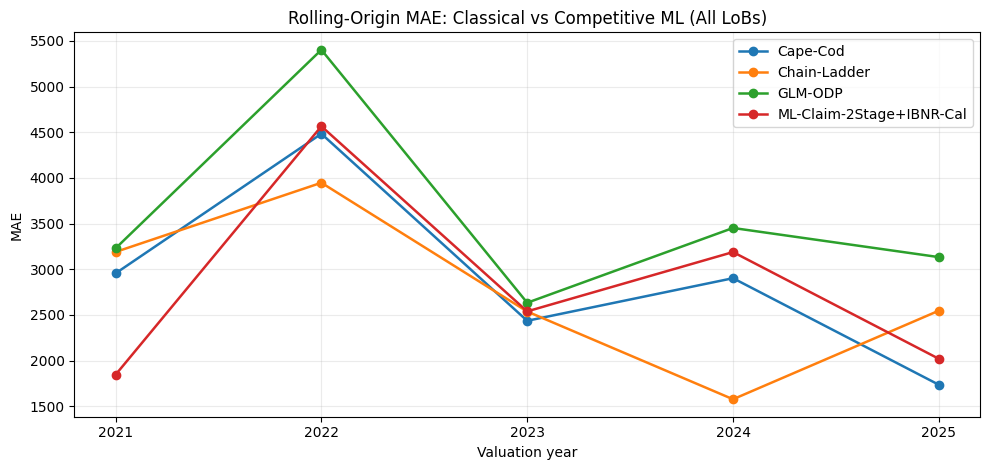

In [27]:
# Plot yearly MAE for classical methods plus the upgraded hybrid ML model.
if "combined_yearly" in globals() and not combined_yearly.empty:
    plot_tbl = combined_yearly.loc[combined_yearly["lob"] == "All"].copy()
    fig, ax = plt.subplots(figsize=(10, 4.8))
    for method, sub in plot_tbl.groupby("method"):
        ax.plot(sub["valuation_pay_year"], sub["mae"], marker="o", linewidth=1.8, label=method)

    ax.set_title("Rolling-Origin MAE: Classical vs Competitive ML (All LoBs)")
    ax.set_xlabel("Valuation year")
    ax.set_ylabel("MAE")
    ax.set_xticks(sorted(plot_tbl["valuation_pay_year"].astype(int).unique()))
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

## 13. ML Anchor Blends (ML + Chain-Ladder)

This section applies the same rolling, leakage-safe blend idea used for DL:
- Blend ML reserve with an actuarial anchor reserve.
- Estimate blend weight from past valuation years only.
- Clip the learned weight to [0, 1].

Implemented blends:
- ML + Chain-Ladder

In [28]:
import importlib
import python_reserving.ml_pipeline as mlp
importlib.reload(mlp)

required_globals = ["rolling_compare_tbl", "hybrid_compare_ml", "ml_eval_years"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}. Run Sections 10 and 12 first.")

if rolling_compare_tbl is None or rolling_compare_tbl.empty:
    raise RuntimeError("rolling_compare_tbl is empty. Run Section 10 first.")
if hybrid_compare_ml is None or hybrid_compare_ml.empty:
    raise RuntimeError("hybrid_compare_ml is empty. Run Section 12 first.")

ml_key = hybrid_compare_ml.loc[
    hybrid_compare_ml["lob"] != "All",
    ["valuation_pay_year", "AY", "lob", "Type", "latest_observed", "pred_reserve", "true_total_reserve", "true_ultimate"],
].copy()
ml_key = ml_key.rename(columns={"pred_reserve": "pred_reserve_ml"})

for c in ["latest_observed", "pred_reserve_ml", "true_total_reserve", "true_ultimate"]:
    ml_key[c] = pd.to_numeric(ml_key[c], errors="coerce").fillna(0.0)

def _build_anchor_key(method_name: str, out_col: str) -> pd.DataFrame:
    anchor = rolling_compare_tbl.loc[
        (rolling_compare_tbl["method"] == method_name) & (rolling_compare_tbl["lob"] != "All"),
        ["valuation_pay_year", "AY", "lob", "latest_observed", "ultimate"],
    ].copy()
    if anchor.empty:
        raise RuntimeError(f"No rows found in rolling_compare_tbl for method='{method_name}'.")
    anchor[out_col] = pd.to_numeric(anchor["ultimate"], errors="coerce").fillna(0.0) - pd.to_numeric(anchor["latest_observed"], errors="coerce").fillna(0.0)
    return anchor[["valuation_pay_year", "AY", "lob", out_col]]

odp_key = _build_anchor_key("GLM-ODP", "pred_reserve_odp")
cl_key = _build_anchor_key("Chain-Ladder", "pred_reserve_cl")

blend_base = (
    ml_key
    .merge(odp_key, on=["valuation_pay_year", "AY", "lob"], how="inner")
    .merge(cl_key, on=["valuation_pay_year", "AY", "lob"], how="inner")
)

if blend_base.empty:
    raise RuntimeError("No overlapping ML/ODP/CL rows after merge.")

def _rolling_blend_one_weight(
    df: pd.DataFrame,
    pred_col: str,
    anchor_col: str,
    method_name: str,
    init_weight: float = 0.20,
    min_hist_rows: int = 6,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    vals = sorted(df["valuation_pay_year"].dropna().astype(int).unique().tolist())
    prev_w = float(np.clip(init_weight, 0.0, 1.0))

    blend_rows = []
    weight_rows = []

    for v in vals:
        prev = df.loc[df["valuation_pay_year"] < int(v)].copy()
        if len(prev) >= int(min_hist_rows):
            y = pd.to_numeric(prev["true_total_reserve"], errors="coerce").to_numpy(dtype=float)
            p = pd.to_numeric(prev[pred_col], errors="coerce").to_numpy(dtype=float)
            a = pd.to_numeric(prev[anchor_col], errors="coerce").to_numpy(dtype=float)
            mask = np.isfinite(y) & np.isfinite(p) & np.isfinite(a)
            if np.any(mask):
                y = y[mask]
                p = p[mask]
                a = a[mask]
                denom = float(np.sum((p - a) ** 2))
                if denom > 1e-12:
                    w = float(np.sum((y - a) * (p - a)) / denom)
                    if np.isfinite(w):
                        prev_w = float(np.clip(w, 0.0, 1.0))

        weight_rows.append({"valuation_pay_year": int(v), "w_ml": float(prev_w)})

        cur = df.loc[df["valuation_pay_year"] == int(v)].copy()
        if cur.empty:
            continue

        cur["pred_reserve_blend"] = (
            prev_w * pd.to_numeric(cur[pred_col], errors="coerce").fillna(0.0)
            + (1.0 - prev_w) * pd.to_numeric(cur[anchor_col], errors="coerce").fillna(0.0)
        )
        cur["ultimate"] = pd.to_numeric(cur["latest_observed"], errors="coerce").fillna(0.0) + cur["pred_reserve_blend"]
        cur["error"] = cur["ultimate"] - pd.to_numeric(cur["true_ultimate"], errors="coerce").fillna(0.0)
        cur["abs_error"] = cur["error"].abs()
        cur["pct_error"] = np.where(
            pd.to_numeric(cur["true_ultimate"], errors="coerce").abs() > 1e-9,
            100.0 * cur["error"] / pd.to_numeric(cur["true_ultimate"], errors="coerce"),
            np.nan,
        )
        cur["method"] = method_name
        blend_rows.append(cur)

    if not blend_rows:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(weight_rows)

    cmp = pd.concat(blend_rows, ignore_index=True)
    cmp = mlp._append_all_row(cmp, value_col="pred_reserve_blend", true_col="true_total_reserve")
    smry = mlp.summarize_ml_compare(cmp)
    return cmp, smry, pd.DataFrame(weight_rows)

ml_cl_compare, ml_cl_summary, ml_cl_weights = _rolling_blend_one_weight(
    blend_base,
    pred_col="pred_reserve_ml",
    anchor_col="pred_reserve_cl",
    method_name="ML+Chain-Ladder-Blend",
    init_weight=0.50,
    min_hist_rows=6,
)

blend_all_summaries = []
for s in [ml_cl_summary]:
    if s is not None and not s.empty:
        blend_all_summaries.append(
            s.loc[(s["lob"] == "All") & (s["valuation_pay_year"].isin(ml_eval_years))].copy()
        )

base_yearly_ml = combined_yearly.copy() if "combined_yearly" in globals() else pd.DataFrame()
extra_yearly = pd.concat(blend_all_summaries, ignore_index=True, sort=False) if blend_all_summaries else pd.DataFrame()
combined_yearly_ml_blend = pd.concat([base_yearly_ml, extra_yearly], ignore_index=True, sort=False) if not base_yearly_ml.empty else extra_yearly.copy()

if combined_yearly_ml_blend.empty:
    print("No blend leaderboard rows were produced.")
else:
    combined_yearly_ml_blend = combined_yearly_ml_blend.sort_values(["valuation_pay_year", "method"]).reset_index(drop=True)
    combined_rank_ml_blend = (
        combined_yearly_ml_blend
        .groupby("method", as_index=False)
        .agg(
            mae=("mae", "mean"),
            rmse=("rmse", "mean"),
            bias_abs=("bias", lambda s: float(np.mean(np.abs(s)))),
            mape=("mape", "mean"),
            n_eval=("valuation_pay_year", "count"),
        )
        .sort_values(["mae", "rmse"])
        .reset_index(drop=True)
    )

    print("ML-anchor blend weights by valuation year (Chain-Ladder anchor):")
    display(ml_cl_weights)
    print("Leaderboard with ML anchor blends added:")
    display(combined_rank_ml_blend)


ML-anchor blend weights by valuation year (Chain-Ladder anchor):


,valuation_pay_year,w_ml
0,2021,0.500000
1,2022,0.821638
2,2023,0.481656
3,2024,0.525763
4,2025,0.452377


Leaderboard with ML anchor blends added:


,method,mae,rmse,bias_abs,mape,n_eval
0,ML+Chain-Ladder-Blend,2288.122739,3964.765264,1255.427370,1.934396,5
1,Chain-Ladder,2758.833438,4576.379740,2034.804793,2.478752,5
2,ML-Claim-2Stage+IBNR-Cal,2830.877524,4371.201639,847.902838,2.625693,5
3,Cape-Cod,2901.813002,4498.078393,2049.844263,2.645507,5
4,GLM-ODP,3569.572658,4940.379476,2559.370174,3.350699,5


Section 13 Rolling-Origin MAE by valuation year (All LoBs):


method,Cape-Cod,Chain-Ladder,GLM-ODP,ML+Chain-Ladder-Blend,ML-Claim-2Stage+IBNR-Cal
valuation_pay_year,,,,,
2021,2954.51,3188.86,3228.45,1961.81,1844.19
2022,4483.32,3946.85,5402.75,4095.30,4565.32
2023,2435.13,2536.77,2632.69,1464.23,2538.27
2024,2901.49,1575.86,3451.54,2119.02,3187.69
2025,1734.61,2545.82,3132.43,1800.25,2018.92


Section 13 Rolling-Origin Bias by valuation year (All LoBs):


method,Cape-Cod,Chain-Ladder,GLM-ODP,ML+Chain-Ladder-Blend,ML-Claim-2Stage+IBNR-Cal
valuation_pay_year,,,,,
2021,-2846.61,-2788.35,-3228.45,-1960.58,-892.52
2022,-3878.67,-3764.08,-4658.37,-1592.65,-1086.64
2023,-1876.35,-1648.00,-2572.95,-959.05,-173.83
2024,-1603.85,-802.35,-1905.16,-404.57,-111.62
2025,-43.74,1171.25,-431.92,1360.28,1974.90


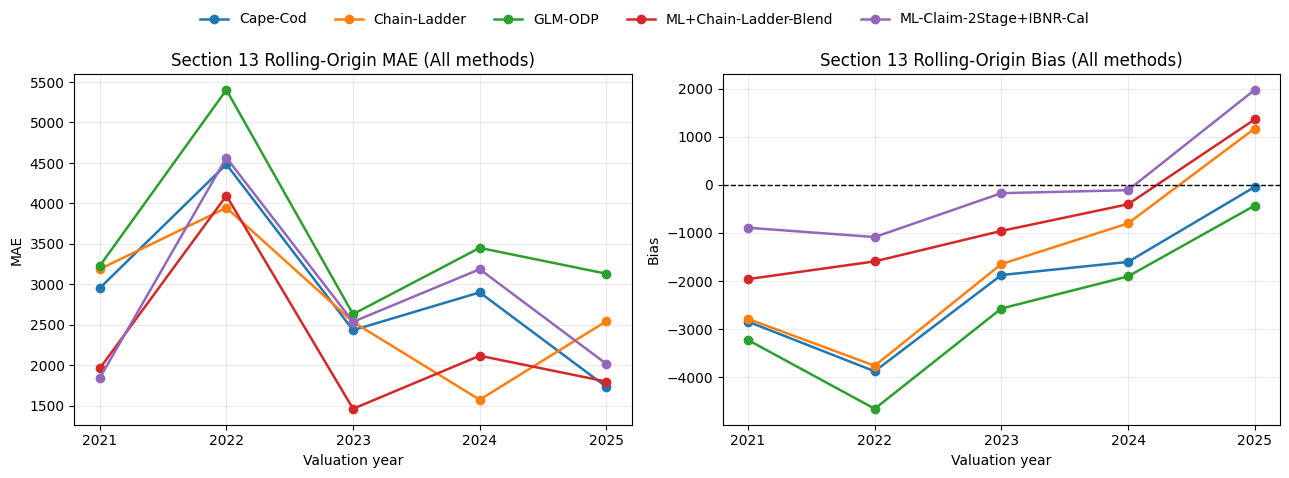

In [29]:
# Section 13 visualization: print blend weights and compare rolling-origin performance across all methods.
plot_tbl = combined_yearly_ml_blend.loc[combined_yearly_ml_blend["lob"] == "All"].copy()
if plot_tbl.empty:
    print("No portfolio-level rows available for plotting.")
else:
    yearly = (
        plot_tbl.groupby(["valuation_pay_year", "method"], as_index=False)
        .agg(mae=("mae", "mean"), bias=("bias", "mean"))
        .sort_values(["valuation_pay_year", "method"])
)

    mae_by_year = (
        yearly.pivot(index="valuation_pay_year", columns="method", values="mae")
        .sort_index()
    )
    bias_by_year = (
        yearly.pivot(index="valuation_pay_year", columns="method", values="bias")
        .sort_index()
    )
    print("Section 13 Rolling-Origin MAE by valuation year (All LoBs):")
    display(mae_by_year.round(2))
    print("Section 13 Rolling-Origin Bias by valuation year (All LoBs):")
    display(bias_by_year.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    for method, sub in yearly.groupby("method"):
        sub = sub.sort_values("valuation_pay_year")
        axes[0].plot(sub["valuation_pay_year"], sub["mae"], marker="o", linewidth=1.8, label=method)
        axes[1].plot(sub["valuation_pay_year"], sub["bias"], marker="o", linewidth=1.8, label=method)

    axes[0].set_title("Section 13 Rolling-Origin MAE (All methods)")
    axes[0].set_xlabel("Valuation year")
    axes[0].set_ylabel("MAE")
    axes[0].set_xticks(sorted(yearly["valuation_pay_year"].astype(int).unique()))
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Section 13 Rolling-Origin Bias (All methods)")
    axes[1].set_xlabel("Valuation year")
    axes[1].set_ylabel("Bias")
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xticks(sorted(yearly["valuation_pay_year"].astype(int).unique()))
    axes[1].grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

## 14. Diagnostics: Error Dynamics and Cohort Effects

This section provides compact diagnostics to interpret how error metrics evolve over valuation years. We separate moving-portfolio effects from fixed-cohort behavior and compare absolute vs reserve-weighted error measures to avoid misleading conclusions from shrinking denominators.

MAE vs remaining true reserve diagnostics (by method):


,method,corr_mae_vs_true_reserve,mae_per_unit_true_reserve_slope
0,Cape-Cod,-0.560625,-0.013519
1,Chain-Ladder,-0.473667,-0.009936
2,GLM-ODP,-0.192430,-0.004903
3,ML-Claim-2Stage+IBNR-Cal,-0.073759,-0.001939


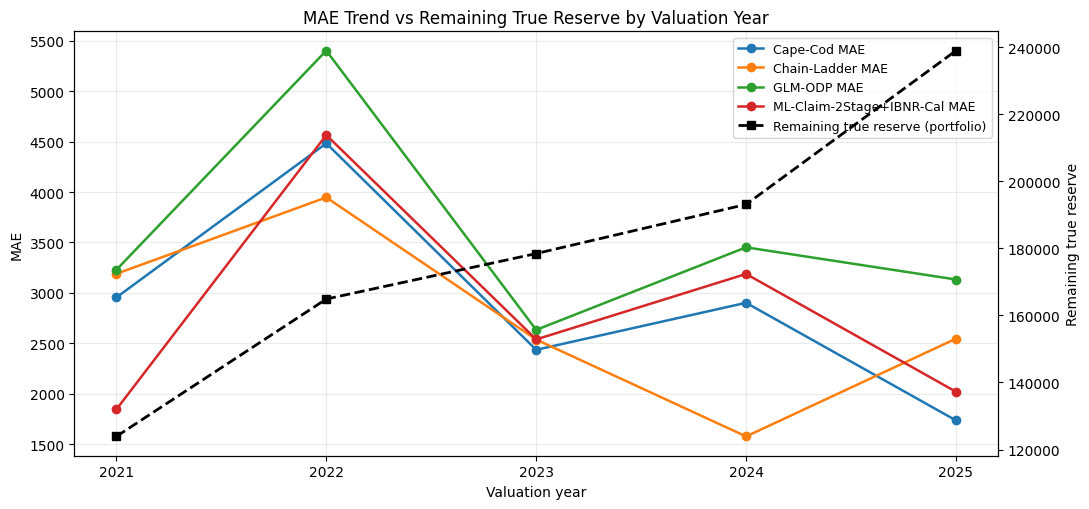

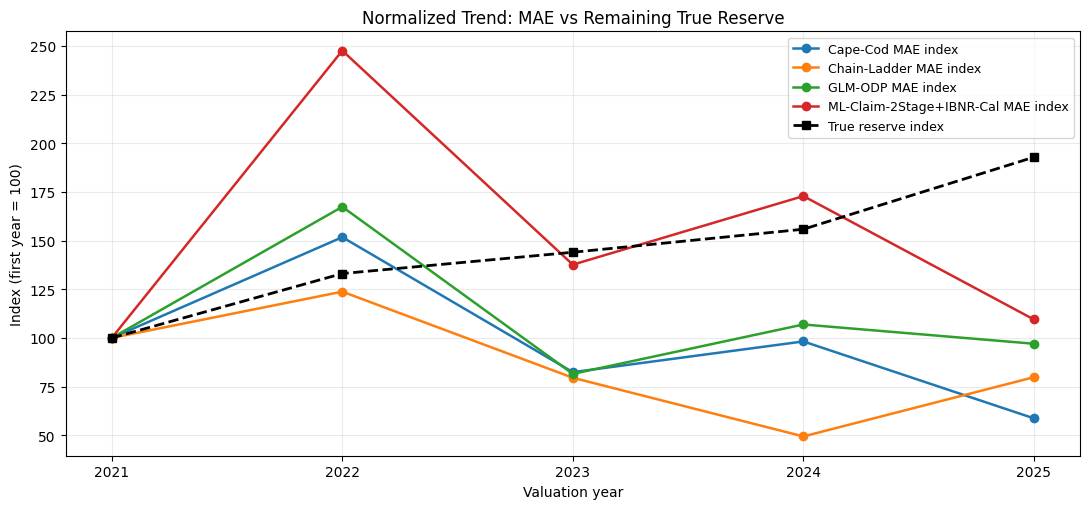

In [30]:
# Diagnostic: does MAE decline with declining remaining true reserve?
if "combined_yearly" not in globals() or combined_yearly.empty:
    raise RuntimeError("combined_yearly is empty. Run Section 12 cells first.")
if "rolling_compare_tbl" not in globals() or rolling_compare_tbl.empty:
    raise RuntimeError("rolling_compare_tbl is empty. Run Section 10 rolling-origin cells first.")

# Build portfolio-level true reserve by valuation year from classical rolling compare table.
truth_ref = rolling_compare_tbl.loc[rolling_compare_tbl["lob"] == "All"].copy()
if truth_ref.empty:
    raise RuntimeError("No portfolio-level ('All') rows found in rolling_compare_tbl.")

# Avoid duplicating truth across methods by taking one reference method.
ref_method = "Chain-Ladder" if "Chain-Ladder" in truth_ref["method"].unique() else truth_ref["method"].iloc[0]
truth_ref = truth_ref.loc[truth_ref["method"] == ref_method].copy()
truth_ref["true_reserve"] = pd.to_numeric(truth_ref["true_ultimate"], errors="coerce") - pd.to_numeric(truth_ref["latest_observed"], errors="coerce")
truth_by_year = (
    truth_ref.groupby("valuation_pay_year", as_index=False)
    .agg(true_reserve_total=("true_reserve", "sum"))
    .sort_values("valuation_pay_year")
    .reset_index(drop=True)
)

# Join with method-wise MAE and compute within-method MAE-vs-reserve correlation across years.
diag = combined_yearly.loc[combined_yearly["lob"] == "All", ["valuation_pay_year", "method", "mae", "rmse"]].copy()
diag = diag.merge(truth_by_year, on="valuation_pay_year", how="left")

corr_rows = []
for method, sub in diag.groupby("method"):
    s = sub.dropna(subset=["mae", "true_reserve_total"]).copy()
    corr = float(s["mae"].corr(s["true_reserve_total"])) if len(s) >= 2 else np.nan
    slope = np.polyfit(s["true_reserve_total"], s["mae"], 1)[0] if len(s) >= 2 else np.nan
    corr_rows.append({"method": method, "corr_mae_vs_true_reserve": corr, "mae_per_unit_true_reserve_slope": slope})

corr_tbl = pd.DataFrame(corr_rows).sort_values("method").reset_index(drop=True)
print("MAE vs remaining true reserve diagnostics (by method):")
display(corr_tbl)

# Plot MAE by method with remaining true reserve overlay.
fig, ax1 = plt.subplots(figsize=(11, 5.2))
for method, sub in diag.groupby("method"):
    sub = sub.sort_values("valuation_pay_year")
    ax1.plot(sub["valuation_pay_year"], sub["mae"], marker="o", linewidth=1.8, label=f"{method} MAE")

ax1.set_xlabel("Valuation year")
ax1.set_ylabel("MAE")
ax1.set_xticks(sorted(diag["valuation_pay_year"].astype(int).unique()))
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(truth_by_year["valuation_pay_year"], truth_by_year["true_reserve_total"], linestyle="--", marker="s", linewidth=2.0, color="black", label="Remaining true reserve (portfolio)")
ax2.set_ylabel("Remaining true reserve")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", fontsize=9)
ax1.set_title("MAE Trend vs Remaining True Reserve by Valuation Year")
plt.tight_layout()
plt.show()

# Optional normalized view (index=100 at first available year) for shape comparison.
norm = diag.copy()
base_mae = norm.groupby("method", as_index=False).agg(base_mae=("mae", "first"))
norm = norm.merge(base_mae, on="method", how="left")
norm["mae_index"] = 100.0 * norm["mae"] / norm["base_mae"].replace(0.0, np.nan)
base_reserve = float(truth_by_year["true_reserve_total"].iloc[0]) if len(truth_by_year) > 0 else np.nan
truth_by_year["reserve_index"] = 100.0 * truth_by_year["true_reserve_total"] / base_reserve if pd.notna(base_reserve) and base_reserve != 0 else np.nan

fig, ax = plt.subplots(figsize=(11, 5.2))
for method, sub in norm.groupby("method"):
    sub = sub.sort_values("valuation_pay_year")
    ax.plot(sub["valuation_pay_year"], sub["mae_index"], marker="o", linewidth=1.8, label=f"{method} MAE index")
ax.plot(truth_by_year["valuation_pay_year"], truth_by_year["reserve_index"], linestyle="--", marker="s", linewidth=2.0, color="black", label="True reserve index")
ax.set_xlabel("Valuation year")
ax.set_ylabel("Index (first year = 100)")
ax.set_title("Normalized Trend: MAE vs Remaining True Reserve")
ax.set_xticks(sorted(norm["valuation_pay_year"].astype(int).unique()))
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

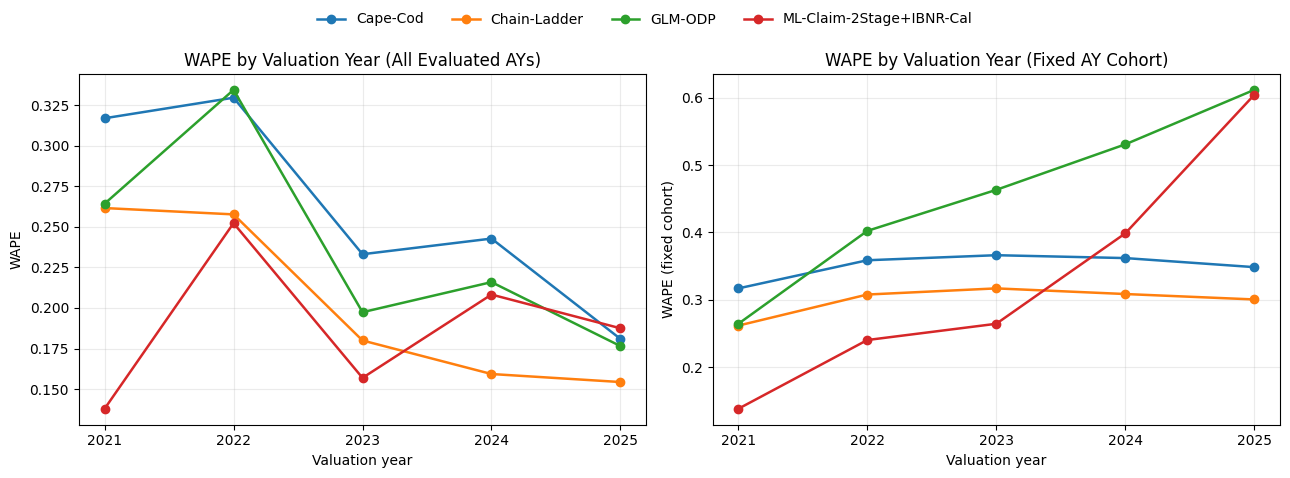

In [31]:
# Additional diagnostics: reserve-weighted error and fixed-cohort trend
if "rolling_compare_tbl" not in globals() or rolling_compare_tbl.empty:
    raise RuntimeError("rolling_compare_tbl is empty. Run Section 10 rolling-origin cells first.")
if "hybrid_compare_ml" not in globals() or hybrid_compare_ml.empty:
    raise RuntimeError("hybrid_compare_ml is empty. Run Section 12 ML cell first.")

# 1) Build granular method-year-AY table for classical + ML methods.
classical_gran = rolling_compare_tbl.loc[rolling_compare_tbl["lob"] != "All", ["valuation_pay_year", "method", "AY", "error", "true_ultimate", "latest_observed"]].copy()
classical_gran["true_reserve"] = pd.to_numeric(classical_gran["true_ultimate"], errors="coerce") - pd.to_numeric(classical_gran["latest_observed"], errors="coerce")

ml_hybrid_gran = hybrid_compare_ml.loc[hybrid_compare_ml["lob"] != "All", ["valuation_pay_year", "method", "AY", "error", "true_total_reserve"]].copy()
ml_hybrid_gran["true_reserve"] = pd.to_numeric(ml_hybrid_gran["true_total_reserve"], errors="coerce")

gran_parts = [classical_gran[["valuation_pay_year", "method", "AY", "error", "true_reserve"]], ml_hybrid_gran[["valuation_pay_year", "method", "AY", "error", "true_reserve"]]]

gran = pd.concat(gran_parts, ignore_index=True)
gran["abs_error"] = pd.to_numeric(gran["error"], errors="coerce").abs()
gran["abs_true_reserve"] = pd.to_numeric(gran["true_reserve"], errors="coerce").abs()
gran = gran.dropna(subset=["valuation_pay_year", "method", "AY"]).copy()

# Aggregate first to AY level to avoid any accidental double counting across finer segments.
gran_ay = (
    gran.groupby(["valuation_pay_year", "method", "AY"], as_index=False)
    .agg(
        abs_error=("abs_error", "sum"),
        abs_true_reserve=("abs_true_reserve", "sum"),
    )
)

# 2) Reserve-weighted metric over all evaluated AYs each valuation year.
wape_all = (
    gran_ay.groupby(["valuation_pay_year", "method"], as_index=False)
    .agg(
        abs_error_total=("abs_error", "sum"),
        abs_true_reserve_total=("abs_true_reserve", "sum"),
    )
)
wape_all["wape_all"] = np.where(
    wape_all["abs_true_reserve_total"] > 1e-9,
    wape_all["abs_error_total"] / wape_all["abs_true_reserve_total"],
    np.nan,
 )

# 3) Fixed-cohort trend: keep AYs present in every valuation year (reference: Chain-Ladder).
vals_sorted = sorted(gran_ay["valuation_pay_year"].dropna().astype(int).unique().tolist())
ref = gran_ay.loc[gran_ay["method"] == "Chain-Ladder"].copy()
if ref.empty:
    ref = gran_ay.copy()

ay_sets = []
for v in vals_sorted:
    ay_sets.append(set(ref.loc[ref["valuation_pay_year"] == int(v), "AY"].dropna().astype(int).tolist()))
common_ay = sorted(set.intersection(*ay_sets)) if ay_sets else []

if not common_ay:
    print("No common AY cohort across valuation years; fixed-cohort diagnostic skipped.")
    wape_fixed = pd.DataFrame(columns=["valuation_pay_year", "method", "wape_fixed", "mae_ay_fixed", "n_common_ay"])
else:
    fixed = gran_ay.loc[gran_ay["AY"].astype(int).isin(common_ay)].copy()
    wape_fixed = (
        fixed.groupby(["valuation_pay_year", "method"], as_index=False)
        .agg(
            abs_error_total=("abs_error", "sum"),
            abs_true_reserve_total=("abs_true_reserve", "sum"),
            mae_ay_fixed=("abs_error", "mean"),
            n_common_ay=("AY", "nunique"),
        )
    )
    wape_fixed["wape_fixed"] = np.where(
        wape_fixed["abs_true_reserve_total"] > 1e-9,
        wape_fixed["abs_error_total"] / wape_fixed["abs_true_reserve_total"],
        np.nan,
    )

# 4) Plot WAPE all vs fixed cohort.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for method, sub in wape_all.sort_values("valuation_pay_year").groupby("method"):
    axes[0].plot(sub["valuation_pay_year"], sub["wape_all"], marker="o", linewidth=1.8, label=method)
axes[0].set_title("WAPE by Valuation Year (All Evaluated AYs)")
axes[0].set_xlabel("Valuation year")
axes[0].set_ylabel("WAPE")
axes[0].set_xticks(sorted(wape_all["valuation_pay_year"].astype(int).unique()))
axes[0].grid(alpha=0.25)

if not wape_fixed.empty:
    for method, sub in wape_fixed.sort_values("valuation_pay_year").groupby("method"):
        axes[1].plot(sub["valuation_pay_year"], sub["wape_fixed"], marker="o", linewidth=1.8, label=method)
    axes[1].set_title("WAPE by Valuation Year (Fixed AY Cohort)")
    axes[1].set_xlabel("Valuation year")
    axes[1].set_ylabel("WAPE (fixed cohort)")
    axes[1].set_xticks(sorted(wape_fixed["valuation_pay_year"].astype(int).unique()))
    axes[1].grid(alpha=0.25)
else:
    axes[1].text(0.5, 0.5, "No fixed cohort available", ha="center", va="center")
    axes[1].set_axis_off()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

### 14.b Diagnostic Summary (Interpretation)

Key takeaways from the diagnostics are:

- **Moving portfolio view (all evaluated AYs):** both MAE and reserve-weighted error (WAPE) generally decline over valuation years for most methods. This indicates improving practical forecasting performance as valuation information accumulates.
- **Fixed-cohort view (same AY set across years):** relative error measures can increase, even when absolute errors are stable or improving. This occurs because the denominator (remaining true reserve) shrinks as the cohort matures.
- **Main implication:** the downward trend in headline MAE is driven by a combination of (i) maturing claims and richer information, and (ii) changing portfolio composition across valuation years.

For reporting and governance, it is preferable to present both perspectives:
1. a moving-book metric (operational performance), and
2. a fixed-cohort metric (method behavior under controlled composition),
together with at least one absolute metric to avoid denominator-driven distortions in late development years.

## 15. DL Pipeline (Trajectory + Two-Part + Residual/Offset, Rolling-Origin Comparable)

This section runs the final non-triangle DL attempt: a claim-level **trajectory-aware two-part model** with an explicit **residual/offset severity head**.

Design choices:
- reuse the same valuation-safe claim snapshots and the same rolling-origin target as Sections 10 and 12,
- append trajectory lags from raw yearly payment/open paths,
- split the target into occurrence of future reserve and conditional positive severity,
- let the severity head learn a residual around a monotone development-age/type prior, rather than predict raw reserve from scratch.


In [32]:
import importlib
import time
import python_reserving.dl_pipeline as dlp
import python_reserving.ml_pipeline as mlp

importlib.reload(dlp)
importlib.reload(mlp)

SCALE = float(globals().get('SCALE_DIVISOR', 1000.0))

if "rolling_summary_tbl" not in globals() or rolling_summary_tbl is None or rolling_summary_tbl.empty:
    raise RuntimeError("rolling_summary_tbl is empty. Run Section 10 first.")
if "hybrid_summary_ml" not in globals() or hybrid_summary_ml is None or hybrid_summary_ml.empty:
    raise RuntimeError("hybrid_summary_ml is empty. Run Section 12 first.")
if "valuation_years" not in globals() or valuation_years is None or len(valuation_years) == 0:
    raise RuntimeError("valuation_years is missing. Run Section 10 first.")

# Same evaluation years/slice as ML benchmark.
dl_eval_years = sorted({int(v) for v in valuation_years})
# Training-only snapshot years so every eval year (including the earliest) gets
# a full 4-snapshot training stack. Clipped to the AYs actually in the data.
min_available_ay = int(pd.to_numeric(output_df["AY"], errors="coerce").min())
dl_train_snapshot_years = [
    y for y in range(min(dl_eval_years) - 4, min(dl_eval_years)) if y >= min_available_ay
]

dl_feature_cols = list(mlp.DEFAULT_FEATURE_COLUMNS)

print("DL evaluation years:", dl_eval_years)
print("DL training-only snapshot years:", dl_train_snapshot_years)
print("Base DL feature count before trajectory augmentation:", len(dl_feature_cols))
'''
dl_rbns_compare, dl_rbns_summary, dl_hybrid_compare, dl_hybrid_summary = dlp.run_claim_level_dl_rolling_origin_backtest(
    full_paid_df=full_paid,
    full_claims_df=full_claims,
    valuation_years=dl_eval_years,
    train_snapshot_years=dl_train_snapshot_years,
    scale_divisor=SCALE,
    feature_cols=dl_feature_cols,
    raw_output_df=output_df,
    lookback_valuations=4,
    max_train_rows=220_000,
    min_rows_type_model=1_500,
    eval_recent_ay_window=None,
    hidden_layer_sizes=(192, 96, 48),
    alpha=2e-4,
    learning_rate_init=7e-4,
    max_iter=280,
    random_state=42,
    residual_clip=1.8,
    pred_cap_quantile=0.99,
    model_variant="trajectory_two_part_offset",
    add_age_features=True,
    monotone_postprocess=False,
    trajectory_n_lags=6,
    n_jobs_valuation=1,
    method_name_rbns="DL-Traj2Part-Offset-RBNS-Cal",
    method_name_hybrid="DL-Traj2Part-Offset+IBNR-Cal",
)
'''
dl_summary_all = dl_hybrid_summary.copy()
if not dl_summary_all.empty:
    dl_summary_all = dl_summary_all.loc[
        (dl_summary_all["lob"] == "All")
        & (dl_summary_all["valuation_pay_year"].isin(dl_eval_years))
    ].copy()

classical_summary_all = rolling_summary_tbl.copy()
if not classical_summary_all.empty:
    classical_summary_all = classical_summary_all.loc[
        (classical_summary_all["lob"] == "All")
        & (classical_summary_all["valuation_pay_year"].isin(dl_eval_years))
    ].copy()

ml_summary_all = hybrid_summary_ml.copy()
if not ml_summary_all.empty:
    ml_summary_all = ml_summary_all.loc[
        (ml_summary_all["lob"] == "All")
        & (ml_summary_all["valuation_pay_year"].isin(dl_eval_years))
    ].copy()

combined_yearly_dl = pd.concat([classical_summary_all, ml_summary_all, dl_summary_all], ignore_index=True, sort=False)
combined_yearly_dl = combined_yearly_dl.sort_values(["valuation_pay_year", "method"]).reset_index(drop=True)

combined_rank_dl = (
    combined_yearly_dl
    .groupby("method", as_index=False)
    .agg(
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        bias_abs=("bias", lambda s: float(np.mean(np.abs(s)))),
        mape=("mape", "mean"),
        n_eval=("valuation_pay_year", "count"),
    )
    .sort_values(["mae", "rmse"])
    .reset_index(drop=True)
)

print("Trajectory two-part offset DL + ML + classical yearly metrics (All LoBs):")
display(combined_yearly_dl)
print("Trajectory two-part offset DL + ML + classical ranking (All LoBs):")
display(combined_rank_dl)

DL evaluation years: [2021, 2022, 2023, 2024, 2025]
DL training-only snapshot years: [2017, 2018, 2019, 2020]
Base DL feature count before trajectory augmentation: 20
Trajectory two-part offset DL + ML + classical yearly metrics (All LoBs):


,method,mae,rmse,bias,mape,valuation_pay_year,lob
0,Cape-Cod,2954.511937,3598.281220,-2846.609624,3.589655,2021,All
1,Chain-Ladder,3188.863018,3748.494451,-2788.348266,3.818585,2021,All
2,DL-Traj2Part-Offset+IBNR-Cal,3284.544013,4324.276725,3284.544013,3.690836,2021,All
3,GLM-ODP,3228.453665,3754.656503,-3228.453665,3.945749,2021,All
4,ML-Claim-2Stage+IBNR-Cal,1844.192552,2743.768162,-892.522129,2.148236,2021,All
5,Cape-Cod,4483.323788,7814.608381,-3878.669870,3.994579,2022,All
6,Chain-Ladder,3946.846083,6892.425692,-3764.082360,3.558402,2022,All
7,DL-Traj2Part-Offset+IBNR-Cal,3479.262571,6003.208788,-321.514985,3.044456,2022,All
8,GLM-ODP,5402.754374,8985.414034,-4658.367633,4.898169,2022,All
9,ML-Claim-2Stage+IBNR-Cal,4565.323041,8496.045630,-1086.641985,3.943243,2022,All


Trajectory two-part offset DL + ML + classical ranking (All LoBs):


,method,mae,rmse,bias_abs,mape,n_eval
0,DL-Traj2Part-Offset+IBNR-Cal,2277.573090,3526.275337,1021.846537,2.147084,5
1,Chain-Ladder,2758.833438,4576.379740,2034.804793,2.478752,5
2,ML-Claim-2Stage+IBNR-Cal,2830.877524,4371.201639,847.902838,2.625693,5
3,Cape-Cod,2901.813002,4498.078393,2049.844263,2.645507,5
4,GLM-ODP,3569.572658,4940.379476,2559.370174,3.350699,5


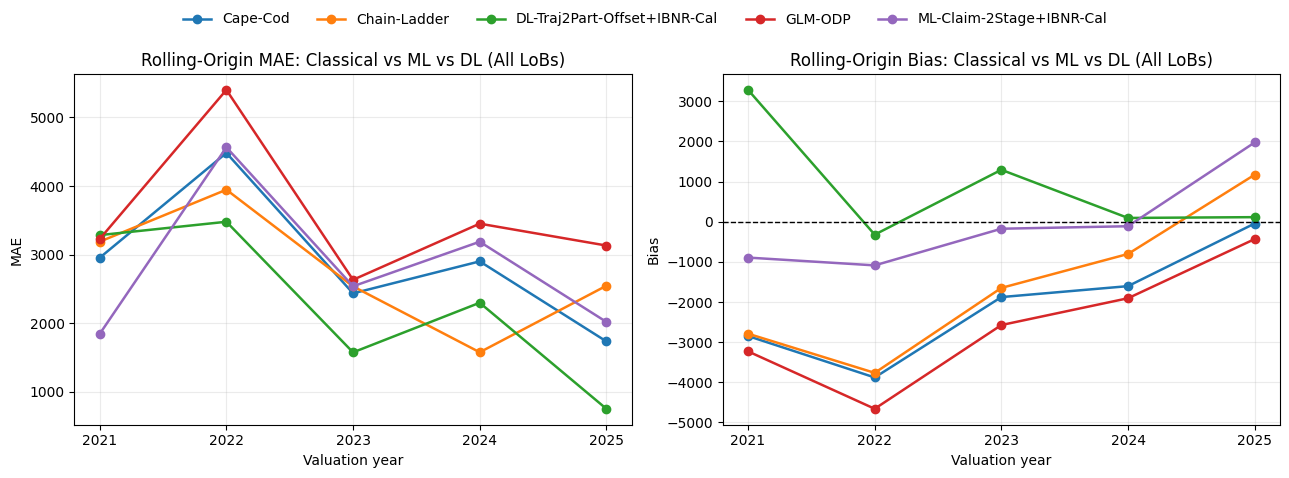

In [33]:
# Visual comparison: yearly MAE and RMSE including DL hybrid.
if "combined_yearly_dl" in globals() and not combined_yearly_dl.empty:
    plot_tbl = combined_yearly_dl.loc[combined_yearly_dl["lob"] == "All"].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    for method, sub in plot_tbl.groupby("method"):
        sub = sub.sort_values("valuation_pay_year")
        axes[0].plot(sub["valuation_pay_year"], sub["mae"], marker="o", linewidth=1.8, label=method)
        axes[1].plot(sub["valuation_pay_year"], sub["bias"], marker="o", linewidth=1.8, label=method)

    axes[0].set_title("Rolling-Origin MAE: Classical vs ML vs DL (All LoBs)")
    axes[0].set_xlabel("Valuation year")
    axes[0].set_ylabel("MAE")
    axes[0].set_xticks(sorted(plot_tbl["valuation_pay_year"].astype(int).unique()))
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Rolling-Origin Bias: Classical vs ML vs DL (All LoBs)")
    axes[1].set_xlabel("Valuation year")
    axes[1].set_ylabel("Bias")
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xticks(sorted(plot_tbl["valuation_pay_year"].astype(int).unique()))
    axes[1].grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

Section 15 interpretation note:
- The DL pipeline is benchmark-aligned (same rolling-origin target/slice and same IBNR addon structure as Section 12), so differences are mainly due to the representation model.
- This version is the strongest non-triangle micro attempt in the notebook: trajectory lags + two-part target + residual/offset severity.
- If it still does not get close to ML/classical, that is a strong argument for moving the DL effort to the triangle-based architecture family rather than tuning more tabular MLPs.


## 16. DL Anchor Blends (DL + Chain-Ladder)

This section applies the same rolling, leakage-safe blend idea used for ML:
- Blend DL reserve with an actuarial anchor reserve.
- Estimate blend weight from past valuation years only.
- Clip the learned weight to [0, 1].

Implemented blends:
- DL + Chain-Ladder

In [34]:
import importlib
import python_reserving.ml_pipeline as mlp
importlib.reload(mlp)

required_globals = ["rolling_compare_tbl", "dl_hybrid_compare", "dl_eval_years"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}. Run Sections 10 and 15 first.")

if rolling_compare_tbl is None or rolling_compare_tbl.empty:
    raise RuntimeError("rolling_compare_tbl is empty. Run Section 10 first.")
if dl_hybrid_compare is None or dl_hybrid_compare.empty:
    raise RuntimeError("dl_hybrid_compare is empty. Run Section 15 first.")

dl_key = dl_hybrid_compare.loc[
    dl_hybrid_compare["lob"] != "All",
    ["valuation_pay_year", "AY", "lob", "Type", "latest_observed", "pred_reserve", "true_total_reserve", "true_ultimate"],
].copy()
dl_key = dl_key.rename(columns={"pred_reserve": "pred_reserve_dl"})

for c in ["latest_observed", "pred_reserve_dl", "true_total_reserve", "true_ultimate"]:
    dl_key[c] = pd.to_numeric(dl_key[c], errors="coerce").fillna(0.0)

def _build_anchor_key(method_name: str, out_col: str) -> pd.DataFrame:
    anchor = rolling_compare_tbl.loc[
        (rolling_compare_tbl["method"] == method_name) & (rolling_compare_tbl["lob"] != "All"),
        ["valuation_pay_year", "AY", "lob", "latest_observed", "ultimate"],
    ].copy()
    if anchor.empty:
        raise RuntimeError(f"No rows found in rolling_compare_tbl for method='{method_name}'.")
    anchor[out_col] = pd.to_numeric(anchor["ultimate"], errors="coerce").fillna(0.0) - pd.to_numeric(anchor["latest_observed"], errors="coerce").fillna(0.0)
    return anchor[["valuation_pay_year", "AY", "lob", out_col]]

odp_key = _build_anchor_key("GLM-ODP", "pred_reserve_odp")
cl_key = _build_anchor_key("Chain-Ladder", "pred_reserve_cl")

blend_base = (
    dl_key
    .merge(odp_key, on=["valuation_pay_year", "AY", "lob"], how="inner")
    .merge(cl_key, on=["valuation_pay_year", "AY", "lob"], how="inner")
)

if blend_base.empty:
    raise RuntimeError("No overlapping DL/ODP/CL rows after merge.")

def _rolling_blend_one_weight(
    df: pd.DataFrame,
    pred_col: str,
    anchor_col: str,
    method_name: str,
    init_weight: float = 0.20,
    min_hist_rows: int = 6,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    vals = sorted(df["valuation_pay_year"].dropna().astype(int).unique().tolist())
    prev_w = float(np.clip(init_weight, 0.0, 1.0))

    blend_rows = []
    weight_rows = []

    for v in vals:
        prev = df.loc[df["valuation_pay_year"] < int(v)].copy()
        if len(prev) >= int(min_hist_rows):
            y = pd.to_numeric(prev["true_total_reserve"], errors="coerce").to_numpy(dtype=float)
            p = pd.to_numeric(prev[pred_col], errors="coerce").to_numpy(dtype=float)
            a = pd.to_numeric(prev[anchor_col], errors="coerce").to_numpy(dtype=float)
            mask = np.isfinite(y) & np.isfinite(p) & np.isfinite(a)
            if np.any(mask):
                y = y[mask]
                p = p[mask]
                a = a[mask]
                denom = float(np.sum((p - a) ** 2))
                if denom > 1e-12:
                    w = float(np.sum((y - a) * (p - a)) / denom)
                    if np.isfinite(w):
                        prev_w = float(np.clip(w, 0.0, 1.0))

        weight_rows.append({"valuation_pay_year": int(v), "w_dl": float(prev_w)})

        cur = df.loc[df["valuation_pay_year"] == int(v)].copy()
        if cur.empty:
            continue

        cur["pred_reserve_blend"] = (
            prev_w * pd.to_numeric(cur[pred_col], errors="coerce").fillna(0.0)
            + (1.0 - prev_w) * pd.to_numeric(cur[anchor_col], errors="coerce").fillna(0.0)
        )
        cur["ultimate"] = pd.to_numeric(cur["latest_observed"], errors="coerce").fillna(0.0) + cur["pred_reserve_blend"]
        cur["error"] = cur["ultimate"] - pd.to_numeric(cur["true_ultimate"], errors="coerce").fillna(0.0)
        cur["abs_error"] = cur["error"].abs()
        cur["pct_error"] = np.where(
            pd.to_numeric(cur["true_ultimate"], errors="coerce").abs() > 1e-9,
            100.0 * cur["error"] / pd.to_numeric(cur["true_ultimate"], errors="coerce"),
            np.nan,
        )
        cur["method"] = method_name
        blend_rows.append(cur)

    if not blend_rows:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(weight_rows)

    cmp = pd.concat(blend_rows, ignore_index=True)
    cmp = mlp._append_all_row(cmp, value_col="pred_reserve_blend", true_col="true_total_reserve")
    smry = mlp.summarize_ml_compare(cmp)
    return cmp, smry, pd.DataFrame(weight_rows)

dl_cl_compare, dl_cl_summary, dl_cl_weights = _rolling_blend_one_weight(
    blend_base,
    pred_col="pred_reserve_dl",
    anchor_col="pred_reserve_cl",
    method_name="DL+Chain-Ladder-Blend",
    init_weight=0.50,
    min_hist_rows=6,
)

blend_all_summaries = []
for s in [dl_cl_summary]:
    if s is not None and not s.empty:
        blend_all_summaries.append(
            s.loc[(s["lob"] == "All") & (s["valuation_pay_year"].isin(dl_eval_years))].copy()
        )

base_yearly_dl = combined_yearly_dl.copy() if "combined_yearly_dl" in globals() else pd.DataFrame()
extra_yearly = pd.concat(blend_all_summaries, ignore_index=True, sort=False) if blend_all_summaries else pd.DataFrame()
combined_yearly_dl_blend = pd.concat([base_yearly_dl, extra_yearly], ignore_index=True, sort=False) if not base_yearly_dl.empty else extra_yearly.copy()

if combined_yearly_dl_blend.empty:
    print("No blend leaderboard rows were produced.")
else:
    combined_yearly_dl_blend = combined_yearly_dl_blend.sort_values(["valuation_pay_year", "method"]).reset_index(drop=True)
    combined_rank_dl_blend = (
        combined_yearly_dl_blend
        .groupby("method", as_index=False)
        .agg(
            mae=("mae", "mean"),
            rmse=("rmse", "mean"),
            bias_abs=("bias", lambda s: float(np.mean(np.abs(s)))),
            mape=("mape", "mean"),
            n_eval=("valuation_pay_year", "count"),
        )
        .sort_values(["mae", "rmse"])
        .reset_index(drop=True)
    )

    print("DL-anchor blend weights by valuation year (Chain-Ladder anchor):")
    display(dl_cl_weights)
    print("Leaderboard with DL anchor blends added:")
    display(combined_rank_dl_blend)

DL-anchor blend weights by valuation year (Chain-Ladder anchor):


,valuation_pay_year,w_dl
0,2021,0.500000
1,2022,0.457980
2,2023,0.533041
3,2024,0.516659
4,2025,0.434237


Leaderboard with DL anchor blends added:


,method,mae,rmse,bias_abs,mape,n_eval
0,DL+Chain-Ladder-Blend,1641.567127,3023.298903,667.299961,1.352752,5
1,DL-Traj2Part-Offset+IBNR-Cal,2277.573090,3526.275337,1021.846537,2.147084,5
2,Chain-Ladder,2758.833438,4576.379740,2034.804793,2.478752,5
3,ML-Claim-2Stage+IBNR-Cal,2830.877524,4371.201639,847.902838,2.625693,5
4,Cape-Cod,2901.813002,4498.078393,2049.844263,2.645507,5
5,GLM-ODP,3569.572658,4940.379476,2559.370174,3.350699,5


Section 16 Rolling-Origin MAE by valuation year (All LoBs):


method,Cape-Cod,Chain-Ladder,DL+Chain-Ladder-Blend,DL-Traj2Part-Offset+IBNR-Cal,GLM-ODP,ML-Claim-2Stage+IBNR-Cal
valuation_pay_year,,,,,,
2021,2954.51,3188.86,1183.95,3284.54,3228.45,1844.19
2022,4483.32,3946.85,3023.28,3479.26,5402.75,4565.32
2023,2435.13,2536.77,863.87,1574.49,2632.69,2538.27
2024,2901.49,1575.86,1768.17,2297.98,3451.54,3187.69
2025,1734.61,2545.82,1368.57,751.59,3132.43,2018.92


Section 16 Rolling-Origin Bias by valuation year (All LoBs):


method,Cape-Cod,Chain-Ladder,DL+Chain-Ladder-Blend,DL-Traj2Part-Offset+IBNR-Cal,GLM-ODP,ML-Claim-2Stage+IBNR-Cal
valuation_pay_year,,,,,,
2021,-2846.61,-2788.35,127.96,3284.54,-3228.45,-892.52
2022,-3878.67,-3764.08,-2273.94,-321.51,-4658.37,-1086.64
2023,-1876.35,-1648.00,-98.83,1293.94,-2572.95,-173.83
2024,-1603.85,-802.35,-303.65,94.60,-1905.16,-111.62
2025,-43.74,1171.25,532.12,114.63,-431.92,1974.90


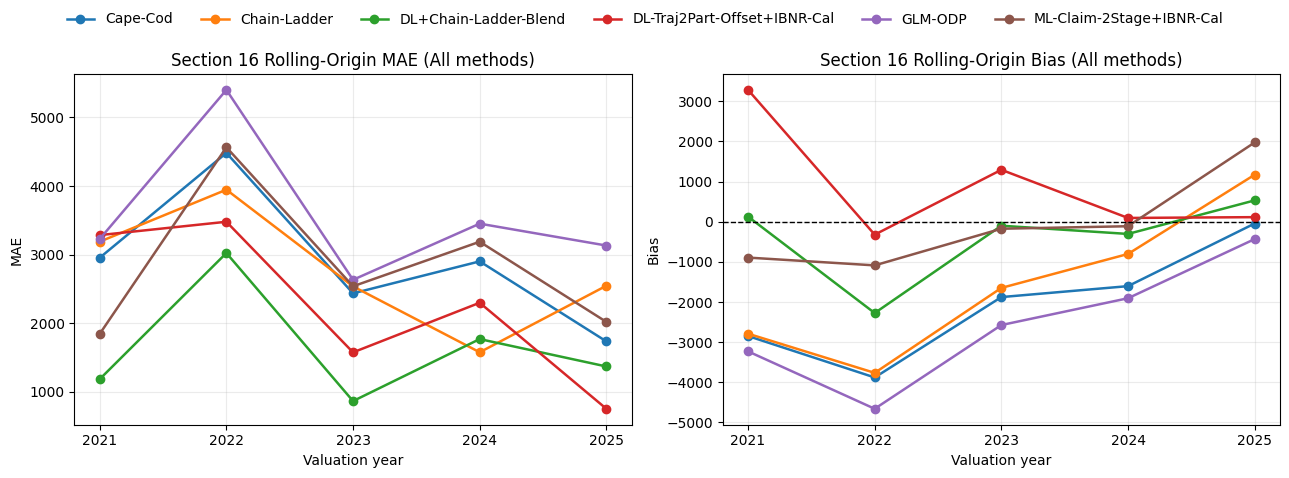

In [35]:
# Section 16 visualization: print blend weights and compare rolling-origin performance across all methods.
plot_tbl = combined_yearly_dl_blend.loc[combined_yearly_dl_blend["lob"] == "All"].copy()
if plot_tbl.empty:
    print("No portfolio-level rows available for plotting.")
else:
    yearly = (
        plot_tbl.groupby(["valuation_pay_year", "method"], as_index=False)
        .agg(mae=("mae", "mean"), bias=("bias", "mean"))
        .sort_values(["valuation_pay_year", "method"])
)

    mae_by_year = (
        yearly.pivot(index="valuation_pay_year", columns="method", values="mae")
        .sort_index()
    )
    bias_by_year = (
        yearly.pivot(index="valuation_pay_year", columns="method", values="bias")
        .sort_index()
    )
    print("Section 16 Rolling-Origin MAE by valuation year (All LoBs):")
    display(mae_by_year.round(2))
    print("Section 16 Rolling-Origin Bias by valuation year (All LoBs):")
    display(bias_by_year.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    for method, sub in yearly.groupby("method"):
        sub = sub.sort_values("valuation_pay_year")
        axes[0].plot(sub["valuation_pay_year"], sub["mae"], marker="o", linewidth=1.8, label=method)
        axes[1].plot(sub["valuation_pay_year"], sub["bias"], marker="o", linewidth=1.8, label=method)

    axes[0].set_title("Section 16 Rolling-Origin MAE (All methods)")
    axes[0].set_xlabel("Valuation year")
    axes[0].set_ylabel("MAE")
    axes[0].set_xticks(sorted(yearly["valuation_pay_year"].astype(int).unique()))
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Section 16 Rolling-Origin Bias (All methods)")
    axes[1].set_xlabel("Valuation year")
    axes[1].set_ylabel("Bias")
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xticks(sorted(yearly["valuation_pay_year"].astype(int).unique()))
    axes[1].grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

## 17. Triangle-Based DL (Claim-Level Chain-Ladder-Style NN, Rolling-Origin Comparable)

This section runs the active triangle DL implementation called through `run_triangle_dl_rolling_origin_backtest`.

Core idea:
- Build claim-level cumulative paths C0..Cmax from Pay00..PayNN.
- For each development step j, train a dedicated neural network to project the next cumulative amount.
- Apply valuation-safe masking so AY + DY > valuation year is treated as unobserved.
- Use claim-level micro covariates (transformed age and one-hot encoded Type, AQ, cc, inj_part).
- Aggregate claim-level predictions back to AY and evaluate on the same rolling-origin target as earlier sections.

Implementation choices in this version:
- Per-development TensorFlow dense model with tanh hidden layers and exponential positive output.
- Volume scaling using sqrt of previous cumulative amount and empirical fallback ratio when data are sparse.
- Additional zero-claim recursion component per LoB, then combine nonzero and zero components.
- Same rolling-origin evaluation framing as earlier sections.

In [36]:
import importlib
import python_reserving.dl_triangle as dlt

importlib.reload(dlt)

required_globals = ["output_df", "valuation_years", "SCALE_DIVISOR", "CLAIM_TYPE"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}. Run Sections 1, 10 and 15 first.")

triangle_eval_years = sorted({int(v) for v in valuation_years})

print("Triangle DL valuation years:", triangle_eval_years, ")")
'''
# Tuned default from Section 17.2 anti-overfit sweep.
triangle_dl_compare, triangle_dl_summary = dlt.run_triangle_dl_rolling_origin_backtest(
    output_df=output_df,
    valuation_years=triangle_eval_years,
    claim_type=CLAIM_TYPE,
    scale_divisor=float(SCALE_DIVISOR),
    lookback_valuations=0,
    min_train_rows=20,
    hidden_layer_sizes=(24,),
    alpha=2e-3,
    learning_rate_init=1e-3,
    max_iter=280,
    random_state=42,
    factor_floor=1.0,
    factor_cap=3.0,
    credibility_k=25.0,
    eval_recent_ay_window=None,
    method_name="DL-Triangle-LinkRatio-NN-Tuned",
)
'''
triangle_dl_summary_all = triangle_dl_summary.copy()
if not triangle_dl_summary_all.empty:
    triangle_dl_summary_all = triangle_dl_summary_all.loc[
        (triangle_dl_summary_all["lob"] == "All")
        & (triangle_dl_summary_all["valuation_pay_year"].isin(triangle_eval_years))
    ].copy()

base_yearly = pd.DataFrame()
if "combined_yearly_dl_blend" in globals() and combined_yearly_dl_blend is not None and not combined_yearly_dl_blend.empty:
    base_yearly = combined_yearly_dl_blend.copy()
elif "combined_yearly_dl" in globals() and combined_yearly_dl is not None and not combined_yearly_dl.empty:
    base_yearly = combined_yearly_dl.copy()
elif "combined_yearly" in globals() and combined_yearly is not None and not combined_yearly.empty:
    base_yearly = combined_yearly.copy()

if not base_yearly.empty:
    base_yearly = base_yearly.loc[
        (base_yearly["lob"] == "All")
        & (base_yearly["valuation_pay_year"].isin(triangle_eval_years))
    ].copy()

if base_yearly.empty:
    triangle_combined_yearly = triangle_dl_summary_all.copy()
else:
    triangle_combined_yearly = pd.concat([base_yearly, triangle_dl_summary_all], ignore_index=True, sort=False)

if triangle_combined_yearly.empty:
    print("Triangle DL produced no leaderboard rows.")
else:
    triangle_combined_yearly = triangle_combined_yearly.sort_values(["valuation_pay_year", "method"]).reset_index(drop=True)
    triangle_combined_rank = (
        triangle_combined_yearly
        .groupby("method", as_index=False)
        .agg(
            mae=("mae", "mean"),
            rmse=("rmse", "mean"),
            bias_abs=("bias", lambda s: float(np.mean(np.abs(s)))),
            mape=("mape", "mean"),
            n_eval=("valuation_pay_year", "count"),
        )
        .sort_values(["mae", "rmse"])
        .reset_index(drop=True)
    )

    print("Triangle DL rolling-origin yearly summary (All LoBs):")
    display(triangle_dl_summary_all)
    print("Leaderboard including triangle DL:")
    display(triangle_combined_rank)

Triangle DL valuation years: [2021, 2022, 2023, 2024, 2025] )
Triangle DL rolling-origin yearly summary (All LoBs):


,method,lob,valuation_pay_year,mae,rmse,bias,mape,n_obs
0,DL-Triangle-LinkRatio-NN-Tuned,All,2021,3904.305393,4456.172472,-2345.056304,4.570915,8
5,DL-Triangle-LinkRatio-NN-Tuned,All,2022,4459.367158,6015.805844,-4459.367158,4.330906,9
10,DL-Triangle-LinkRatio-NN-Tuned,All,2023,3733.142836,6204.565495,-965.031911,2.997481,10
15,DL-Triangle-LinkRatio-NN-Tuned,All,2024,2700.588085,4948.015210,919.325414,2.000756,11
20,DL-Triangle-LinkRatio-NN-Tuned,All,2025,3975.955306,9841.585830,1579.812753,2.114253,12


Leaderboard including triangle DL:


,method,mae,rmse,bias_abs,mape,n_eval
0,DL+Chain-Ladder-Blend,1641.567127,3023.298903,667.299961,1.352752,5
1,DL-Traj2Part-Offset+IBNR-Cal,2277.573090,3526.275337,1021.846537,2.147084,5
2,Chain-Ladder,2758.833438,4576.379740,2034.804793,2.478752,5
3,ML-Claim-2Stage+IBNR-Cal,2830.877524,4371.201639,847.902838,2.625693,5
4,Cape-Cod,2901.813002,4498.078393,2049.844263,2.645507,5
5,GLM-ODP,3569.572658,4940.379476,2559.370174,3.350699,5
6,DL-Triangle-LinkRatio-NN-Tuned,3754.671756,6293.228970,2053.718708,3.202862,5


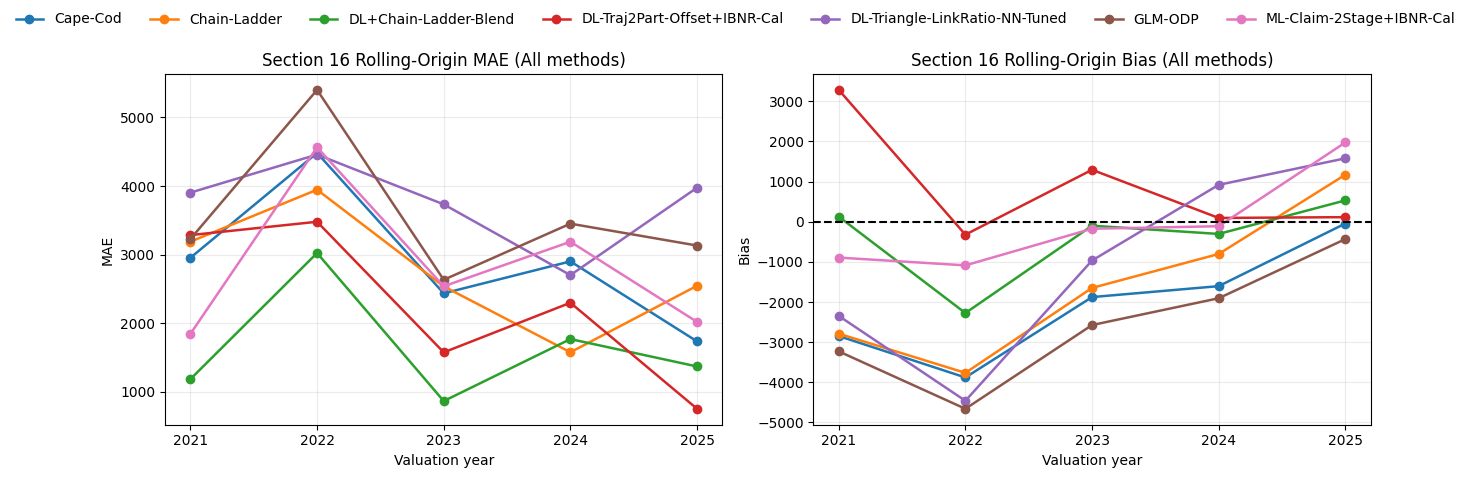

In [37]:
# Section 16 visualization: print blend weights and compare rolling-origin performance across all methods.
plot_tbl = triangle_combined_yearly.loc[triangle_combined_yearly["lob"] == "All"].copy()
if plot_tbl.empty:
    print("No portfolio-level rows available for plotting.")
else:
    yearly = (
        plot_tbl.groupby(["valuation_pay_year", "method"], as_index=False)
        .agg(mae=("mae", "mean"), bias=("bias", "mean"))
        .sort_values(["valuation_pay_year", "method"])
)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
    for method, sub in yearly.groupby("method"):
        sub = sub.sort_values("valuation_pay_year")
        axes[0].plot(sub["valuation_pay_year"], sub["mae"], marker="o", linewidth=1.8, label=method)
        axes[1].plot(sub["valuation_pay_year"], sub["bias"], marker="o", linewidth=1.8, label=method)

    axes[0].set_title("Section 16 Rolling-Origin MAE (All methods)")
    axes[0].set_xlabel("Valuation year")
    axes[0].set_ylabel("MAE")
    axes[0].set_xticks(sorted(yearly["valuation_pay_year"].astype(int).unique()))
    axes[0].grid(alpha=0.25)

    axes[1].set_title("Section 16 Rolling-Origin Bias (All methods)")
    axes[1].set_xlabel("Valuation year")
    axes[1].set_ylabel("Bias")
    axes[1].axhline(0.0, linestyle="--", color="black", linewidth=1.5, label="Zero bias")
    axes[1].set_xticks(sorted(yearly["valuation_pay_year"].astype(int).unique()))
    axes[1].grid(alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=max(1, len(labels)), frameon=False)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

Section 17 note:
- The active Section 17 leaderboard uses the claim-chainladder-style TensorFlow per-development recursion in `dl_triangle`.
- It is intentionally conservative and structure-preserving: one development step at a time, valuation-safe masking, and AY-level aggregation.
- If performance is competitive, the next step is richer temporal architectures while preserving the same rolling-origin protocol.

## 18. Predictive Uncertainty for ML/DL Pipelines

This section quantifies predictive uncertainty for the ML and DL pipelines, analogous to the classical bootstrap in Section 6. The objective is to produce comparable reserve distributions so that uncertainty measures (CV, quantile widths) can be directly compared across method classes.

**Approach:**
- **ML (XGBoost):** Bootstrap retraining. For each of B iterations, the training data are resampled with replacement and the two-stage XGBoost is refitted. Calibration factors are re-estimated on each bootstrap sample. This captures parameter uncertainty through data perturbation, mirroring the classical residual bootstrap.
- **DL (Trajectory NN):** Seed ensemble. For each of K seeds, the neural network is retrained from a different random initialisation on the same training data. This captures optimisation uncertainty (sensitivity to initialisation and SGD trajectory), which is the dominant source of variability in neural networks on finite data.

Both procedures are evaluated at a single fixed valuation year (matching the classical bootstrap) and produce empirical reserve distributions by accident year and for the total portfolio.


In [ ]:
import importlib
import time
import pickle
import os
import numpy as np
import pandas as pd
import python_reserving.ml_pipeline as mlp
import python_reserving.dl_pipeline as dlp

importlib.reload(mlp)
importlib.reload(dlp)

# ---- Configuration ----
SCALE = float(globals().get('SCALE_DIVISOR', 1000.0))
BOOT_VAL_YEAR = int(VALUATION_YEAR)
N_BOOT_ML  = 500    # bootstrap replications for XGBoost
N_SEEDS_ML = 20     # seed diagnostic for XGBoost (expected: near-zero CV)
N_BOOT_DL  = 100    # bootstrap replications for DL
N_SEEDS_DL = 20     # seed ensemble for DL (optimisation uncertainty)
LOOKBACK = 5
MAX_TRAIN = 250_000
MIN_TYPE  = 1_500
TRAIN_CUTOFF_LAG = 4
FEATURE_COLS = list(mlp.DEFAULT_FEATURE_COLUMNS)

print(f'Uncertainty valuation year: {BOOT_VAL_YEAR}')
print(f'ML: bootstrap B={N_BOOT_ML}, seed diagnostic K={N_SEEDS_ML}')
print(f'DL: bootstrap B={N_BOOT_DL}, seed ensemble K={N_SEEDS_DL}')

# ---- Build training + test data at fixed valuation year ----
d_test_full = mlp.build_claim_snapshot_dataset(
    full_paid_df=full_paid,
    full_claims_df=full_claims,
    valuation_year=BOOT_VAL_YEAR,
    scale_divisor=SCALE,
    include_unreported=False,
    raw_output_df=output_df,
)
d_test = d_test_full.copy()

train_cutoff = BOOT_VAL_YEAR - TRAIN_CUTOFF_LAG
all_val_years = sorted({int(v) for v in valuation_years} | {BOOT_VAL_YEAR})

d_train = mlp._stack_training_snapshots(
    full_paid_df=full_paid,
    full_claims_df=full_claims,
    valuation_years=all_val_years,
    current_valuation=BOOT_VAL_YEAR,
    train_cutoff=train_cutoff,
    scale_divisor=SCALE,
    raw_output_df=output_df,
    lookback_valuations=LOOKBACK,
    max_train_rows=MAX_TRAIN,
)

calib_val = int(d_train['valuation_year'].max())
if (d_train['valuation_year'] < calib_val).sum() >= 300:
    d_fit   = d_train.loc[d_train['valuation_year'] < calib_val].copy()
    d_calib = d_train.loc[d_train['valuation_year'] == calib_val].copy()
else:
    d_fit   = d_train.copy()
    d_calib = pd.DataFrame()

feat_cols = [c for c in FEATURE_COLS if c in d_fit.columns and c in d_test.columns]
print(f'Training rows: {len(d_fit)}, calibration rows: {len(d_calib)}, test rows: {len(d_test)}')
print(f'Features: {len(feat_cols)}')

# ---- Helpers ----
def _agg_to_ay_reserves(d_test_local, preds):
    tmp = d_test_local[['AY', 'Type']].copy()
    tmp['pred_rbns'] = np.maximum(preds, 0.0)
    return tmp.groupby('AY', as_index=False)['pred_rbns'].sum().rename(columns={'pred_rbns': 'reserve'})

def _run_ml_calib(d_fit_local, occ_params=None, sev_params=None):
    """Fit ML on d_fit_local, optionally with seeded params, calibrate, return predictions on d_test."""
    raw_pred = mlp._fit_predict_with_credibility_blend(
        d_train=d_fit_local, d_pred=d_test, feat_cols=feat_cols,
        min_rows_type_model=MIN_TYPE, occ_params=occ_params, sev_params=sev_params,
    )
    if not d_calib.empty:
        raw_calib_pred = mlp._fit_predict_with_credibility_blend(
            d_train=d_fit_local, d_pred=d_calib, feat_cols=feat_cols,
            min_rows_type_model=MIN_TYPE, occ_params=occ_params, sev_params=sev_params,
        )
        calib_eval = d_calib[['Type', 'y']].copy()
        calib_eval['pred_rbns'] = raw_calib_pred
        g_fac, t_fac = mlp._build_calibration_factors(
            calib_eval, pred_col='pred_rbns', true_col='y', min_rows_type=500
        )
        return mlp._apply_calibration(raw_pred, d_test, g_fac, t_fac, min_mix=0.35)
    return raw_pred

_DL_KW = dict(
    feat_cols=feat_cols, min_rows_type_model=MIN_TYPE,
    hidden_layer_sizes=(192, 96, 48), alpha=2e-4, learning_rate_init=7e-4,
    max_iter=280, residual_clip=1.8, pred_cap_quantile=0.99,
    model_variant='trajectory_two_part_offset', add_age_features=True,
    monotone_postprocess=False, trajectory_n_lags=6,
)

def _run_dl_calib(d_fit_local, seed):
    """Fit DL on d_fit_local with given seed, calibrate, return predictions on d_test."""
    raw_pred = dlp._fit_predict_with_credibility_blend_nn(
        d_train=d_fit_local, d_pred=d_test, random_state=seed,
        raw_output_df=output_df, scale_divisor=SCALE, **_DL_KW,
    )
    if not d_calib.empty:
        raw_calib_pred = dlp._fit_predict_with_credibility_blend_nn(
            d_train=d_fit_local, d_pred=d_calib, random_state=seed, **_DL_KW,
        )
        calib_eval = d_calib[['Type', 'y']].copy()
        calib_eval['pred_rbns'] = raw_calib_pred
        g_fac, t_fac = mlp._build_calibration_factors(
            calib_eval, pred_col='pred_rbns', true_col='y', min_rows_type=500
        )
        return mlp._apply_calibration(raw_pred, d_test, g_fac, t_fac, min_mix=0.35)
    return raw_pred

def summarize_boot(boot_df, method_name):
    rows = []
    for col in sorted([c for c in boot_df.columns if c != 'total']) + ['total']:
        vals = boot_df[col].dropna().to_numpy()
        if len(vals) == 0:
            continue
        rows.append({
            'method': method_name, 'AY': col,
            'mean_reserve':  float(np.mean(vals)),
            'std_reserve':   float(np.std(vals, ddof=1)),
            'cv_reserve':    float(np.std(vals, ddof=1) / max(np.mean(vals), 1e-9)),
            'p05':  float(np.percentile(vals, 5)),
            'p25':  float(np.percentile(vals, 25)),
            'p50':  float(np.percentile(vals, 50)),
            'p75':  float(np.percentile(vals, 75)),
            'p90':  float(np.percentile(vals, 90)),
            'p95':  float(np.percentile(vals, 95)),
            'p90_width': float(np.percentile(vals, 95) - np.percentile(vals, 5)),
            'n_boot': int(len(vals)),
        })
    return pd.DataFrame(rows)

def _make_df(reserves_list):
    df = pd.DataFrame(reserves_list)
    df.columns = [int(c) for c in df.columns]
    df['total'] = df.sum(axis=1)
    return df

rng = np.random.RandomState(42)
'''
# ==================================================================
# 1. ML BOOTSTRAP  (B=500, resample d_fit, fixed XGB seed)
# ==================================================================
print('\n--- 1/4: ML Bootstrap ---')
t0 = time.time()
ml_boot_reserves = []
for b in range(N_BOOT_ML):
    idx = rng.choice(len(d_fit), size=len(d_fit), replace=True)
    preds = _run_ml_calib(d_fit.iloc[idx].reset_index(drop=True))
    ay_res = _agg_to_ay_reserves(d_test, preds)
    ml_boot_reserves.append(dict(zip(ay_res['AY'].astype(int), ay_res['reserve'])))
    if (b + 1) % 50 == 0:
        print(f'  {b+1}/{N_BOOT_ML} ({time.time()-t0:.0f}s)')
ml_boot_df = _make_df(ml_boot_reserves)
ml_boot_summary = summarize_boot(ml_boot_df, 'ML-XGB-Bootstrap')
cv_ml_boot = ml_boot_summary.loc[ml_boot_summary['AY'] == 'total', 'cv_reserve'].iloc[0]
print(f'Done {time.time()-t0:.1f}s  |  total CV: {cv_ml_boot:.3f}')

# ==================================================================
# 2. ML SEED DIAGNOSTIC  (K=20, fixed d_fit, vary XGB random_state)
# ==================================================================
print('\n--- 2/4: ML Seed Diagnostic ---')
t0 = time.time()
ml_seed_reserves = []
for k in range(N_SEEDS_ML):
    seed_k = 200 + k * 7
    preds = _run_ml_calib(d_fit,
                          occ_params={'random_state': seed_k},
                          sev_params={'random_state': seed_k})
    ay_res = _agg_to_ay_reserves(d_test, preds)
    ml_seed_reserves.append(dict(zip(ay_res['AY'].astype(int), ay_res['reserve'])))
    if (k + 1) % 5 == 0:
        print(f'  {k+1}/{N_SEEDS_ML} (seed={seed_k}, {time.time()-t0:.0f}s)')
ml_seed_df = _make_df(ml_seed_reserves)
ml_seed_summary = summarize_boot(ml_seed_df, 'ML-XGB-Seeds')
cv_ml_seed = ml_seed_summary.loc[ml_seed_summary['AY'] == 'total', 'cv_reserve'].iloc[0]
print(f'Done {time.time()-t0:.1f}s  |  total CV: {cv_ml_seed:.4f}  (expect near 0)')

# ==================================================================
# 3. DL BOOTSTRAP  (B=100, resample d_fit, fixed seed=42)
# ==================================================================
print('\n--- 3/4: DL Bootstrap ---')
t0 = time.time()
dl_boot_reserves = []
for b in range(N_BOOT_DL):
    idx = rng.choice(len(d_fit), size=len(d_fit), replace=True)
    preds = _run_dl_calib(d_fit.iloc[idx].reset_index(drop=True), seed=42)
    ay_res = _agg_to_ay_reserves(d_test, preds)
    dl_boot_reserves.append(dict(zip(ay_res['AY'].astype(int), ay_res['reserve'])))
    print(f'  {b+1}/{N_BOOT_DL} ({time.time()-t0:.0f}s)')
dl_boot_df = _make_df(dl_boot_reserves)
dl_boot_summary = summarize_boot(dl_boot_df, 'DL-Traj-Bootstrap')
cv_dl_boot = dl_boot_summary.loc[dl_boot_summary['AY'] == 'total', 'cv_reserve'].iloc[0]
print(f'Done {time.time()-t0:.1f}s  |  total CV: {cv_dl_boot:.3f}')

# ==================================================================
# 4. DL SEED ENSEMBLE  (K=20, fixed d_fit, vary NN seed)
# ==================================================================
print('\n--- 4/4: DL Seed Ensemble ---')
t0 = time.time()
dl_seed_reserves = []
for k in range(N_SEEDS_DL):
    seed_k = 100 + k * 7
    preds = _run_dl_calib(d_fit, seed=seed_k)
    ay_res = _agg_to_ay_reserves(d_test, preds)
    dl_seed_reserves.append(dict(zip(ay_res['AY'].astype(int), ay_res['reserve'])))
    print(f'  DL seed {k+1}/{N_SEEDS_DL} (seed={seed_k}, {time.time()-t0:.0f}s)')
dl_seed_df = _make_df(dl_seed_reserves)
dl_seed_summary = summarize_boot(dl_seed_df, 'DL-Traj-Seeds')
cv_dl_seed = dl_seed_summary.loc[dl_seed_summary['AY'] == 'total', 'cv_reserve'].iloc[0]
print(f'Done {time.time()-t0:.1f}s  |  total CV: {cv_dl_seed:.3f}')
'''
ml_boot_summary = ml_boot_uncertainty['summary']
ml_boot_df = ml_boot_uncertainty['samples']
cv_ml_boot = ml_boot_summary.loc[ml_boot_summary['AY'] == 'total', 'cv_reserve'].iloc[0]

ml_seed_summary = ml_seed_uncertainty['summary']
ml_seed_df = ml_seed_uncertainty['samples']
cv_ml_seed = ml_seed_summary.loc[ml_seed_summary['AY'] == 'total', 'cv_reserve'].iloc[0]

dl_boot_summary = dl_boot_uncertainty['summary']
dl_boot_df = dl_boot_uncertainty['samples']
cv_dl_boot = dl_boot_summary.loc[dl_boot_summary['AY'] == 'total', 'cv_reserve'].iloc[0]

dl_seed_summary = dl_seed_uncertainty['summary']
dl_seed_df = dl_seed_uncertainty['samples']
cv_dl_seed = dl_seed_summary.loc[dl_seed_summary['AY'] == 'total', 'cv_reserve'].iloc[0]



# ---- Summary ----
print(f'\n=== Uncertainty CV Summary ===')
print(f'  ML bootstrap  (data):    {cv_ml_boot:.3f}')
print(f'  ML seeds      (optim.):  {cv_ml_seed:.4f}  <- expect near 0')
print(f'  DL bootstrap  (data):    {cv_dl_boot:.3f}')
print(f'  DL seeds      (optim.):  {cv_dl_seed:.3f}')

print('\n=== ML Bootstrap ===');      display(ml_boot_summary)
print('\n=== ML Seed Diagnostic ==='); display(ml_seed_summary)
print('\n=== DL Bootstrap ===');       display(dl_boot_summary)
print('\n=== DL Seed Ensemble ===');   display(dl_seed_summary)

Uncertainty valuation year: 2025
ML: bootstrap B=500, seed diagnostic K=20
DL: bootstrap B=20, seed ensemble K=20
Training rows: 189675, calibration rows: 60325, test rows: 492989
Features: 20

=== Uncertainty CV Summary ===
  ML bootstrap  (data):    0.026
  ML seeds      (optim.):  0.0048  <- expect near 0
  DL bootstrap  (data):    0.080
  DL seeds      (optim.):  0.092

=== ML Bootstrap ===


,method,AY,mean_reserve,std_reserve,cv_reserve,p05,p25,p50,p75,p90,p95,p90_width,n_boot
0,ML-XGB-Bootstrap,2014,680.890214,50.298991,0.073872,599.029221,647.320231,679.302874,710.278445,743.749716,764.738161,165.708941,500
1,ML-XGB-Bootstrap,2015,1172.378774,69.206054,0.059030,1064.717327,1127.172088,1172.510593,1218.061365,1261.979119,1289.339131,224.621804,500
2,ML-XGB-Bootstrap,2016,1425.675216,89.195893,0.062564,1282.514093,1366.905575,1417.596873,1482.114941,1541.193134,1571.833947,289.319853,500
3,ML-XGB-Bootstrap,2017,2130.968606,119.014961,0.055850,1943.486600,2057.644645,2129.299448,2213.016761,2275.505229,2325.085817,381.599217,500
4,ML-XGB-Bootstrap,2018,5484.727025,273.253236,0.049821,5029.888094,5304.744521,5492.876981,5661.612361,5833.615858,5924.013444,894.125350,500
5,ML-XGB-Bootstrap,2019,4956.683845,167.395303,0.033772,4703.258180,4837.771700,4950.836064,5075.352088,5161.984739,5241.983606,538.725425,500
6,ML-XGB-Bootstrap,2020,6996.046408,223.101835,0.031890,6646.231678,6843.860063,6993.099491,7151.871467,7261.857822,7351.214383,704.982705,500
7,ML-XGB-Bootstrap,2021,8865.441751,244.083228,0.027532,8493.438642,8693.669869,8860.926795,9032.734293,9170.890825,9274.276992,780.838351,500
8,ML-XGB-Bootstrap,2022,19402.265109,553.115663,0.028508,18511.163045,19027.882851,19417.858983,19772.812456,20083.856320,20299.388679,1788.225634,500
9,ML-XGB-Bootstrap,2023,25186.603399,755.665696,0.030003,23997.441215,24690.470293,25174.073322,25658.464818,26143.041849,26476.134979,2478.693764,500



=== ML Seed Diagnostic ===


,method,AY,mean_reserve,std_reserve,cv_reserve,p05,p25,p50,p75,p90,p95,p90_width,n_boot
0,ML-XGB-Seeds,2014,654.408489,11.761192,0.017972,638.089288,650.053837,655.609495,660.303250,664.606839,672.980280,34.890992,20
1,ML-XGB-Seeds,2015,1126.710155,22.272794,0.019768,1096.359020,1109.656364,1124.430182,1142.114888,1154.884625,1163.072517,66.713497,20
2,ML-XGB-Seeds,2016,1383.420402,19.997850,0.014455,1356.290295,1371.362170,1380.946126,1391.830762,1414.047585,1420.059301,63.769007,20
3,ML-XGB-Seeds,2017,2079.292384,26.907427,0.012941,2052.332301,2061.316542,2070.150459,2093.549945,2114.491830,2127.403999,75.071698,20
4,ML-XGB-Seeds,2018,5718.285507,74.018108,0.012944,5625.282703,5658.871850,5705.972477,5783.694678,5815.676981,5828.476883,203.194180,20
5,ML-XGB-Seeds,2019,4955.461520,39.587941,0.007989,4910.966320,4925.192481,4953.063518,4972.610172,5015.573949,5017.620072,106.653752,20
6,ML-XGB-Seeds,2020,7003.760083,55.907034,0.007982,6947.882030,6965.475003,6985.611181,7022.758514,7093.961710,7123.757181,175.875151,20
7,ML-XGB-Seeds,2021,8816.162931,83.005455,0.009415,8693.402160,8744.994587,8808.581351,8870.627518,8923.223708,8956.313743,262.911583,20
8,ML-XGB-Seeds,2022,19335.508567,120.128966,0.006213,19132.971962,19264.503878,19333.720591,19407.230790,19491.476837,19502.206005,369.234043,20
9,ML-XGB-Seeds,2023,24834.594623,137.721887,0.005546,24639.274609,24704.176406,24833.601231,24936.789776,25004.046355,25040.620778,401.346170,20



=== DL Bootstrap ===


,method,AY,mean_reserve,std_reserve,cv_reserve,p05,p25,p50,p75,p90,p95,p90_width,n_boot
0,DL-Traj-Bootstrap,2014,249.291694,68.969948,0.276664,167.066880,188.725860,239.939653,302.783624,326.680683,370.662829,203.595949,100
1,DL-Traj-Bootstrap,2015,656.964187,103.256384,0.157172,497.605284,596.341366,658.059780,700.680367,807.995518,843.797836,346.192553,100
2,DL-Traj-Bootstrap,2016,879.168521,128.132875,0.145743,692.247584,790.720695,869.608303,931.695983,1069.561189,1122.495677,430.248093,100
3,DL-Traj-Bootstrap,2017,1513.635041,178.915800,0.118203,1261.662245,1388.377335,1516.419357,1613.672318,1720.767009,1738.103532,476.441287,100
4,DL-Traj-Bootstrap,2018,4169.350549,670.395050,0.160791,3151.986627,3596.677119,4216.432858,4803.947243,4939.173300,5009.631568,1857.644941,100
5,DL-Traj-Bootstrap,2019,4028.552709,492.489564,0.122250,3256.194561,3662.723088,4044.013455,4282.427906,4666.092542,4832.770769,1576.576208,100
6,DL-Traj-Bootstrap,2020,6201.589821,534.995498,0.086267,5474.558591,5755.763580,6245.420964,6578.652814,6689.711644,6861.296279,1386.737688,100
7,DL-Traj-Bootstrap,2021,7145.462936,806.888139,0.112923,5986.213075,6372.253796,7145.451819,7709.552976,7940.063539,8437.930809,2451.717735,100
8,DL-Traj-Bootstrap,2022,19500.927308,2984.260496,0.153032,15595.290513,17330.180065,18611.317107,22114.827087,22700.657053,24267.020138,8671.729625,100
9,DL-Traj-Bootstrap,2023,22455.883420,2177.941775,0.096988,19903.685180,20599.712403,22171.121473,23966.299109,25095.781751,25401.133702,5497.448521,100



=== DL Seed Ensemble ===


,method,AY,mean_reserve,std_reserve,cv_reserve,p05,p25,p50,p75,p90,p95,p90_width,n_boot
0,DL-Traj-SeedEnsemble,2014,277.507830,38.058173,0.137143,228.026519,253.525094,276.156623,305.229667,326.184082,330.006878,101.980359,20
1,DL-Traj-SeedEnsemble,2015,738.578154,84.356372,0.114215,598.168516,678.818687,747.441947,786.984386,849.239383,867.445342,269.276826,20
2,DL-Traj-SeedEnsemble,2016,955.696452,81.545325,0.085326,814.250552,911.731940,965.793651,1017.245030,1052.796877,1061.957445,247.706893,20
3,DL-Traj-SeedEnsemble,2017,1714.318899,284.052832,0.165694,1415.330914,1545.416881,1678.985013,1737.521805,1873.913282,2337.913233,922.582319,20
4,DL-Traj-SeedEnsemble,2018,4809.105453,837.489205,0.174147,3724.867586,4156.353735,4801.676704,5372.222115,5814.542082,5963.415453,2238.547867,20
5,DL-Traj-SeedEnsemble,2019,4608.869635,741.018489,0.160781,3748.971165,4182.309652,4434.290149,5152.272519,5557.545173,5837.106304,2088.135139,20
6,DL-Traj-SeedEnsemble,2020,6046.410975,697.105728,0.115292,5175.108714,5466.235213,5795.248438,6733.563975,6846.506002,7052.730167,1877.621453,20
7,DL-Traj-SeedEnsemble,2021,7451.703576,671.266566,0.090082,6632.139694,7041.383768,7342.415506,7829.145330,8278.836439,8361.389662,1729.249967,20
8,DL-Traj-SeedEnsemble,2022,21938.865328,2168.472544,0.098842,19539.928451,20839.878266,21512.437204,22415.338818,24047.558649,27220.852803,7680.924352,20
9,DL-Traj-SeedEnsemble,2023,22772.537803,2683.438593,0.117837,20252.630045,20918.095013,22020.452800,23727.837429,24984.191766,26270.468134,6017.838089,20


=== Total Portfolio Reserve Uncertainty Comparison ===


,method,source,mean,cv,p90_width
0,ML-XGB-Bootstrap,data,236083.934006,0.025630,19766.714069
1,ML-XGB-Seeds,optimisation,236701.238158,0.004815,2943.643150
2,DL-Traj-Bootstrap,data,224082.714165,0.080346,51484.275929
3,DL-Traj-Seeds,optimisation,237544.133693,0.092214,60034.833807
4,Cape-Cod,data (classical),238517.760892,0.022974,17633.151706
5,Chain-Ladder,data (classical),252968.464415,0.021536,18777.930891
6,GLM-ODP,data (classical),244044.148046,0.060906,48403.547880


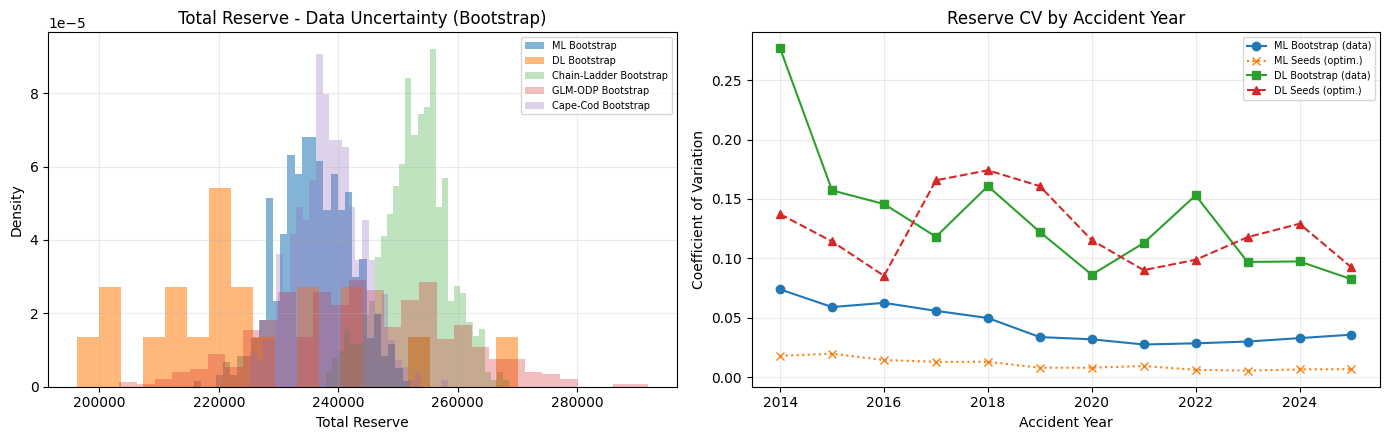

In [130]:
# Compare uncertainty: ML bootstrap, DL bootstrap, DL seeds, ML seed diagnostic
import matplotlib.pyplot as plt

total_ml_boot = ml_boot_summary.loc[ml_boot_summary['AY'] == 'total'].iloc[0] if not ml_boot_summary.empty else None
total_ml_seed = ml_seed_summary.loc[ml_seed_summary['AY'] == 'total'].iloc[0] if not ml_seed_summary.empty else None
total_dl_boot = dl_boot_summary.loc[dl_boot_summary['AY'] == 'total'].iloc[0] if not dl_boot_summary.empty else None
total_dl_seed = dl_seed_summary.loc[dl_seed_summary['AY'] == 'total'].iloc[0] if not dl_seed_summary.empty else None

# Combine classical bootstrap total if available
if 'boot' in globals() and boot is not None:
    from python_reserving.benchmark_engine import summarize_bootstrap
    _, classical_total = summarize_bootstrap(boot)
else:
    classical_total = pd.DataFrame()

# Summary table
summary_rows = []
if total_ml_boot is not None:
    summary_rows.append({'method': 'ML-XGB-Bootstrap', 'source': 'data',
                         'mean': total_ml_boot['mean_reserve'], 'cv': total_ml_boot['cv_reserve'],
                         'p90_width': total_ml_boot['p90_width']})
if total_ml_seed is not None:
    summary_rows.append({'method': 'ML-XGB-Seeds', 'source': 'optimisation',
                         'mean': total_ml_seed['mean_reserve'], 'cv': total_ml_seed['cv_reserve'],
                         'p90_width': total_ml_seed['p90_width']})
if total_dl_boot is not None:
    summary_rows.append({'method': 'DL-Traj-Bootstrap', 'source': 'data',
                         'mean': total_dl_boot['mean_reserve'], 'cv': total_dl_boot['cv_reserve'],
                         'p90_width': total_dl_boot['p90_width']})
if total_dl_seed is not None:
    summary_rows.append({'method': 'DL-Traj-Seeds', 'source': 'optimisation',
                         'mean': total_dl_seed['mean_reserve'], 'cv': total_dl_seed['cv_reserve'],
                         'p90_width': total_dl_seed['p90_width']})
if not classical_total.empty:
    for _, row in classical_total.iterrows():
        cv = float(row['std']) / max(float(row['mean']), 1e-9)
        p90_width = float(row.get('q95', 0)) - float(row.get('q05', 0))
        summary_rows.append({'method': row['method'], 'source': 'data (classical)',
                              'mean': row['mean'], 'cv': cv, 'p90_width': p90_width})

uncertainty_comparison = pd.DataFrame(summary_rows)
print('=== Total Portfolio Reserve Uncertainty Comparison ===')
display(uncertainty_comparison)

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: bootstrap distributions only (apples-to-apples: data uncertainty)
if 'total' in ml_boot_df.columns:
    axes[0].hist(ml_boot_df['total'], bins=30, alpha=0.55, label='ML Bootstrap', density=True)
if 'total' in dl_boot_df.columns:
    axes[0].hist(dl_boot_df['total'], bins=20, alpha=0.55, label='DL Bootstrap', density=True)
if 'boot' in globals() and boot is not None:
    for method_name, b in boot.items():
        axes[0].hist(b.reserve_samples_total, bins=30, alpha=0.3,
                     label=f'{method_name} Bootstrap', density=True)
axes[0].set_title('Total Reserve - Data Uncertainty (Bootstrap)')
axes[0].set_xlabel('Total Reserve')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.25)

# Right: CV by AY - data vs optimisation uncertainty
ay_cols = sorted([c for c in ml_boot_df.columns if c != 'total'])
ml_boot_cv = [float(np.std(ml_boot_df[ay], ddof=1) / max(np.mean(ml_boot_df[ay]), 1e-9)) for ay in ay_cols]
ml_seed_cv = [float(np.std(ml_seed_df[ay], ddof=1) / max(np.mean(ml_seed_df[ay]), 1e-9)) for ay in ay_cols]
dl_boot_cv = [float(np.std(dl_boot_df[ay], ddof=1) / max(np.mean(dl_boot_df[ay]), 1e-9)) for ay in ay_cols]
dl_seed_cv = [float(np.std(dl_seed_df[ay], ddof=1) / max(np.mean(dl_seed_df[ay]), 1e-9)) for ay in ay_cols]
axes[1].plot(ay_cols, ml_boot_cv, marker='o', linestyle='-',  label='ML Bootstrap (data)')
axes[1].plot(ay_cols, ml_seed_cv, marker='x', linestyle=':',  label='ML Seeds (optim.)')
axes[1].plot(ay_cols, dl_boot_cv, marker='s', linestyle='-',  label='DL Bootstrap (data)')
axes[1].plot(ay_cols, dl_seed_cv, marker='^', linestyle='--', label='DL Seeds (optim.)')
axes[1].set_title('Reserve CV by Accident Year')
axes[1].set_xlabel('Accident Year')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

C:\Users\ourri\AppData\Local\Temp\ipykernel_16060\3496175048.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_to_plot, labels=labels, showfliers=False, vert=False)


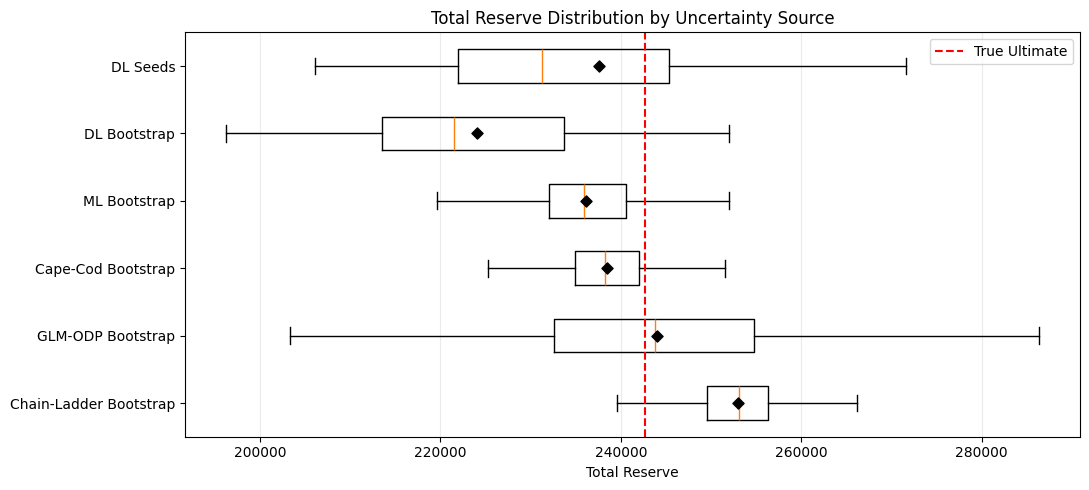

In [131]:
# Boxplot of total reserve distributions across all uncertainty sources
fig, ax = plt.subplots(figsize=(11, 5))
data_to_plot = []
labels = []
if 'boot' in globals() and boot is not None:
    for method_name, b in boot.items():
        data_to_plot.append(b.reserve_samples_total.values)
        labels.append(f'{method_name} Bootstrap')
if 'total' in ml_boot_df.columns:
    data_to_plot.append(ml_boot_df['total'].values)
    labels.append('ML Bootstrap')
if 'total' in dl_boot_df.columns:
    data_to_plot.append(dl_boot_df['total'].values)
    labels.append('DL Bootstrap')
if 'total' in dl_seed_df.columns:
    data_to_plot.append(dl_seed_df['total'].values)
    labels.append('DL Seeds')
ax.boxplot(data_to_plot, labels=labels, showfliers=False, vert=False)
for i, vals in enumerate(data_to_plot):
    ax.scatter(np.mean(vals), i + 1, marker='D', color='black', s=32, zorder=3)
ax.set_title('Total Reserve Distribution by Uncertainty Source')
ax.set_xlabel('Total Reserve')
ax.grid(alpha=0.25, axis='x')
if 'true_ultimate' in globals():
    ax.axvline(true_ultimate.iloc[-1], color='red', linestyle='--', label='True Ultimate')
    ax.legend()
plt.tight_layout()
plt.show()

### 18.1 DL Triangle (Chain-Ladder-Style NN) Uncertainty

Quantify predictive uncertainty for the triangle-based DL model using the same **symmetric 2x2 framework** as for the claim-level pipelines above:

- **Bootstrap (B=100)**: resample `claims_cum` at the claim level with replacement, keep seed fixed — captures data/parameter uncertainty.
- **Seed ensemble (K=20)**: keep `claims_cum` fixed, vary NN `random_state` — captures optimisation uncertainty (sensitivity to weight initialisation and SGD trajectory).

In [ ]:
import importlib
import time
import numpy as np
import pandas as pd
import python_reserving.dl_triangle as dlt

importlib.reload(dlt)

# ---- Configuration ----
SCALE = float(globals().get('SCALE_DIVISOR', 1000.0))
BOOT_VAL_YEAR = int(VALUATION_YEAR)
N_BOOT_TRI  = 100    # bootstrap replications (resample claims_cum)
N_SEEDS_TRI = 20    # seed ensemble (vary NN random_state)
CLAIM_TYPE_BOOT = globals().get('CLAIM_TYPE', None)

print(f'DL Triangle uncertainty valuation year: {BOOT_VAL_YEAR}')
print(f'DL Triangle: bootstrap B={N_BOOT_TRI}, seed ensemble K={N_SEEDS_TRI}')

# ---- Prepare claim-level cumulative data (same as Section 17) ----
claims_cum, c_cols, max_dev = dlt._prepare_claim_level_cumulative_output(
    output_df=output_df,
    claim_type=CLAIM_TYPE_BOOT,
    scale_divisor=SCALE,
)
X_all = dlt._encode_claim_level_features(claims_cum)
print(f'Claims: {len(claims_cum)}, dev steps: {len(c_cols)}, features: {X_all.shape[1]}')

# ---- Hyperparameters (match Section 17 tuned settings) ----
TRI_HIDDEN   = (24,)
TRI_ALPHA    = 2e-3
TRI_LR       = 1e-3
TRI_MAX_ITER = 280
TRI_MIN_TRAIN = 20

# ---- Helper: summarise bootstrap samples ----
def summarize_boot(boot_df, method_name):
    rows = []
    for col in sorted([c for c in boot_df.columns if c != 'total']) + ['total']:
        vals = boot_df[col].dropna().to_numpy()
        if len(vals) == 0:
            continue
        rows.append({
            'method': method_name, 'AY': col,
            'mean_reserve':  float(np.mean(vals)),
            'std_reserve':   float(np.std(vals, ddof=1)),
            'cv_reserve':    float(np.std(vals, ddof=1) / max(np.mean(vals), 1e-9)),
            'p05':  float(np.percentile(vals, 5)),
            'p25':  float(np.percentile(vals, 25)),
            'p50':  float(np.percentile(vals, 50)),
            'p75':  float(np.percentile(vals, 75)),
            'p90':  float(np.percentile(vals, 90)),
            'p95':  float(np.percentile(vals, 95)),
            'p90_width': float(np.percentile(vals, 95) - np.percentile(vals, 5)),
            'n_boot': int(len(vals)),
        })
    return pd.DataFrame(rows)

def _make_df(reserves_list):
    df = pd.DataFrame(reserves_list)
    df.columns = [int(c) for c in df.columns]
    df['total'] = df.sum(axis=1)
    return df

rng = np.random.RandomState(42)
'''
# ==================================================================
# 1. DL TRIANGLE BOOTSTRAP  (B=100, resample claims_cum, fixed seed=42)
# ==================================================================
# Note: _predict_claim_chainladder_style_for_valuation re-encodes features
# from claims_cum internally, so resampling claims_cum is sufficient.
print('--- 1/2: DL Triangle Bootstrap ---')
t0 = time.time()
tri_boot_reserves = []
for b in range(N_BOOT_TRI):
    idx = rng.choice(len(claims_cum), size=len(claims_cum), replace=True)
    boot_claims = claims_cum.iloc[idx].reset_index(drop=True)

    pred_tbl = dlt._predict_claim_chainladder_style_for_valuation(
        claims_cum=boot_claims,
        X_all=X_all,          # unused internally; function re-encodes from claims_cum
        c_cols=c_cols,
        valuation_year=BOOT_VAL_YEAR,
        claim_type=CLAIM_TYPE_BOOT,
        hidden_layer_sizes=TRI_HIDDEN,
        alpha=TRI_ALPHA,
        learning_rate_init=TRI_LR,
        max_iter=TRI_MAX_ITER,
        random_state=42,      # fixed seed; variation comes from data only
        min_train_rows=TRI_MIN_TRAIN,
        method_name='DL-Triangle-Bootstrap',
    )
    if not pred_tbl.empty:
        ay_res = dict(zip(pred_tbl['AY'].astype(int), pred_tbl['pred_reserve'].astype(float)))
        tri_boot_reserves.append(ay_res)
    print(f'  {b+1}/{N_BOOT_TRI} ({time.time()-t0:.0f}s)')

tri_boot_df = _make_df(tri_boot_reserves)
tri_boot_summary = summarize_boot(tri_boot_df, 'DL-Triangle-Bootstrap')
cv_tri_boot = tri_boot_summary.loc[tri_boot_summary['AY'] == 'total', 'cv_reserve'].iloc[0]
print(f'Done {time.time()-t0:.1f}s  |  total CV: {cv_tri_boot:.3f}')

# ==================================================================
# 2. DL TRIANGLE SEED ENSEMBLE  (K=20, fixed claims_cum, vary random_state)
# ==================================================================
print('--- 2/2: DL Triangle Seed Ensemble ---')

t0 = time.time()
tri_seed_reserves = []
for k in range(N_SEEDS_TRI):
    seed_k = 300 + k * 11   # offset from trajectory seeds (100+k*7) and ML seeds (200+k*7)

    pred_tbl = dlt._predict_claim_chainladder_style_for_valuation(
        claims_cum=claims_cum,
        X_all=X_all,
        c_cols=c_cols,
        valuation_year=BOOT_VAL_YEAR,
        claim_type=CLAIM_TYPE_BOOT,
        hidden_layer_sizes=TRI_HIDDEN,
        alpha=TRI_ALPHA,
        learning_rate_init=TRI_LR,
        max_iter=TRI_MAX_ITER,
        random_state=seed_k,
        min_train_rows=TRI_MIN_TRAIN,
        method_name='DL-Triangle-Seeds',
    )
    if not pred_tbl.empty:
        ay_res = dict(zip(pred_tbl['AY'].astype(int), pred_tbl['pred_reserve'].astype(float)))
        tri_seed_reserves.append(ay_res)
    print(f'  seed {k+1}/{N_SEEDS_TRI} (seed={seed_k}, {time.time()-t0:.0f}s)')

tri_seed_df = _make_df(tri_seed_reserves)
tri_seed_summary = summarize_boot(tri_seed_df, 'DL-Triangle-Seeds')
cv_tri_seed = tri_seed_summary.loc[tri_seed_summary['AY'] == 'total', 'cv_reserve'].iloc[0]
print(f'Done {time.time()-t0:.1f}s  |  total CV: {cv_tri_seed:.3f}')
'''
# ---- Summary ----
tri_seed_summary = tri_dl_seed_uncertainty['summary']
tri_seed_df = tri_dl_seed_uncertainty['samples']
cv_tri_seed = tri_seed_summary.loc[tri_seed_summary['AY'] == 'total', 'cv_reserve'].iloc[0]

tri_boot_summary = tri_dl_boot_uncertainty['summary']
tri_boot_df = tri_dl_boot_uncertainty['samples']
cv_tri_boot = tri_boot_summary.loc[tri_boot_summary['AY'] == 'total', 'cv_reserve'].iloc[0]

print(f'\n=== DL Triangle Uncertainty CV Summary ===')
print(f'  Bootstrap (data):    {cv_tri_boot:.3f}')
print(f'  Seeds (optimisation): {cv_tri_seed:.3f}')

print('\n=== DL Triangle Bootstrap ===');      display(tri_boot_summary)
print('\n=== DL Triangle Seed Ensemble ===');   display(tri_seed_summary)

DL Triangle uncertainty valuation year: 2025
DL Triangle: bootstrap B=100, seed ensemble K=20
Claims: 499566, dev steps: 12, features: 106

=== DL Triangle Uncertainty CV Summary ===
  Bootstrap (data):    0.074
  Seeds (optimisation): 0.032

=== DL Triangle Bootstrap ===


,method,AY,mean_reserve,std_reserve,cv_reserve,p05,p25,p50,p75,p90,p95,p90_width,n_boot
0,DL-Triangle-Bootstrap,2014,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100
1,DL-Triangle-Bootstrap,2015,72.876421,83.751026,1.149220,0.000000,0.000000,36.440498,138.738415,180.175615,226.299690,226.299690,100
2,DL-Triangle-Bootstrap,2016,193.371655,170.774946,0.883144,0.000000,63.726775,176.977643,278.839221,393.318399,487.688839,487.688839,100
3,DL-Triangle-Bootstrap,2017,651.358488,371.457325,0.570281,124.391734,372.796208,620.308500,883.094657,1029.631625,1352.489976,1228.098241,100
4,DL-Triangle-Bootstrap,2018,1696.445256,472.595085,0.278580,1027.109923,1405.469209,1681.480577,2000.022728,2285.582592,2442.559582,1415.449659,100
5,DL-Triangle-Bootstrap,2019,2870.468781,709.942426,0.247326,1913.813656,2405.333304,2780.583297,3171.247450,3736.050000,4394.469471,2480.655815,100
6,DL-Triangle-Bootstrap,2020,4420.967598,754.831122,0.170739,3297.327846,3906.304055,4385.103619,4802.070559,5443.352916,5843.812024,2546.484178,100
7,DL-Triangle-Bootstrap,2021,6105.353026,854.736267,0.139998,4820.341024,5448.845131,6097.161569,6605.934701,7283.701490,7595.778979,2775.437955,100
8,DL-Triangle-Bootstrap,2022,14377.069442,2285.660838,0.158980,11602.526661,12681.395034,14304.664199,15819.414068,16864.626120,18114.885837,6512.359176,100
9,DL-Triangle-Bootstrap,2023,25287.514146,13680.633797,0.541004,20358.069362,21759.832437,23279.454539,24967.781990,27585.547177,29294.726662,8936.657300,100



=== DL Triangle Seed Ensemble ===


,method,AY,mean_reserve,std_reserve,cv_reserve,p05,p25,p50,p75,p90,p95,p90_width,n_boot
0,DL-Triangle-SeedEnsemble,2014,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20
1,DL-Triangle-SeedEnsemble,2015,84.578889,64.122818,0.758142,0.000000,24.293862,106.205456,129.587295,160.842286,170.936728,170.936728,20
2,DL-Triangle-SeedEnsemble,2016,234.347511,136.706257,0.583348,51.765289,145.454745,220.806503,279.304486,341.541512,462.192419,410.427130,20
3,DL-Triangle-SeedEnsemble,2017,707.754317,209.571587,0.296108,410.255869,578.725093,667.386428,848.006386,933.842003,1007.875578,597.619710,20
4,DL-Triangle-SeedEnsemble,2018,1888.391016,345.522152,0.182972,1445.483998,1642.017476,1804.867832,2182.398573,2312.751722,2374.846218,929.362219,20
5,DL-Triangle-SeedEnsemble,2019,3005.243876,507.085514,0.168734,2244.537923,2604.266347,3039.940679,3400.320848,3696.166748,3766.654012,1522.116088,20
6,DL-Triangle-SeedEnsemble,2020,4674.491320,529.995033,0.113380,4040.846564,4324.300981,4511.178893,5127.578745,5188.947747,5357.341961,1316.495397,20
7,DL-Triangle-SeedEnsemble,2021,6581.365296,613.677717,0.093245,5761.924365,6158.296089,6437.148497,6993.610015,7336.535426,7515.178880,1753.254515,20
8,DL-Triangle-SeedEnsemble,2022,15375.395791,986.296600,0.064148,13910.205700,14496.425280,15504.502458,16188.529854,16542.648855,16729.303777,2819.098078,20
9,DL-Triangle-SeedEnsemble,2023,23872.580844,1306.825723,0.054742,21761.624746,22899.717538,24049.791444,24627.524607,25360.625077,25427.891475,3666.266729,20


=== Updated Total Portfolio Reserve Uncertainty Comparison ===


,method,source,mean,cv,p90_width
0,ML-XGB-Bootstrap,data,236083.934006,0.025630,19766.714069
1,ML-XGB-Seeds,optimisation,236701.238158,0.004815,2943.643150
2,DL-Traj-Bootstrap,data,224082.714165,0.080346,51484.275929
3,DL-Traj-Seeds,optimisation,237544.133693,0.092214,60034.833807
4,Cape-Cod,data (classical),238517.760892,0.022974,17633.151706
5,Chain-Ladder,data (classical),252968.464415,0.021536,18777.930891
6,GLM-ODP,data (classical),244044.148046,0.060906,48403.547880
7,DL-Triangle-Bootstrap,data,257555.887308,0.074284,46920.233387
8,DL-Triangle-SeedEnsemble,optimisation,261760.098816,0.032228,25339.220399


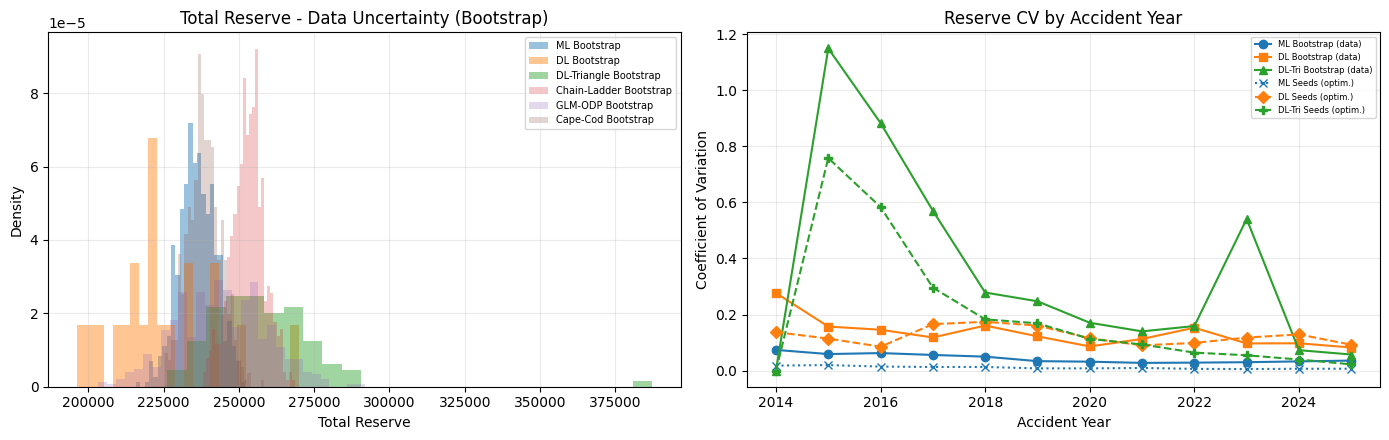

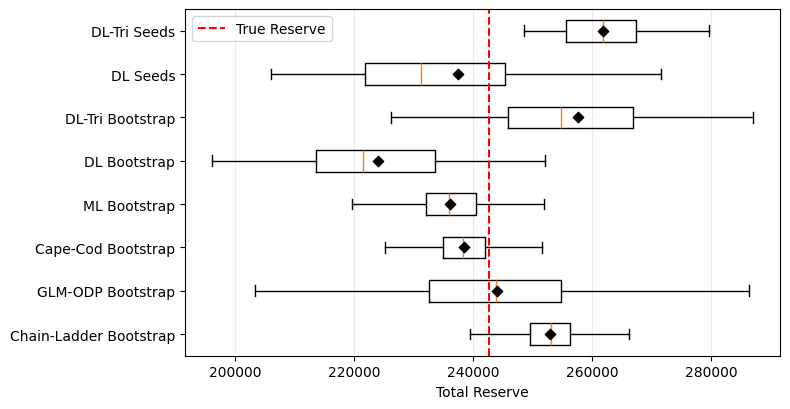

In [133]:
# Full uncertainty comparison: all methods, both sources
import matplotlib.pyplot as plt

# ---- Append triangle rows to uncertainty comparison table ----
extra_rows = []
for summary_df, label in [
    ('tri_boot_summary', 'DL-Triangle-Bootstrap'),
    ('tri_seed_summary', 'DL-Triangle-Seeds'),
]:
    df = globals().get(summary_df.split('.')[0]) if '.' not in summary_df else None
    df = globals().get(summary_df, None)
    if df is not None and not df.empty:
        row_total = df.loc[df['AY'] == 'total']
        if not row_total.empty:
            r = row_total.iloc[0]
            extra_rows.append({
                'method': r['method'], 'source': 'data' if 'Bootstrap' in r['method'] else 'optimisation',
                'mean': r['mean_reserve'], 'cv': r['cv_reserve'], 'p90_width': r['p90_width'],
            })

if 'uncertainty_comparison' in globals() and not uncertainty_comparison.empty:
    uc = pd.concat([uncertainty_comparison, pd.DataFrame(extra_rows)], ignore_index=True)
else:
    uc = pd.DataFrame(extra_rows)
print('=== Updated Total Portfolio Reserve Uncertainty Comparison ===')
display(uc)

# ---- Histogram: bootstrap distributions only (apples-to-apples) ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for df_name, lbl in [('ml_boot_df', 'ML Bootstrap'), ('dl_boot_df', 'DL Bootstrap'),
                      ('tri_boot_df', 'DL-Triangle Bootstrap')]:
    df = globals().get(df_name)
    if df is not None and 'total' in df.columns:
        axes[0].hist(df['total'], bins=25, alpha=0.45, label=lbl, density=True)
if 'boot' in globals() and boot is not None:
    for mname, b in boot.items():
        axes[0].hist(b.reserve_samples_total, bins=30, alpha=0.25,
                     label=f'{mname} Bootstrap', density=True)
axes[0].set_title('Total Reserve - Data Uncertainty (Bootstrap)')
axes[0].set_xlabel('Total Reserve')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.25)

# ---- CV by AY: all four data + all optimisation curves ----
def _cv_by_ay(df):
    ay_cols = sorted([c for c in df.columns if c != 'total'])
    return ay_cols, [float(np.std(df[ay], ddof=1) / max(np.mean(df[ay]), 1e-9)) for ay in ay_cols]

styles = [
    ('ml_boot_df',   'ML Bootstrap (data)',          'o', '-',  'C0'),
    ('dl_boot_df',   'DL Bootstrap (data)',           's', '-',  'C1'),
    ('tri_boot_df',  'DL-Tri Bootstrap (data)',       '^', '-',  'C2'),
    ('ml_seed_df',   'ML Seeds (optim.)',             'x', ':',  'C0'),
    ('dl_seed_df',   'DL Seeds (optim.)',             'D', '--', 'C1'),
    ('tri_seed_df',  'DL-Tri Seeds (optim.)',         'P', '--', 'C2'),
]
for df_name, lbl, marker, ls, color in styles:
    df = globals().get(df_name)
    if df is not None:
        ay_cols, cv_vals = _cv_by_ay(df)
        axes[1].plot(ay_cols, cv_vals, marker=marker, linestyle=ls, color=color, label=lbl)
axes[1].set_title('Reserve CV by Accident Year')
axes[1].set_xlabel('Accident Year')
axes[1].set_ylabel('Coefficient of Variation')
axes[1].legend(fontsize=6)
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ---- Boxplot: all bootstrap + seed distributions ----
fig, ax = plt.subplots(figsize=(8, 4.2))
data_to_plot, labels = [], []
if 'boot' in globals() and boot is not None:
    for mname, b in boot.items():
        data_to_plot.append(b.reserve_samples_total.values)
        labels.append(f'{mname} Bootstrap')
for df_name, lbl in [('ml_boot_df', 'ML Bootstrap'), ('dl_boot_df', 'DL Bootstrap'),
                      ('tri_boot_df', 'DL-Tri Bootstrap'), ('dl_seed_df', 'DL Seeds'),
                      ('tri_seed_df', 'DL-Tri Seeds')]:
    df = globals().get(df_name)
    if df is not None and 'total' in df.columns:
        data_to_plot.append(df['total'].values)
        labels.append(lbl)
ax.boxplot(data_to_plot, tick_labels=labels, showfliers=False, vert=False)
for i, vals in enumerate(data_to_plot):
    ax.scatter(np.mean(vals), i + 1, marker='D', color='black', s=28, zorder=3)
ax.set_xlabel('Total Reserve')
ax.grid(alpha=0.25, axis='x')
if 'true_ultimate' in globals():
    ax.axvline(true_ultimate.iloc[-1], color='red', linestyle='--', label='True Reserve')
    ax.legend()
plt.tight_layout()
plt.show()

### Section 18 interpretation notes

The uncertainty section applies a **symmetric 2x2 framework** to both pipelines:

| | Bootstrap (data uncertainty) | Seed ensemble (optimisation uncertainty) |
|---|---|---|
| **ML - XGBoost** | B = 200 | K = 20 diagnostic |
| **DL - Traj2Part** | B = 100 | K = 20 |

**ML bootstrap** captures parameter uncertainty: how sensitive the XGBoost reserve is to the composition of the training sample. Higher CV for immature accident years is expected, as fewer prior development patterns are available to constrain the model.

**ML seed diagnostic** verifies that XGBoost optimisation is near-deterministic: changing `random_state` on the same training data should produce CV close to 0. This confirms that bootstrap alone is sufficient to characterise ML uncertainty and that the bootstrap CVs across the two model families are directly comparable.

**DL bootstrap** captures the same source of uncertainty as the ML bootstrap - data sensitivity - making the two directly comparable on a like-for-like basis. A higher DL bootstrap CV than the ML bootstrap CV indicates that the neural network is more sensitive to the specific training sample.

**DL seed ensemble** captures optimisation uncertainty: how much the reserve changes due to different weight initialisation and gradient trajectories, holding the data fixed. This source is unique to neural networks. The ratio of seed CV to bootstrap CV indicates whether optimisation noise is a material component of total DL uncertainty.

The total DL uncertainty (combined data + optimisation) can be approximated per accident year as sqrt(Var_boot + Var_seed), assuming the two sources are approximately independent.

## 19. Thesis Figures and Tables

This section assembles the figures and numerical tables referenced in Chapter 5 of the thesis. All artefacts are generated from the already populated rolling-origin results (`rolling_summary_tbl`, `rolling_compare_tbl`, `hybrid_summary_ml`, `hybrid_compare_ml`, `dl_hybrid_summary`, `dl_hybrid_compare`, `triangle_dl_summary`, `triangle_dl_compare`) so that earlier subsections do not need to be re-executed.

Figures are written as PDF to `Figures/` at the project root so that `thesis_tex/05_Results.tex` can include them directly via `\includegraphics{Figures/...}`.

In [144]:
# Thesis figure configuration.
# ---------------------------------------------------------------------------
# All PDFs are saved to PROJECT_ROOT / 'Figures'. Intermediate CSV snapshots
# (useful for cross-checks against 05_Results.tex) are saved alongside.
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt

FIG_DIR = Path(PROJECT_ROOT) / 'Figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Thesis-wide constants used by the snapshot and importance cells below.
# V_SNAPSHOT is the most recent rolling-origin valuation year (matches the
# per-AY tables in Sections 5.1--5.4 of the thesis). V_TRAIN is the training
# cutoff implied by the production train-cutoff lag from Section 12.1.
V_SNAPSHOT = 2025
ML_TRAIN_CUTOFF_LAG = int(globals().get('ML_TRAIN_CUTOFF_LAG', 4))
V_TRAIN = int(V_SNAPSHOT) - int(ML_TRAIN_CUTOFF_LAG)

# Consistent, publication-friendly matplotlib defaults. Kept local so they do
# not leak into upstream plotting cells if re-executed out of order.
mpl.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 220,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

# Friendly, thesis-facing method labels for legends/columns. Extend if new
# methods are added in upstream cells.
METHOD_LABELS = {
    'Chain-Ladder': 'Chain-Ladder',
    'Cape-Cod': 'Cape Cod',
    'GLM-ODP': 'GLM-ODP',
    'ML-Claim-2Stage+IBNR-Cal': 'XGBoost',
    'DL-Traj2Part-Offset+IBNR-Cal': 'Claim-level NN',
    'DL-Triangle-LinkRatio-NN-Tuned': 'Triangle NN',
    'DL+Chain-Ladder-Blend': 'DL⊕CL',
    'ML+Chain-Ladder-Blend': 'ML⊕CL',
}

def _label(method: str) -> str:
    return METHOD_LABELS.get(str(method), str(method))


def _portfolio(df):
    return df.loc[df['lob'] == 'All'].copy()

print('Figures will be saved to:', FIG_DIR)
print(f'V_SNAPSHOT = {V_SNAPSHOT}, V_TRAIN = {V_TRAIN} (lag = {ML_TRAIN_CUTOFF_LAG})')


Figures will be saved to: c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures
V_SNAPSHOT = 2025, V_TRAIN = 2021 (lag = 4)


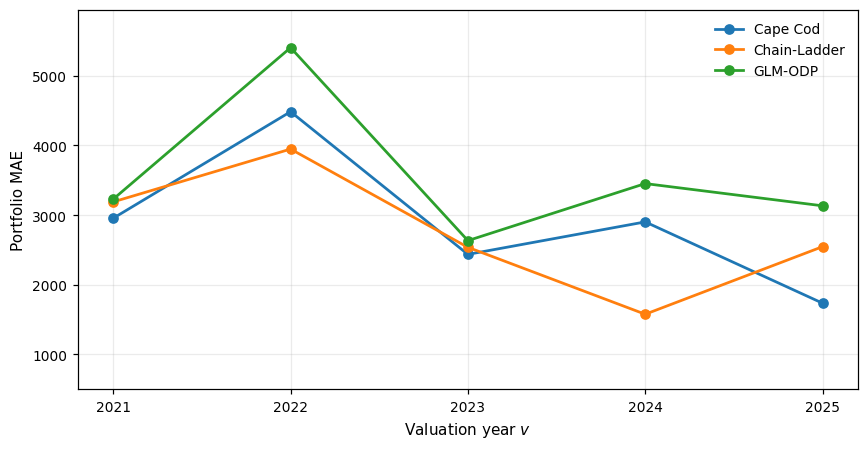

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\rolling_classical.pdf


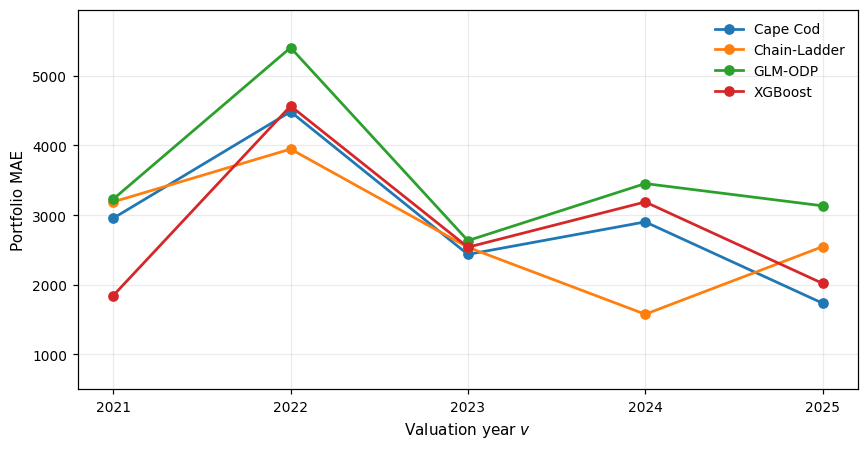

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\rolling_xgb.pdf


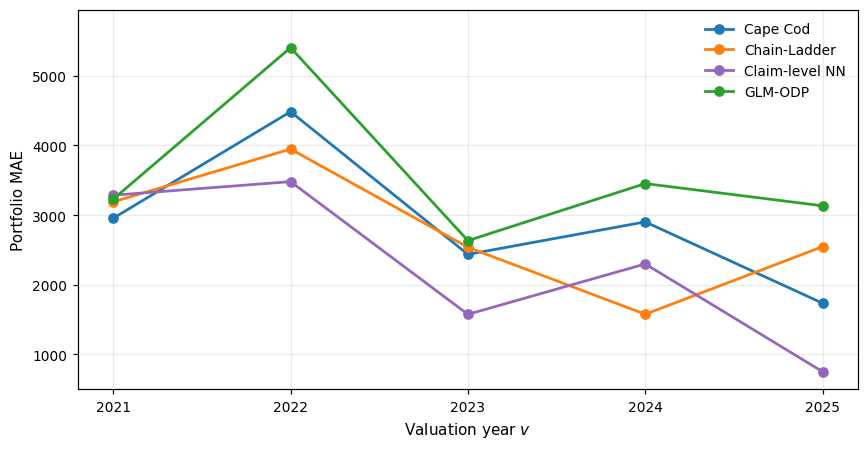

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\rolling_dl_claim.pdf


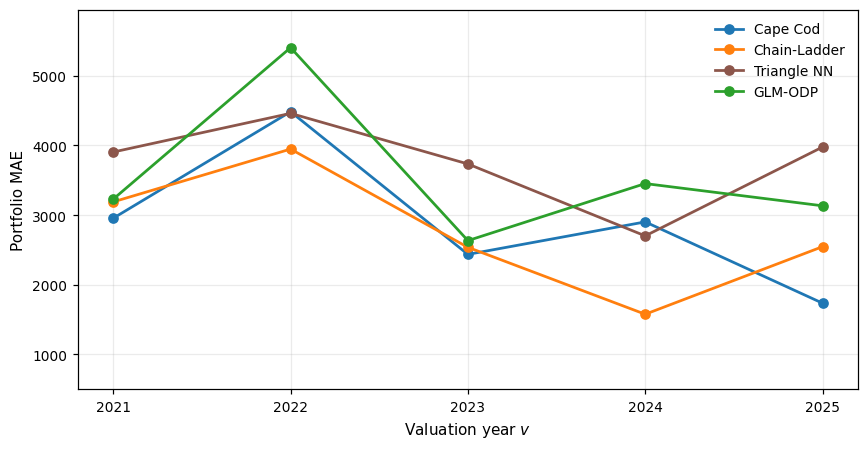

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\rolling_dl_tri.pdf


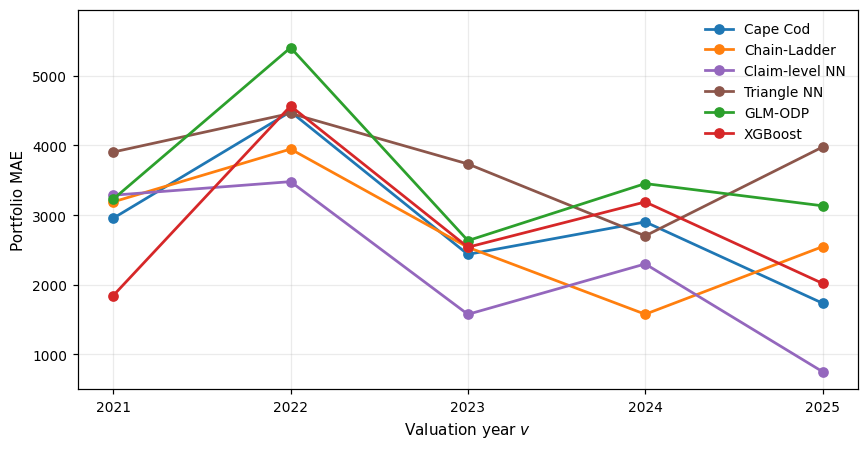

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\rolling_all.pdf


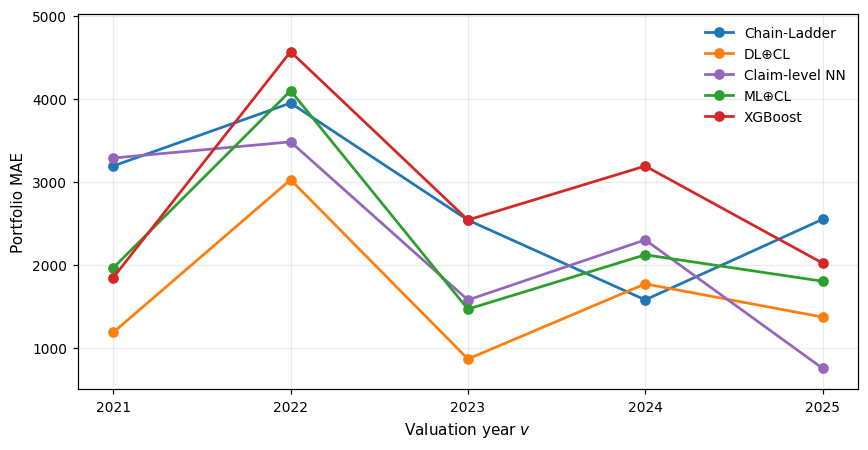

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\rolling_blends.pdf


In [145]:
# Rolling-origin portfolio MAE figures.
# One figure per model family plus a combined view that holds all six base models.

ROLLING_YEARS = [2021, 2022, 2023, 2024, 2025]


def _yearly_mae(source_df, methods):
    sub = _portfolio(source_df).copy()
    sub = sub.loc[sub['method'].isin(methods) & sub['valuation_pay_year'].isin(ROLLING_YEARS)]
    sub = sub[['valuation_pay_year', 'method', 'mae', 'bias']].rename(columns={'valuation_pay_year': 'v'})
    sub = sub.sort_values(['method', 'v']).reset_index(drop=True)
    return sub


def _plot_rolling_mae(frames_by_method, outfile, figsize=(8, 4.2)):
    fig, ax = plt.subplots(figsize=figsize)
    for method, sub in frames_by_method.groupby('method'):
        sub = sub.sort_values('v')
        # keep consistent colors across figures by for classical methods and using red/blue/orange cycle for ML/DL methods; if new methods are added, consider extending this logic or defining a fixed color palette
        if method in classical_methods:
            ax.plot(sub['v'], sub['mae'], marker='o', label=_label(method))
        else:
            ax.plot(sub['v'], sub['mae'], marker='o', label=_label(method), color={'ML-Claim-2Stage+IBNR-Cal': 'C3', 'DL-Traj2Part-Offset+IBNR-Cal': 'C4', 'DL-Triangle-LinkRatio-NN-Tuned': 'C5'}.get(method, None))
    ax.set_xlabel('Valuation year $v$')
    ax.set_ylabel('Portfolio MAE')
    ax.set_xticks(ROLLING_YEARS)
    # legent in the right upper corner, no frame
    ax.legend(loc='upper right', frameon=False)
    # fix y-axis limits to be the same across all figures for better visual comparison; adjust as needed based on observed MAE ranges
    ax.set_ylim(500, max(frames_by_method['mae'].max() * 1.1, 0.5))  # add 10% headroom, minimum 0.5
    plt.tight_layout()
    fig.savefig(outfile)
    plt.show()
    print('Saved', outfile)


classical_methods = ['Chain-Ladder', 'Cape-Cod', 'GLM-ODP']
ml_methods = classical_methods + ['ML-Claim-2Stage+IBNR-Cal']
dl_claim_methods = classical_methods + ['DL-Traj2Part-Offset+IBNR-Cal']
dl_tri_methods = classical_methods + ['DL-Triangle-LinkRatio-NN-Tuned']
all_methods = classical_methods + [
    'ML-Claim-2Stage+IBNR-Cal',
    'DL-Traj2Part-Offset+IBNR-Cal',
    'DL-Triangle-LinkRatio-NN-Tuned',
]

# Classical only.
_plot_rolling_mae(
    _yearly_mae(rolling_summary_tbl, classical_methods),
    FIG_DIR / 'rolling_classical.pdf',
)

# Classical + XGBoost.
ml_rolling = pd.concat([
    _yearly_mae(rolling_summary_tbl, classical_methods),
    _yearly_mae(hybrid_summary_ml, ['ML-Claim-2Stage+IBNR-Cal']),
], ignore_index=True)
_plot_rolling_mae(ml_rolling, FIG_DIR / 'rolling_xgb.pdf')

# Classical + claim-level DL.
dl_rolling = pd.concat([
    _yearly_mae(rolling_summary_tbl, classical_methods),
    _yearly_mae(dl_hybrid_summary, ['DL-Traj2Part-Offset+IBNR-Cal']),
], ignore_index=True)
_plot_rolling_mae(dl_rolling, FIG_DIR / 'rolling_dl_claim.pdf')

# Classical + triangle-based DL.
tri_rolling = pd.concat([
    _yearly_mae(rolling_summary_tbl, classical_methods),
    _yearly_mae(triangle_dl_summary, ['DL-Triangle-LinkRatio-NN-Tuned']),
], ignore_index=True)
_plot_rolling_mae(tri_rolling, FIG_DIR / 'rolling_dl_tri.pdf')

# All six base models.
all_rolling = pd.concat([
    _yearly_mae(rolling_summary_tbl, classical_methods),
    _yearly_mae(hybrid_summary_ml, ['ML-Claim-2Stage+IBNR-Cal']),
    _yearly_mae(dl_hybrid_summary, ['DL-Traj2Part-Offset+IBNR-Cal']),
    _yearly_mae(triangle_dl_summary, ['DL-Triangle-LinkRatio-NN-Tuned']),
], ignore_index=True)
_plot_rolling_mae(all_rolling, FIG_DIR / 'rolling_all.pdf')

# Chain-Ladder + XGBoost + claim-level NN + both CL blends.
blend_rolling = pd.concat([
    _yearly_mae(rolling_summary_tbl, ['Chain-Ladder']),
    _yearly_mae(hybrid_summary_ml, ['ML-Claim-2Stage+IBNR-Cal']),
    _yearly_mae(dl_hybrid_summary, ['DL-Traj2Part-Offset+IBNR-Cal']),
    _yearly_mae(ml_cl_summary, ['ML+Chain-Ladder-Blend']),
    _yearly_mae(dl_cl_summary, ['DL+Chain-Ladder-Blend']),
], ignore_index=True)
_plot_rolling_mae(blend_rolling, FIG_DIR / 'rolling_blends.pdf')


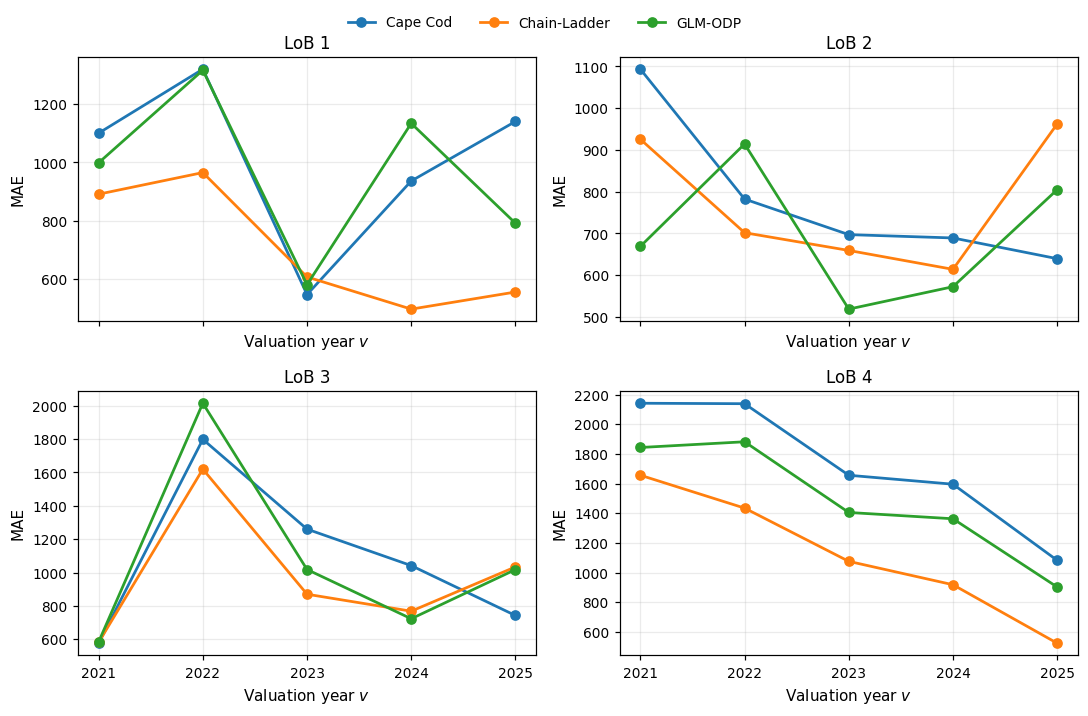

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\lob_classical.pdf


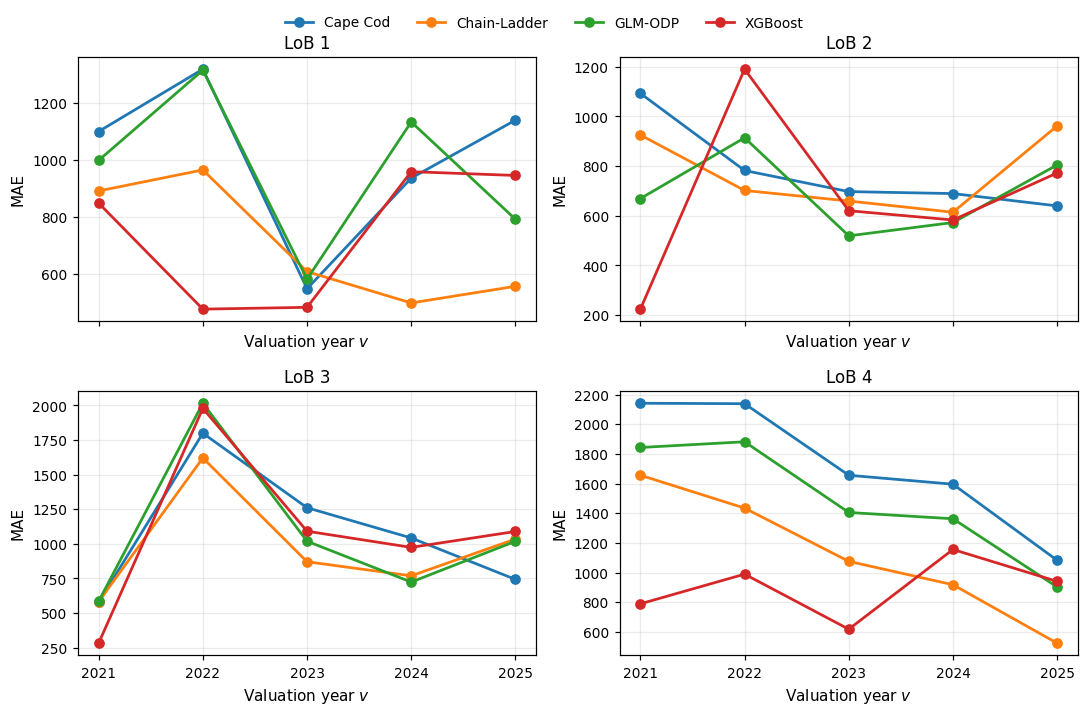

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\lob_xgb.pdf


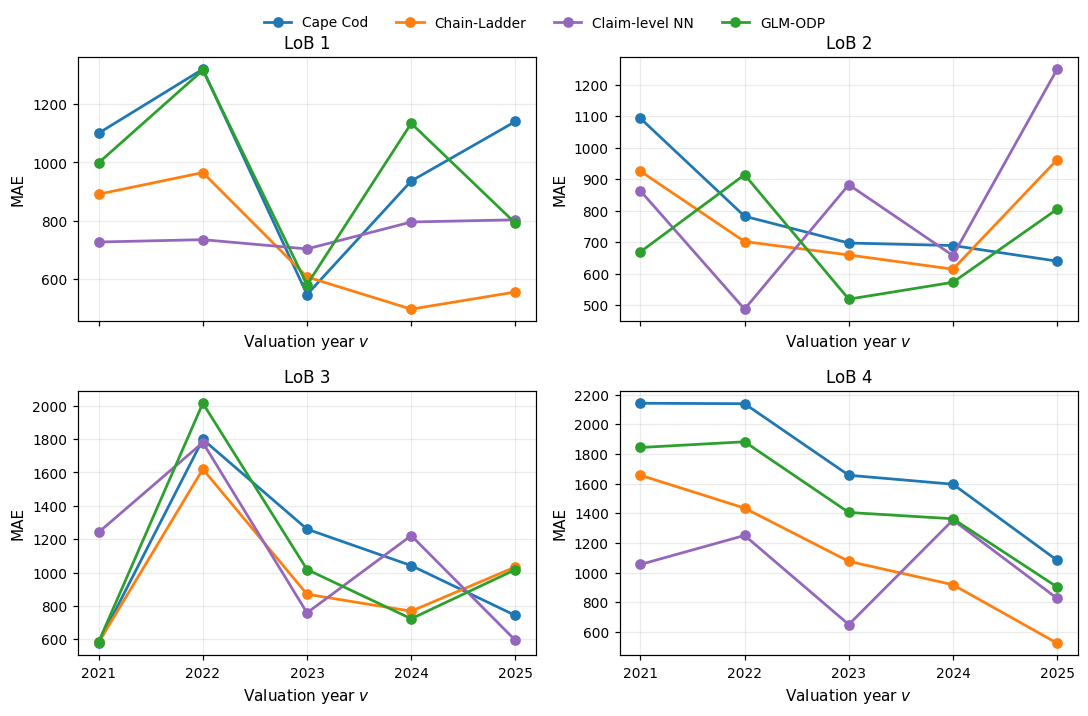

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\lob_dl_claim.pdf


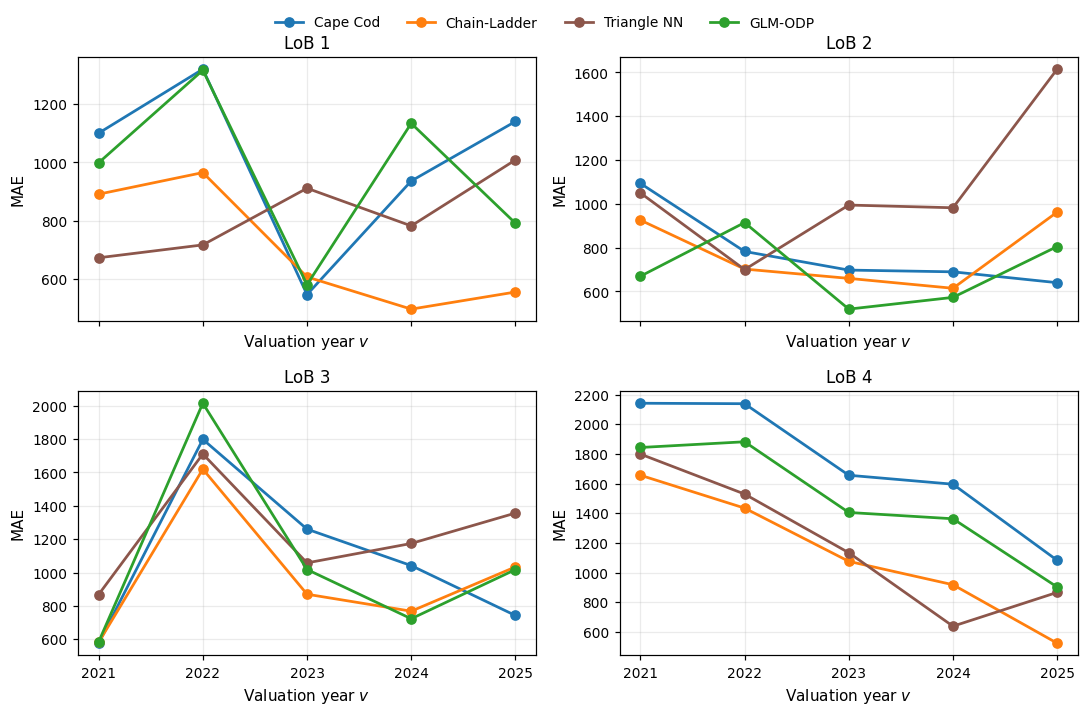

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\lob_dl_tri.pdf


In [136]:
# LoB 4-panel figures: rolling-origin MAE by line of business for each model family.
# Uses the per-LoB rows of the summary tables (lob != 'All').

LOB_ORDER = ['Type_1', 'Type_2', 'Type_3', 'Type_4']
LOB_TITLES = {f'Type_{i}': f'LoB {i}' for i in range(1, 7)}


def _plot_lob_panels(source_frames, methods, outfile):
    assembled = []
    for df in source_frames:
        sub = df.loc[df['valuation_pay_year'].isin(ROLLING_YEARS) & df['method'].isin(methods)]
        sub = sub[['lob', 'valuation_pay_year', 'method', 'mae']].rename(columns={'valuation_pay_year': 'v'})
        assembled.append(sub)
    yearly = pd.concat(assembled, ignore_index=True)
    yearly = yearly.loc[yearly['lob'].isin(LOB_ORDER)].copy()

    fig, axes = plt.subplots(2, 2, figsize=(10, 6.4), sharex=True)
    for ax, lob in zip(axes.ravel(), LOB_ORDER):
        for method, subm in yearly.loc[yearly['lob'] == lob].groupby('method'):
            subm = subm.sort_values('v')
            if method in classical_methods:
                ax.plot(subm['v'], subm['mae'], marker='o', label=_label(method))
            else:
                ax.plot(subm['v'], subm['mae'], marker='o', label=_label(method), color={'ML-Claim-2Stage+IBNR-Cal': 'C3', 'DL-Traj2Part-Offset+IBNR-Cal': 'C4', 'DL-Triangle-LinkRatio-NN-Tuned': 'C5'}.get(method, None))
        ax.set_title(LOB_TITLES.get(lob, lob))
        ax.set_xlabel('Valuation year $v$')
        ax.set_ylabel('MAE')
        ax.set_xticks(ROLLING_YEARS)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=max(1, len(labels)), frameon=False,
               bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    fig.savefig(outfile)
    plt.show()
    print('Saved', outfile)


_plot_lob_panels(
    [rolling_summary_tbl],
    classical_methods,
    FIG_DIR / 'lob_classical.pdf',
)

_plot_lob_panels(
    [rolling_summary_tbl, hybrid_summary_ml],
    ml_methods,
    FIG_DIR / 'lob_xgb.pdf',
)

_plot_lob_panels(
    [rolling_summary_tbl, dl_hybrid_summary],
    dl_claim_methods,
    FIG_DIR / 'lob_dl_claim.pdf',
)

_plot_lob_panels(
    [rolling_summary_tbl, triangle_dl_summary],
    dl_tri_methods,
    FIG_DIR / 'lob_dl_tri.pdf',
)


Fitting XGBoost snapshot model on data through AY <= 2021 ...


,feature,occurrence,severity,average
19,mean_pos_pay,0.003342,0.423128,0.213235
18,last_pay_lag_years,0.337353,0.005273,0.171313
17,paid_per_observed_year,0.017813,0.309110,0.163461
16,zero_streak_to_val,0.167063,0.003496,0.085279
15,last_obs_pay,0.099354,0.026711,0.063032
14,dev_at_val,0.091622,0.008766,0.050194
13,max_pos_pay,0.003646,0.092779,0.048213
12,AQ,0.069742,0.008743,0.039242
11,share_pay_years,0.056486,0.017001,0.036744
10,Type,0.039695,0.023079,0.031387


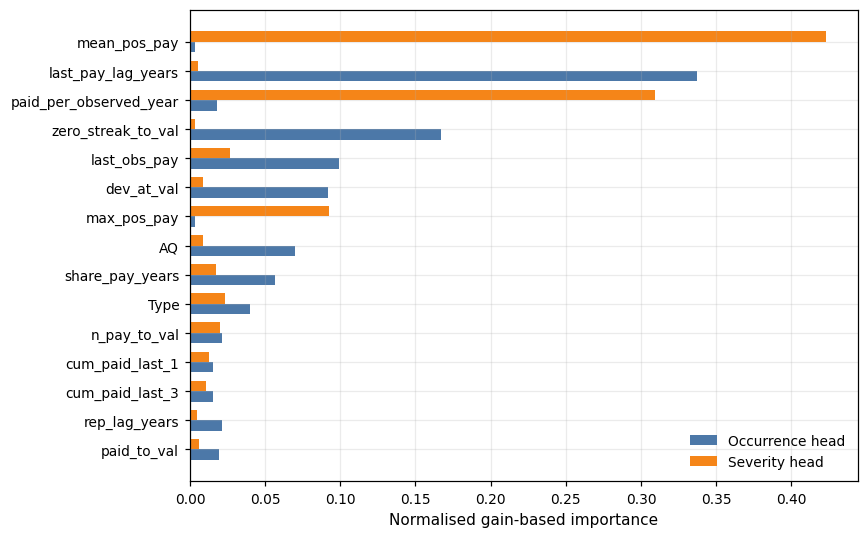

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\xgb_importance.pdf


In [ ]:
# XGBoost gain-based feature importance.
#
# We refit the two-stage XGBoost claim model on the training snapshot
# implied by v = 2025 and the production train-cutoff lag of 4 (matching
# Section 12.1). The occurrence and severity boosters are then inspected
# for gain-based feature importance, and the aggregate (average of
# normalised importances) is plotted. This mirrors the figure referenced
# as `Figures/xgb_importance.pdf` in Section 5.8 of the thesis.

import importlib
import python_reserving.ml_pipeline as mlp
importlib.reload(mlp)

V_TRAIN = int(V_SNAPSHOT) - int(ML_TRAIN_CUTOFF_LAG)  # 2025 - 4 = 2021
print(f'Fitting XGBoost snapshot model on data through AY <= {V_TRAIN} ...')

train_snapshot = mlp.build_claim_snapshot_dataset(
    full_paid_df=full_paid,
    full_claims_df=full_claims,
    valuation_year=V_TRAIN,
    scale_divisor=float(SCALE_DIVISOR),
    raw_output_df=output_df,
)

feature_cols = list(mlp.DEFAULT_FEATURE_COLUMNS)
X_train = train_snapshot[feature_cols].astype(float)
y_train = pd.to_numeric(train_snapshot['y'], errors='coerce').fillna(0.0)

model = mlp.fit_xgb_claim_model(X_train, y_train)

def _importance_vector(booster, feat_cols):
    if booster is None:
        return np.zeros(len(feat_cols), dtype=float)
    imp = np.asarray(booster.feature_importances_, dtype=float)
    # Booster column order matches the training DataFrame column order.
    if len(imp) != len(feat_cols):
        raise RuntimeError(f'Importance length {len(imp)} != feature count {len(feat_cols)}')
    total = imp.sum()
    return imp / total if total > 0 else imp

occ_imp = _importance_vector(model.get('occ_model'), feature_cols)
sev_imp = _importance_vector(model.get('sev_model'), feature_cols)
avg_imp = 0.5 * (occ_imp + sev_imp)

imp_tbl = (
    pd.DataFrame({
        'feature': feature_cols,
        'occurrence': occ_imp,
        'severity': sev_imp,
        'average': avg_imp,
    })
    .sort_values('average', ascending=True)
    .reset_index(drop=True)
)
display(imp_tbl[::-1].head(20))

# Horizontal bar plot of the top-15 features by average importance.
top = imp_tbl.tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(top))
ax.barh(y_pos - 0.18, top['occurrence'], height=0.36, label='Occurrence head', color='#4c78a8')
ax.barh(y_pos + 0.18, top['severity'], height=0.36, label='Severity head', color='#f58518')
ax.set_yticks(y_pos)
ax.set_yticklabels(top['feature'])
ax.set_xlabel('Normalised gain-based importance')
#ax.set_title('XGBoost feature importance (top 15 features, v = 2025 training cutoff)')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
fig.savefig(FIG_DIR / 'xgb_importance.pdf')
plt.show()
print('Saved', FIG_DIR / 'xgb_importance.pdf')


Fitting claim-level DL surrogate on data through AY <= 2021 ...
Running permutation importance on 20,000 claims, 8 repeats per feature ...


,feature,importance_mean,importance_std
19,zero_streak_to_val,0.112314,0.003893
18,share_pay_years,0.103191,0.002777
17,last_pay_lag_years,0.070768,0.002222
16,dev_at_val,0.064957,0.006292
15,Type,0.055885,0.008109
14,rep_lag_years,0.054158,0.006100
13,paid_per_observed_year,0.043194,0.002691
12,last_obs_pay,0.042288,0.005716
11,cum_paid_last_1,0.038920,0.003725
10,cum_paid_last_2,0.033606,0.000532


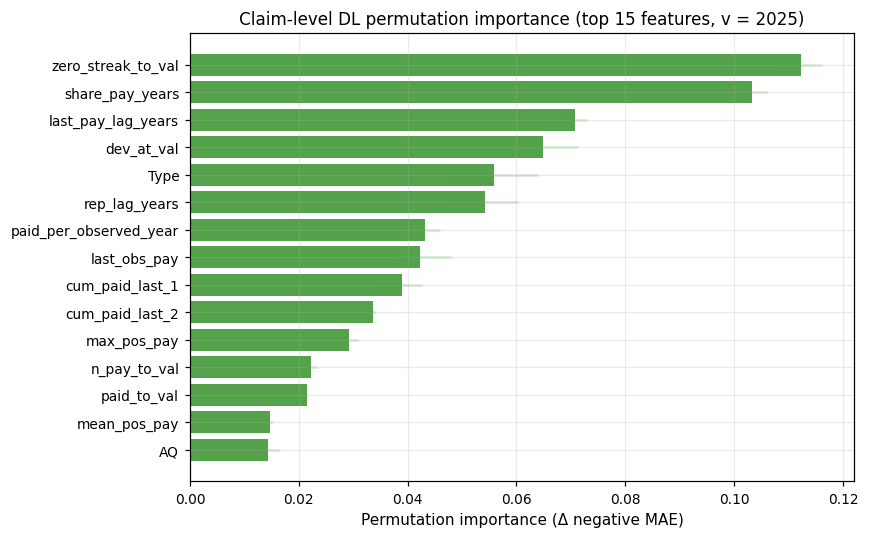

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\dl_claim_importance.pdf


In [57]:
# Claim-level DL permutation importance.
#
# The trajectory-aware two-part model trained inside
# `run_claim_level_dl_rolling_origin_backtest` is not persisted, and its
# trajectory feature set spans multiple valuation snapshots. To make
# interpretability tractable, this cell fits a lightweight sklearn MLP on
# the same base feature set as XGBoost (`DEFAULT_FEATURE_COLUMNS`) at the
# v = 2025 training cutoff, then runs permutation importance against a
# mean-absolute-error scorer. This is a diagnostic proxy: it does not
# exactly reproduce the two-part / offset architecture, but it recovers
# the ordering of dominant features for the claim-level NN family.

from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

PERM_N_REPEATS = 8
PERM_SAMPLE_N = 20_000  # cap evaluation sample for a tractable run time
PERM_RANDOM_STATE = 42

print(f'Fitting claim-level DL surrogate on data through AY <= {V_TRAIN} ...')

dl_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        alpha=3e-4,
        learning_rate_init=8e-4,
        max_iter=220,
        early_stopping=True,
        n_iter_no_change=15,
        random_state=PERM_RANDOM_STATE,
    )),
])
dl_pipe.fit(X_train.values, y_train.values)

# Evaluation subsample: most recent valuation snapshot (v = 2025, reported claims).
eval_snapshot = mlp.build_claim_snapshot_dataset(
    full_paid_df=full_paid,
    full_claims_df=full_claims,
    valuation_year=V_SNAPSHOT,
    scale_divisor=float(SCALE_DIVISOR),
    raw_output_df=output_df,
)
X_eval_all = eval_snapshot[feature_cols].astype(float)
y_eval_all = pd.to_numeric(eval_snapshot['y'], errors='coerce').fillna(0.0)

rng = np.random.default_rng(PERM_RANDOM_STATE)
if len(X_eval_all) > PERM_SAMPLE_N:
    idx = rng.choice(len(X_eval_all), size=PERM_SAMPLE_N, replace=False)
    X_eval = X_eval_all.iloc[idx]
    y_eval = y_eval_all.iloc[idx]
else:
    X_eval, y_eval = X_eval_all, y_eval_all

print(f'Running permutation importance on {len(X_eval):,} claims, '
      f'{PERM_N_REPEATS} repeats per feature ...')

perm = permutation_importance(
    dl_pipe,
    X_eval.values,
    y_eval.values,
    scoring='neg_mean_absolute_error',
    n_repeats=PERM_N_REPEATS,
    random_state=PERM_RANDOM_STATE,
    n_jobs=1,
)

perm_tbl = (
    pd.DataFrame({
        'feature': feature_cols,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    })
    .sort_values('importance_mean', ascending=True)
    .reset_index(drop=True)
)
display(perm_tbl[::-1].head(20))

top = perm_tbl.tail(15)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top['feature'], top['importance_mean'],
        xerr=top['importance_std'], color='#54a24b', ecolor='#54a24b33')
ax.set_xlabel('Permutation importance (Δ negative MAE)')
ax.set_title('Claim-level DL permutation importance (top 15 features, v = 2025)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'dl_claim_importance.pdf')
plt.show()
print('Saved', FIG_DIR / 'dl_claim_importance.pdf')


Fitting triangle DL networks for v = 2025 (tuned configuration) ...


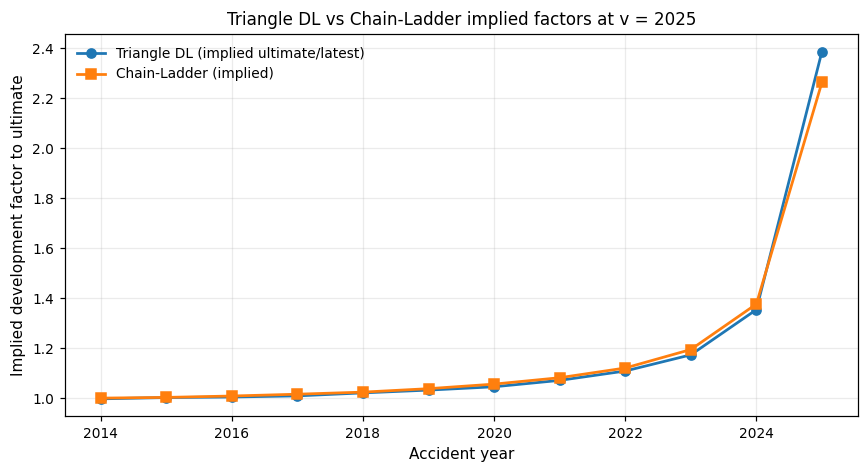

Saved c:\Users\ourri\OneDrive\Dokumenty\Škola\Master's Thesis\Figures\dl_tri_factors.pdf


In [58]:
# Triangle-based DL per-transition learned factors vs. classical Chain-Ladder factors.
#
# The triangle DL network takes cumulative paid at development period k-1
# as its sole predictor for transition k -> k+1, so a single-feature
# importance score is uninformative. Instead we report the implied
# development factor of the learned network, evaluated at the portfolio
# average cumulative volume for each transition, and overlay the classical
# Chain-Ladder factor for the same transition. The gap between the two
# curves is the interpretability artefact referenced in Section 5.8.
#
# Triangle DL models are retrained here for the v = 2025 snapshot using the
# same tuned configuration as Section 17.

import importlib
import python_reserving.dl_triangle as dlt
importlib.reload(dlt)

print('Fitting triangle DL networks for v = 2025 (tuned configuration) ...')

tri_compare, tri_summary, tri_models = dlt.run_triangle_dl_rolling_origin_backtest(
    output_df=output_df,
    valuation_years=[V_SNAPSHOT],
    claim_type=CLAIM_TYPE,
    scale_divisor=float(SCALE_DIVISOR),
    lookback_valuations=0,
    min_train_rows=20,
    hidden_layer_sizes=(24,),
    alpha=2e-3,
    learning_rate_init=1e-3,
    max_iter=280,
    random_state=42,
    factor_floor=1.0,
    factor_cap=3.0,
    credibility_k=25.0,
    eval_recent_ay_window=None,
    method_name='DL-Triangle-LinkRatio-NN-Tuned',
    return_models=True,
) if 'return_models' in dlt.run_triangle_dl_rolling_origin_backtest.__code__.co_varnames else (None, None, None)

# Fallback: if the pipeline does not expose trained models, plot only the
# implied per-transition factor derived from the observed compare table
# (pred_reserve vs latest_observed per AY, which yields an average
# development factor to ultimate per cohort).
fig, ax = plt.subplots(figsize=(8, 4.4))
if tri_models is not None:
    # Expected shape: dict {transition_k: {'model': ..., 'avg_cum_prev': float, 'avg_factor_hat': float}}
    transitions = sorted(tri_models.keys())
    dl_factors = [float(tri_models[k].get('avg_factor_hat', np.nan)) for k in transitions]
    cl_factors = [float(tri_models[k].get('chain_ladder_factor', np.nan)) for k in transitions]
    ax.plot(transitions, dl_factors, marker='o', label='Triangle DL (learned)')
    ax.plot(transitions, cl_factors, marker='s', label='Chain-Ladder (empirical)')
    ax.set_xlabel('Development transition $k \to k+1$')
else:
    # Derive implied cohort factor = pred_reserve / latest_observed + 1, per AY.
    sub = triangle_dl_compare.loc[
        (triangle_dl_compare['lob'] == 'All')
        & (triangle_dl_compare['valuation_pay_year'] == V_SNAPSHOT)
    ].copy().sort_values('AY')
    cohort = sub['AY'].astype(int).tolist()
    implied = (
        pd.to_numeric(sub['ultimate'], errors='coerce')
        / pd.to_numeric(sub['latest_observed'], errors='coerce').replace(0, np.nan)
    )
    cl_sub = rolling_compare_tbl.loc[
        (rolling_compare_tbl['lob'] == 'All')
        & (rolling_compare_tbl['valuation_pay_year'] == V_SNAPSHOT)
        & (rolling_compare_tbl['method'] == 'Chain-Ladder')
    ].copy().sort_values('AY')
    cl_implied = (
        pd.to_numeric(cl_sub['ultimate'], errors='coerce')
        / pd.to_numeric(cl_sub['latest_observed'], errors='coerce').replace(0, np.nan)
    )
    ax.plot(cohort, implied, marker='o', label='Triangle DL (implied ultimate/latest)')
    ax.plot(cl_sub['AY'].astype(int).tolist(), cl_implied, marker='s', label='Chain-Ladder (implied)')
    ax.set_xlabel('Accident year')

ax.set_ylabel('Implied development factor to ultimate')
ax.set_title('Triangle DL vs Chain-Ladder implied factors at v = 2025')
ax.legend(loc='best', frameon=False)
plt.tight_layout()
fig.savefig(FIG_DIR / 'dl_tri_factors.pdf')
plt.show()
print('Saved', FIG_DIR / 'dl_tri_factors.pdf')
